## Preparción de datos

In [2]:
import pickle
import logging
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.metrics.pairwise import nan_euclidean_distances
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

ruta_guardado = r"C:\Users\mario\Desktop\MasterCienciadeDatos\TFM\TFM_MarioSoto\src\data_lake\PKL\dfs_final_maratones4_sin2022.pkl" #se coge dfs_final del EDA general

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
with open(ruta_guardado, 'rb') as f:
    dfs_final = pickle.load(f)

In [5]:
dfs = dfs_final

In [6]:
athletes_df = dfs['athletes_df'] 
athletes_events_df = dfs['athletes_events_df']
athletes_time_df = dfs['athletes_time_df']

issues_df = dfs['issues_df']
issues_events_df = dfs['issues_events_df']
issues_data_df = dfs['issues_data_df']
issues_times_df = dfs['issues_times_df']

In [7]:
athletes_time_df.columns

Index(['athlete_id', 'average', 'distance', 'event_id', 'incidence',
       'isBackup', 'netTime', 'offset', 'order', 'race_id', 'rawTime', 'split',
       'time', 'event_std', 'netTime_td', 'time_td'],
      dtype='object')

In [8]:
athletes_time_df.head(5)

,athlete_id,average,distance,event_id,incidence,isBackup,netTime,offset,order,race_id,rawTime,split,time,event_std,netTime_td,time_td
0,200,0.00000,0,Maratón,True,NaN,0,NaN,1,af5c5746-04e8-42ab-9610-b12f0d9125b1,2025-02-23 07:30:10.010,Salida,10,maraton,0 days 00:00:00,0 days 00:00:00.010000
1,200,0.17981,5000,Maratón,NaN,NaN,899020,NaN,2,af5c5746-04e8-42ab-9610-b12f0d9125b1,2025-02-23 07:45:09.030,5K,899030,maraton,0 days 00:14:59.020000,0 days 00:14:59.030000
2,200,0.17988,10000,Maratón,NaN,NaN,1798768,NaN,3,af5c5746-04e8-42ab-9610-b12f0d9125b1,2025-02-23 08:00:08.778,10K,1798778,maraton,0 days 00:29:58.768000,0 days 00:29:58.778000
3,200,0.17903,13000,Maratón,NaN,NaN,2327380,NaN,4,af5c5746-04e8-42ab-9610-b12f0d9125b1,2025-02-23 08:08:57.390,Asics,2327390,maraton,0 days 00:38:47.380000,0 days 00:38:47.390000
4,200,0.17905,15000,Maratón,NaN,NaN,2685770,NaN,5,af5c5746-04e8-42ab-9610-b12f0d9125b1,2025-02-23 08:14:55.780,15K,2685780,maraton,0 days 00:44:45.770000,0 days 00:44:45.780000


In [9]:
import pandas as pd

athlete_id = '8Y2B2549'
race_id = "49603c2f-1b2b-457f-b82e-fed8bded1d3d"
event_id = 'Marato'
filtered = athletes_time_df.loc[
    (athletes_time_df["athlete_id"] == athlete_id) &
    (athletes_time_df["race_id"] == race_id) &
    (athletes_time_df["event_id"] == event_id)
]

filtered

,athlete_id,average,distance,event_id,incidence,isBackup,netTime,offset,order,race_id,rawTime,split,time,event_std,netTime_td,time_td
883583,8Y2B2549,0.35571,42195,Marato,True,False,14889224,0.0,11,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 12:15:20.183,Meta,15009224,maraton,0 days 04:08:09.224000,0 days 04:10:09.224000
883584,8Y2B2549,0.35550,40000,Marato,True,False,14100072,0.0,10,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 12:02:11.031,40K,14220072,maraton,0 days 03:55:00.072000,0 days 03:57:00.072000
883585,8Y2B2549,0.34524,35000,Marato,True,False,11963431,0.0,9,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 11:26:34.390,35K,12083431,maraton,0 days 03:19:23.431000,0 days 03:21:23.431000
883586,8Y2B2549,0.34163,25000,Marato,True,False,8420720,0.0,7,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 10:27:31.679,25K,8540720,maraton,0 days 02:20:20.720000,0 days 02:22:20.720000
883587,8Y2B2549,0.34134,20000,Marato,True,False,6706841,0.0,5,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 09:58:57.800,20K,6826841,maraton,0 days 01:51:46.841000,0 days 01:53:46.841000
883588,8Y2B2549,0.00000,0,Marato,True,False,0,0.0,1,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 08:07:10.959,Salida,120000,maraton,0 days 00:00:00,0 days 00:02:00
883589,8Y2B2549,0.34820,5000,Marato,True,False,1621000,0.0,2,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 08:34:11.959,5K,1741000,maraton,0 days 00:27:01,0 days 00:29:01
883590,8Y2B2549,0.34211,10000,Marato,True,False,3301092,0.0,3,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 09:02:12.051,10K,3421092,maraton,0 days 00:55:01.092000,0 days 00:57:01.092000
883591,8Y2B2549,0.34133,30000,Marato,True,False,10120000,0.0,8,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 10:55:50.959,30K,10240000,maraton,0 days 02:48:40,0 days 02:50:40
883592,8Y2B2549,0.32706,21097,Marato,True,False,6780000,0.0,6,49603c2f-1b2b-457f-b82e-fed8bded1d3d,2025-03-16 10:00:10.959,Media,6900000,maraton,0 days 01:53:00,0 days 01:55:00


In [10]:
athletes_df.columns

Index(['athlete_id', 'birthdate', 'club', 'fullName', 'gender', 'name',
       'nationality', 'race_id', 'surname'],
      dtype='object')

In [11]:
athletes_events_df.columns

Index(['athlete_id', 'auto_category', 'auto_chip', 'category', 'distance',
       'dorsal', 'event_id', 'gunTime', 'gunTimeMode',
       'gunTimeModeConfig_wave', 'last_split_seen',
       'maxConsecutiveSplitsMissing', 'race_id', 'realStatus', 'splitsMissing',
       'splitsSeen', 'startNetTime', 'startRawTime', 'startTime', 'status',
       'team', 'event_std', 'startNetTime_td', 'startTime_td'],
      dtype='object')

In [12]:
athletes_time_df.columns

Index(['athlete_id', 'average', 'distance', 'event_id', 'incidence',
       'isBackup', 'netTime', 'offset', 'order', 'race_id', 'rawTime', 'split',
       'time', 'event_std', 'netTime_td', 'time_td'],
      dtype='object')

Añadimos las variables que necesitamos para el cálculo de diferentes métricas, como el tiempo por split, el split previo y el orden de los splits

In [13]:
split_cols_maraton = ['5K', '10K', '15K', '20K', 'Media', '25K', '30K', '35K', '40K', 'Meta']

In [14]:
# Filtrar filas: conservar solo los splits que están en split_cols_maraton
athletes_time_df = athletes_time_df[athletes_time_df['split'].isin(split_cols_maraton)].copy()

print("=== Filtrando eventos ===")
print(f"Filas después de filtrar splits: {len(athletes_time_df)}")

df = athletes_time_df.copy()
df['netTime_sec'] = df['netTime_td'].dt.total_seconds() 

df = df.sort_values(['athlete_id', 'race_id', 'event_id', 'netTime_sec'])

df['prev_netTime'] = df.groupby(['athlete_id', 'race_id', 'event_id'])['netTime_sec'].shift(1) 
df['prev_split'] = df.groupby(['athlete_id', 'race_id', 'event_id'])['split'].shift(1)

df['first_split'] = df.groupby(['athlete_id', 'race_id', 'event_id']).cumcount() == 0
df['time_split_sec'] = 0.0
df.loc[df['split'] == 'Salida', 'time_split_sec'] = 0.0

mask_first = df['first_split'] & (df['split'] != 'Salida')
df.loc[mask_first, 'time_split_sec'] = df.loc[mask_first, 'netTime_sec'] 

mask_rest = ~df['first_split'] & (df['split'] != 'Salida')
df.loc[mask_rest, 'time_split_sec'] = df.loc[mask_rest, 'netTime_sec'] - df.loc[mask_rest, 'prev_netTime']

df['split_order'] = df.groupby(['athlete_id', 'race_id', 'event_id']).cumcount() 

athletes_time_df['time_split_sec'] = df['time_split_sec']
athletes_time_df['prev_split'] = df['prev_split']
athletes_time_df['split_order'] = df['split_order']

# Mostrar negativos y ceros filtrados (para revisión)
negativos_o_cero = df[df['time_split_sec'] <= 0] 
display(negativos_o_cero[['athlete_id','race_id','event_id','prev_split','split','netTime_td','time_split_sec','split_order']])

=== Filtrando eventos ===
Filas después de filtrar splits: 796046


,athlete_id,race_id,event_id,prev_split,split,netTime_td,time_split_sec,split_order
903717,7D2C3D28,49603c2f-1b2b-457f-b82e-fed8bded1d3d,Marato,25K,Media,0 days 01:28:47.273000,0.0,3


In [15]:
athletes_time_df.columns

Index(['athlete_id', 'average', 'distance', 'event_id', 'incidence',
       'isBackup', 'netTime', 'offset', 'order', 'race_id', 'rawTime', 'split',
       'time', 'event_std', 'netTime_td', 'time_td', 'time_split_sec',
       'prev_split', 'split_order'],
      dtype='object')

In [16]:
athletes_per_race_raw = (
    athletes_time_df
    .groupby('race_id')['athlete_id']
    .nunique()
    .sort_values(ascending=False)
)                         

print("=== Atletas por carrera (RAW, sin filtros) ===")
for race_id, n in athletes_per_race_raw.items():
    print(f"race_id {race_id}: {n} atletas")

print(f"Total carreras: {athletes_per_race_raw.shape[0]}")
print(f"Total atletas únicos: {athletes_time_df['athlete_id'].nunique()}")

=== Atletas por carrera (RAW, sin filtros) ===
race_id 49603c2f-1b2b-457f-b82e-fed8bded1d3d: 22852 atletas
race_id d221bcb0-4242-4ad9-aa5d-706446341917: 17119 atletas
race_id af5c5746-04e8-42ab-9610-b12f0d9125b1: 11670 atletas
race_id c9ddd2cc-1f02-4469-82cb-a0627e1b82fc: 11590 atletas
race_id 609139b1-d6bd-4553-ac89-2f648787a60d: 10353 atletas
race_id 72a81045-fb27-43e6-a201-b1d42be42fac: 9273 atletas
Total carreras: 6
Total atletas únicos: 54061


In [17]:
# def proporciones_error(df_group, comparison, por_split=False, split_col='split'):
#     """
#     Calcula proporciones de errores de imputación.
    
#     Args:
#         df_group: DataFrame con los atletas del grupo.
#         comparison: DataFrame con los valores reales e imputados.
#         por_split: bool, si True devuelve resultados por cada split.
#         split_col: nombre de la columna que identifica el split (si por_split=True).
    
#     Returns:
#         DataFrame con proporciones de errores.
#     """
#     total_atletas = len(df_group)
#     comp_group = comparison[comparison['athlete_id'].isin(df_group['athlete_id'])]
    
#     if por_split:
#         # Lista para guardar resultados por cada split
#         dfs_resultados = []
#         splits = comp_group[split_col].unique()
#         for s in splits:
#             df_split = comp_group[comp_group[split_col] == s]
#             df_mal, df_bien, _, _, _ = analisis_mal_imputado(df_group, df_split)
            
#             n_imputados = len(df_split['athlete_id'].unique())
#             n_no_imputados = total_atletas - n_imputados

#             errores_umbral = [10, 25, 50, 100]
#             resultados = {}
#             for u in errores_umbral:
#                 df_mal_u = df_mal if u == 10 else df_mal[df_mal['abs_error'] > (u/100 * df_mal['valor_real'])]
#                 df_bien_u = df_bien if u == 10 else df_bien[df_bien['abs_error'] <= (u/100 * df_bien['valor_real'])]
                
#                 n_mal_u = df_mal_u['athlete_id'].nunique()
#                 n_bien_u = df_bien_u['athlete_id'].nunique()
                
#                 resultados[f'error_mayor_{u}%'] = n_mal_u
#                 resultados[f'error_menor_igual_{u}%'] = n_bien_u
#                 resultados[f'prop_mayor_{u}%'] = n_mal_u / total_atletas * 100
#                 resultados[f'prop_menor_igual_{u}%'] = n_bien_u / total_atletas * 100

#             df_result = pd.DataFrame({
#                 'split': [s],
#                 'total_atletas': [total_atletas],
#                 'n_imputados': [n_imputados],
#                 'n_no_imputados': [n_no_imputados],
#                 **resultados
#             })
#             dfs_resultados.append(df_result)
        
#         return pd.concat(dfs_resultados, ignore_index=True)
    
#     else:
#         df_mal, df_bien, _, _, _ = analisis_mal_imputado(df_group, comp_group)
#         n_imputados = len(comp_group['athlete_id'].unique())
#         n_no_imputados = total_atletas - n_imputados
        
#         errores_umbral = [10, 25, 50, 100]
#         resultados = {}
#         for u in errores_umbral:
#             df_mal_u = df_mal if u == 10 else df_mal[df_mal['abs_error'] > (u/100 * df_mal['valor_real'])]
#             df_bien_u = df_bien if u == 10 else df_bien[df_bien['abs_error'] <= (u/100 * df_bien['valor_real'])]
            
#             n_mal_u = df_mal_u['athlete_id'].nunique()
#             n_bien_u = df_bien_u['athlete_id'].nunique()
            
#             resultados[f'error_mayor_{u}%'] = n_mal_u
#             resultados[f'error_menor_igual_{u}%'] = n_bien_u
#             resultados[f'prop_mayor_{u}%'] = n_mal_u / total_atletas * 100
#             resultados[f'prop_menor_igual_{u}%'] = n_bien_u / total_atletas * 100

#         return pd.DataFrame({
#             'total_atletas': [total_atletas],
#             'n_imputados': [n_imputados],
#             'n_no_imputados': [n_no_imputados],
#             **resultados
#         })

In [18]:
#### AQUI HAY QUE VOLVER A METER EL FILTRO DE LOS EVENTOS SPLITSMISSING, PUES EN ZURUCH MARATON 2024 BARCELONA BORA MUCHOS EVENTOS 
#### PORQUE HAY UN SPIT COMMETATOR ESCONDIDO QUE HACE QUE MUCHAS TENGAN AL MENOS 1, PERO EL FILTRO SI PARA LOS DEMAS

def preparar_datos(
    athletes_events_df, athletes_time_df, athletes_df,
    race_id_filter=None, event_std_filter='media', split_cols=None, race_id_filter_list=None 
):
    """
    Función general que combina la preparación de datos para KNN, regresión y clustering.
    Retorna df_wide listo con:
      - tiempos por split (segundos)
      - rawTime por split
      - información de edad, género, total_time_sec, club y age_group
    Además:
      - Elimina filas con valores nulos en columnas clave
      - Elimina filas con valores negativos en columnas numéricas
      - Lanza warnings indicando cuántas filas se eliminaron
    """

    # Función auxiliar para imprimir atletas por carrera
    def print_athletes_per_race(df, label):
        print(f"\n=== Atletas por carrera ({label}) ===")
        counts = (
            df[['athlete_id','race_id']]
            .drop_duplicates()
            .groupby('race_id')
            .size()
            .sort_values(ascending=False)
        )
        for race_id, n in counts.items():
            print(f"race_id {race_id}: {n} atletas")
        print(f"Total carreras: {counts.shape[0]}")
        print(f"Total atletas (athlete_id, race_id): {counts.sum()}")

    # ==========================================
    # Calcular splitsMissing dominante por race_id y event_std
    # ==========================================
    dominant_splits = (
        athletes_events_df
        .groupby(['race_id', 'event_std'])['splitsMissing']
        .agg(lambda x: x.value_counts().idxmax())
        .reset_index()
        .rename(columns={'splitsMissing': 'splitsMissing_dominante'})
    )

    # (Opcional pero muy recomendable)
    dominant_consec = (
        athletes_events_df
        .groupby(['race_id', 'event_std'])['maxConsecutiveSplitsMissing']
        .agg(lambda x: x.value_counts().idxmax())
        .reset_index()
        .rename(columns={'maxConsecutiveSplitsMissing': 'maxConsecutive_dominante'})
    )

    athletes_events_df = athletes_events_df.merge(
        dominant_splits, on=['race_id','event_std'], how='left'
    )

    athletes_events_df = athletes_events_df.merge(
        dominant_consec, on=['race_id','event_std'], how='left'
    )


    print("=== Filtrando eventos ===")

    print("=== Filtrando eventos ===")

    filtered_events = athletes_events_df[
        (athletes_events_df['event_std'] == event_std_filter) &
        (athletes_events_df['splitsMissing'] == athletes_events_df['splitsMissing_dominante']) &
        (athletes_events_df['maxConsecutiveSplitsMissing'] == athletes_events_df['maxConsecutive_dominante'])
    ]

    # Solo conservar columnas clave
    filtered_events = filtered_events[['athlete_id','event_id','event_std','race_id']]
    print(f"Eventos filtrados: {len(filtered_events)} filas")
    print_athletes_per_race(filtered_events, "Eventos filtrados")

    print("=== Haciendo merge con times ===")
    df_merged = athletes_time_df.merge(filtered_events, on=['athlete_id','event_id','race_id'], how='inner')
    print(f"Merge terminado: {len(df_merged)} filas")
    print_athletes_per_race(df_merged, "Tras merge times + events")

    extra_cols = ['gender','birthdate','club','distance']
    df_merged = df_merged.merge(
        athletes_df[['athlete_id'] + [c for c in extra_cols if c in athletes_df.columns]],
        on='athlete_id', how='left'
    )
    print(f"Merge con atletas info: {len(df_merged)} filas")
    print_athletes_per_race(df_merged, "Tras merge con atletas info")

    if race_id_filter is not None and 'race_id' in df_merged.columns:
        if isinstance(race_id_filter, (list, tuple, set)):
            df_merged = df_merged[df_merged['race_id'].isin(race_id_filter)]
        else:
            df_merged = df_merged[df_merged['race_id'] == race_id_filter]
        print(f"Filtrado por race_id_filter: {len(df_merged)} filas")
        print_athletes_per_race(df_merged, "Tras race_id_filter")

    base_cols = ['athlete_id','event_id','race_id','split','time_split_sec','rawTime']
    base_cols += [c for c in ['distance','club','gender','birthdate'] if c in df_merged.columns]
    df_subset = df_merged[[c for c in base_cols if c in df_merged.columns]].copy()
    df_subset = df_subset[df_subset['split']!='Salida']
    df_subset = df_subset[df_subset['split'].isin(split_cols)]
    print(f"df_subset con splits != 'Salida': {len(df_subset)} filas")
    print_athletes_per_race(df_subset, "Tras filtrar splits")

    key_cols = ['time_split_sec','rawTime','birthdate'] + ([c for c in ['distance','split_order'] if c in df_subset.columns])
    n_filas_nulas = df_subset[key_cols].isna().any(axis=1).sum()
    print(f"Filas con valores nulos en columnas clave: {n_filas_nulas}")
    df_subset = df_subset.dropna(subset=key_cols)

    num_cols = ['time_split_sec']
    if 'distance' in df_subset.columns:
        num_cols.append('distance')
    negativos = (df_subset[num_cols] < 0).any(axis=1)
    n_filas_neg = negativos.sum()
    print(f"Filas con valores negativos: {n_filas_neg}")
    df_subset = df_subset[~negativos]

    print_athletes_per_race(df_subset, "Tras limpieza de nulos y negativos")

    print("=== Revisando splits por atleta ===")
    split_counts = df_subset.groupby('athlete_id')['split'].nunique()
    expected_splits = len(split_cols)
    print(f"Expected splits: {expected_splits}")
    athletes_complete = split_counts[split_counts == expected_splits].index
    print(f"Atletas con todos los splits: {len(athletes_complete)}")
    df_subset = df_subset[df_subset['athlete_id'].isin(athletes_complete)]
    print(f"df_subset final después de filtrar atletas completos: {len(df_subset)} filas")
    print_athletes_per_race(df_subset, "Atletas con todos los splits")

    index_cols = ['athlete_id','race_id','event_id']
    df_wide = df_subset.pivot_table(index=index_cols, columns='split', values='time_split_sec')
    df_wide.reset_index(inplace=True)
    print(f"df_wide columns: {df_wide.columns.tolist()}")

    df_rawTime = df_subset.pivot_table(index=index_cols, columns='split', values='rawTime')
    print("Pivot rawTime terminado. Columnas:", df_rawTime.columns.tolist())

    # Construcción de split_cols_existing
    if split_cols:
        split_cols_existing = [f'rawTime_{c}' if not str(c).startswith('rawTime_') else c for c in split_cols]
    else:
        split_cols_existing = df_rawTime.columns.tolist()
    df_rawTime = df_rawTime.rename(columns=lambda c: f'rawTime_{c}' if not str(c).startswith('rawTime_') else c)
    split_cols_existing = [c for c in split_cols_existing if c in df_rawTime.columns]
    print("split_cols_existing después de filtrar por columnas existentes:", split_cols_existing)

    if not split_cols_existing:
        print("WARNING: split_cols_existing está vacío. Revisar nombres de splits y filtrado de atletas.")

    df_rawTime = df_rawTime.reset_index()
    df_rawTime = df_rawTime[index_cols + split_cols_existing]

    print("Columnas df_wide antes del merge:", df_wide.columns.tolist())
    df_wide = df_wide.merge(df_rawTime, on=index_cols, how='left')
    print("Merge completado. Columnas df_wide ahora:", df_wide.columns.tolist())

    # Reordenar columnas
    if split_cols:
        time_cols_existing = [c for c in split_cols if c in df_wide.columns]
        raw_cols_existing = [f'rawTime_{c}' for c in split_cols if f'rawTime_{c}' in df_wide.columns]
        resto_cols = [c for c in df_wide.columns if c not in index_cols + time_cols_existing + raw_cols_existing]
        df_wide = df_wide[index_cols + time_cols_existing + raw_cols_existing + resto_cols]

    print("=== Calculando información de atletas ===")
    athletes_info = df_subset.groupby('athlete_id').first()[['gender','birthdate','club']].reset_index()
    athletes_info['birthdate'] = pd.to_datetime(athletes_info['birthdate'])

    if split_cols_existing:
        last_split = split_cols_existing[-1]
        df_last_rawTime = df_rawTime[['athlete_id', last_split]].rename(columns={last_split:'race_date'})
        athletes_info = athletes_info.merge(df_last_rawTime, on='athlete_id', how='left')
        athletes_info['race_date'] = pd.to_datetime(athletes_info['race_date'])
        athletes_info['age'] = (athletes_info['race_date'] - athletes_info['birthdate']).dt.days / 365.25
    else:
        print("No hay splits existentes para calcular race_date y age.")
        athletes_info['age'] = None

    athletes_info['gender'] = athletes_info['gender'].map({'male':0,'female':1})

    bins = [0, 20, 30, 40, 50, 100]
    labels = ['<20','20-29','30-39','40-49','50+']
    athletes_info['age_group'] = pd.cut(athletes_info['age'], bins=bins, labels=labels, right=False)

    time_cols = [c for c in split_cols_existing if not str(c).startswith('rawTime_')]
    if time_cols:
        total_time_df = df_wide[time_cols].sum(axis=1)
        athletes_info['total_time_sec'] = total_time_df
    else:
        athletes_info['total_time_sec'] = None

    df_wide = df_wide.merge(
        athletes_info[['athlete_id','gender','age','age_group','club','total_time_sec']],
        on='athlete_id', how='left'
    )

    print("df_wide final listo. Filas:", len(df_wide))
    return df_wide

In [ ]:
### ESTUDIAR SI GROUPSHUFFLE ES NECESARIO O NO

def imputacion_knn(
    df_wide,
    ordered_splits,
    n_neighbors=None,
    neighbors_options=[5, 10, 15, 20, 25, 30, 50, 100, 200],
    n_folds=5,
    test_size=0.2,
    random_state=42,
    n_jobs=-1,
    debug=True
):
    """
    Imputación KNN con K-fold FLEXIBLE (GroupShuffleSplit).
    ¡test_size y n_folds son INDEPENDIENTES!
    
    Args:
        df_wide: DataFrame con datos completos
        ordered_splits: Lista ordenada de splits
        n_neighbors: Si es None, busca el mejor entre neighbors_options
        neighbors_options: Opciones de k para KNN
        n_folds: Número de folds/repeticiones
        test_size: Proporción REAL de datos para test (0-1)
        random_state: Semilla para reproducibilidad
    
    Returns:
        Tupla con 7 elementos:
        1. df_wide: dataset original
        2. comparison: DataFrame con valor real, imputado y errores
        3. mae_per_split: MAE promedio por split
        4. mae_overall: MAE global
        5. rel_error_summary: resumen de error relativo
        6. rel_error_per_split: error relativo por split
        7. best_n_dict: mejor n_neighbors por split
    """
    import numpy as np
    import pandas as pd
    from sklearn.impute import KNNImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import GroupShuffleSplit
    from joblib import Parallel, delayed
    
    np.random.seed(random_state)
    
    splits = ordered_splits
    split_idx = {s: i for i, s in enumerate(splits)}
    
    # Matriz base
    X = df_wide[splits].to_numpy(dtype=np.float32)
    
    # Crear identificador único para grupos
    df_wide = df_wide.copy()
    df_wide['race_athlete_id'] = df_wide['athlete_id'].astype(str) + "_" + df_wide['race_id'].astype(str)
    groups = df_wide['race_athlete_id'].values
    athlete_ids = df_wide["athlete_id"].values
    race_ids = df_wide["race_id"].values
    athlete_data = df_wide[["athlete_id", "race_id", "gender", "age"]]
    
    results_all = []
    best_n_dict = {}
    
    if debug:
        print("="*60)
        print("IMPUTACIÓN KNN CON K-FOLD FLEXIBLE")
        print("="*60)
        print(f"Configuración: {n_folds} folds, test_size={test_size:.0%}")
        print(f"Número total de muestras: {len(X)}")
        print(f"Número total de grupos (race_athlete_id): {len(np.unique(groups))}")
    
    # =========================
    # Función interna con K-fold FLEXIBLE
    # =========================
    def eval_neighbors_flexible(col_idx, idx_valid, n_neighbors_val, n_folds, test_size):
        """
        Función interna con GroupShuffleSplit (K-fold flexible).
        """
        fold_real_original = []   # Valores reales en escala original
        fold_pred_original = []   # Predicciones en escala original
        fold_ids = []
        fold_race_ids = []
        fold_abs = []
        
        # Usar GroupShuffleSplit para cada fold
        for fold in range(n_folds):
            # Semilla única por fold
            fold_seed = random_state + fold * 100
            
            # 1. Filtrar grupos válidos para este split
            X_valid = X[idx_valid]
            y_valid = X[idx_valid, col_idx]
            groups_valid = groups[idx_valid]
            
            # 2. Split train/test manteniendo grupos
            gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=fold_seed)
            
            # Convertir índices absolutos a índices relativos dentro de idx_valid
            # sklearn necesita arrays de índices secuenciales
            dummy_idx = np.arange(len(X_valid))
            train_rel_idx, test_rel_idx = next(gss.split(dummy_idx, y_valid, groups=groups_valid))
            
            # Convertir a índices absolutos
            train_idx = idx_valid[train_rel_idx]
            test_idx = idx_valid[test_rel_idx]
            
            if debug and fold == 0:
                print(f"    Fold 1 - Grupos en train: {len(np.unique(groups[train_idx]))}")
                print(f"    Fold 1 - Grupos en test: {len(np.unique(groups[test_idx]))}")
                # Verificar que no hay grupos mezclados
                train_groups = set(groups[train_idx])
                test_groups = set(groups[test_idx])
                intersection = train_groups.intersection(test_groups)
                if len(intersection) > 0:
                    print(f"    ¡ADVERTENCIA! {len(intersection)} grupos en train y test")
            
            # 3. Separar datos de entrenamiento y prueba
            X_train_original = X[train_idx].copy()
            X_test_original = X[test_idx].copy()
            
            # Guardar valor real ORIGINAL
            real_original = X_test_original[:, col_idx].copy()
            
            # 4. ESCALADO SIN LEAKAGE: solo con datos de entrenamiento
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_original)
            
            # 5. Preparar datos de prueba para imputación
            X_test_for_imputation = X_test_original.copy()
            X_test_for_imputation[:, col_idx] = np.nan  # Ocultar columna objetivo
            
            # 6. Escalar datos de prueba usando estadísticas de entrenamiento
            X_test_scaled = scaler.transform(X_test_for_imputation)
            
            # 7. IMPUTACIÓN KNN: ajustar solo con datos de entrenamiento
            imputer = KNNImputer(
                n_neighbors=n_neighbors_val,
                weights="distance",
                metric="nan_euclidean"
            )
            imputer.fit(X_train_scaled)
            
            # 8. Transformar solo datos de prueba
            X_test_imputed_scaled = imputer.transform(X_test_scaled)
            
            # 9. INVERTIR ESCALADO: volver a escala original
            X_test_imputed_original = scaler.inverse_transform(X_test_imputed_scaled)
            
            # 10. Extraer predicción en escala original
            pred_original = X_test_imputed_original[:, col_idx]
            
            # 11. Calcular error en escala original
            abs_err = np.abs(pred_original - real_original)
            
            fold_real_original.append(real_original)
            fold_pred_original.append(pred_original)
            fold_ids.append(athlete_ids[test_idx])
            fold_race_ids.append(race_ids[test_idx])
            fold_abs.append(abs_err)
        
        # Concatenar resultados de todos los folds
        real_all = np.concatenate(fold_real_original)
        pred_all = np.concatenate(fold_pred_original)
        ids_all = np.concatenate(fold_ids)
        race_ids_all = np.concatenate(fold_race_ids)
        abs_all = np.concatenate(fold_abs)
        
        mae = abs_all.mean()
        return mae, real_all, pred_all, ids_all, race_ids_all, abs_all
    
    # =========================
    # Loop por split (paralelizado)
    # =========================
    for split in splits:
        col = split_idx[split]
        valid_mask = ~np.isnan(X[:, col])
        idx_valid = np.where(valid_mask)[0]
        
        if len(idx_valid) < 20:
            if debug:
                print(f"\nSplit {split} → ¡ADVERTENCIA! Pocos datos válidos: {len(idx_valid)}")
            continue
        
        neighbors_to_try = [n_neighbors] if n_neighbors else neighbors_options
        
        if debug:
            print(f"\nSplit {split}")
            print(f"  Muestras válidas: {len(idx_valid)}")
            print(f"  Evaluando k: {neighbors_to_try}")
        
        # Evaluación paralela de diferentes n_neighbors
        results = Parallel(n_jobs=n_jobs)(
            delayed(eval_neighbors_flexible)(
                col, idx_valid, n, n_folds, test_size
            )
            for n in neighbors_to_try
        )
        
        # Encontrar mejor n_neighbors (menor MAE)
        maes = [r[0] for r in results]
        best_pos = int(np.argmin(maes))
        best_n = neighbors_to_try[best_pos]
        best_n_dict[split] = best_n
        
        # Extraer resultados del mejor n_neighbors
        mae, real, pred, ids, race_ids, abs_err = results[best_pos]
        
        if debug:
            print(f"  → Mejor k={best_n} con MAE={mae:.4f}s")
            print(f"  → Número de predicciones: {len(real)}")
        
        # Guardar resultados para este split
        results_all.append(pd.DataFrame({
            "athlete_id": ids,
            "race_id": race_ids,
            "race_athlete_id": [f"{a}_{r}" for a, r in zip(ids, race_ids)],
            "split": split,
            "valor_real": real,        # En escala original
            "valor_imputado": pred,    # En escala original
            "abs_error": abs_err       # En escala original
        }))
    
    # =========================
    # Procesar resultados finales
    # =========================
    if not results_all:
        if debug:
            print("\n¡ADVERTENCIA! No se generaron resultados.")
        # Retornar estructura vacía pero compatible
        return (
            df_wide,
            pd.DataFrame(),
            {},
            0.0,
            {},
            pd.DataFrame(),
            {}
        )
    
    comparison = pd.concat(results_all, ignore_index=True)

    if 'age' in df_wide.columns:
        bins = [0, 20, 30, 40, 50, 60, 100]   
        labels = ['<20','20-30','30-40','40-50','50-60','60+']
        athlete_data['age_group'] = pd.cut(athlete_data['age'], bins=bins, labels=labels, right=False)
    
    # Añadir información demográfica
    comparison = comparison.merge(
        athlete_data,
        on=["athlete_id", "race_id"],
        how="left"
    )
    
    # Calcular error relativo
    eps = 1e-6
    comparison["rel_error"] = (comparison["valor_real"] - comparison["valor_imputado"]) / (comparison["valor_real"] + eps)
    comparison["rel_error_pct"] = 100 * np.abs(comparison["rel_error"])
    
    # Métricas
    mae_per_split = comparison.groupby("split")["abs_error"].mean().to_dict()
    mae_overall = comparison["abs_error"].mean()
    rmse_overall = np.sqrt((comparison["abs_error"]**2).mean())
    
    # RMSLE (con protección para valores no positivos)
    val_real_pos = comparison["valor_real"].clip(lower=1e-6)
    val_imputado_pos = comparison["valor_imputado"].clip(lower=1e-6)
    rmsle_overall = np.sqrt(((np.log1p(val_real_pos) - np.log1p(val_imputado_pos))**2).mean())
    
    # R² score
    from sklearn.metrics import r2_score
    r2_overall = r2_score(comparison["valor_real"], comparison["valor_imputado"])
    
    rel_error_summary = {
        "mean_rel_error_pct": comparison["rel_error_pct"].mean(),
        "median_rel_error_pct": comparison["rel_error_pct"].median(),
        "p90_rel_error_pct": comparison["rel_error_pct"].quantile(0.9),
        "p95_rel_error_pct": comparison["rel_error_pct"].quantile(0.95),
        "rmse_overall": rmse_overall,
        "rmsle_overall": rmsle_overall,
        "r2_overall": r2_overall
    }
    
    # Función helper para calcular RMSE por grupo
    def calculate_rmse(series):
        return np.sqrt((series**2).mean())
    
    # Función helper para calcular RMSLE por grupo
    def calculate_rmsle(group):
        real = group["valor_real"].clip(lower=1e-6)
        imputado = group["valor_imputado"].clip(lower=1e-6)
        return np.sqrt(((np.log1p(real) - np.log1p(imputado))**2).mean())
    
    # Error relativo por split
    rel_error_per_split = (
        comparison
        .groupby("split")
        .apply(lambda group: pd.Series({
            'n': len(group),
            'mean': group["rel_error_pct"].mean(),
            'median': group["rel_error_pct"].median(),
            'p90': group["rel_error_pct"].quantile(0.9),
            'p95': group["rel_error_pct"].quantile(0.95),
            'rmse': calculate_rmse(group["abs_error"]),
            'rmsle': calculate_rmsle(group),
            'r2': r2_score(group["valor_real"], group["valor_imputado"])
        }))
        .round(2)
    )
    
    if debug:
        print("\n" + "="*60)
        print("IMPUTACIÓN KNN COMPLETADA")
        print("="*60)
        print(f"MAE global: {mae_overall:.4f}s")
        print(f"RMSE global: {rmse_overall:.4f}s")
        print(f"R² global: {r2_overall:.4f}")
        print(f"Error relativo promedio: {rel_error_summary['mean_rel_error_pct']:.2f}%")
        print(f"Mejores k por split: {best_n_dict}")
        
        print("\nMAE por split:")
        for split, mae in sorted(mae_per_split.items(), key=lambda x: x[1]):
            n = len(comparison[comparison['split'] == split])
            print(f"  {split:5s}: {mae:6.3f}s (n={n})")
    
    return (
        df_wide,
        comparison,
        mae_per_split,
        mae_overall,
        rel_error_summary,
        rel_error_per_split,
        best_n_dict
    )

In [20]:
def filtrar_carreras(
    athletes_events_df,
    athletes_time_df,
    athletes_df,
    race_ids
):
    """
    Filtra los 3 DataFrames para incluir solo las carreras indicadas en race_ids.
    
    Args:
        athletes_events_df: DataFrame de eventos
        athletes_time_df: DataFrame de tiempos
        athletes_df: DataFrame de información de atletas
        race_ids: lista de race_id a incluir (puede ser string o lista)
        
    Returns:
        Tuple con los 3 DataFrames filtrados: (events_filtrado, times_filtrado, atletas_filtrado)
    """
    
    if not isinstance(race_ids, (list, set, tuple)):
        race_ids = [race_ids]
    
    # Filtrar events y times por race_id
    events_filtrado = athletes_events_df[athletes_events_df['race_id'].isin(race_ids)].copy()
    times_filtrado = athletes_time_df[athletes_time_df['race_id'].isin(race_ids)].copy()
    
    # Atletas que aparecen en estas carreras
    atletas_ids = pd.concat([
        events_filtrado['athlete_id'],
        times_filtrado['athlete_id']
    ]).unique()
    
    atletas_filtrado = athletes_df[athletes_df['athlete_id'].isin(atletas_ids)].copy()
    
    return events_filtrado, times_filtrado, atletas_filtrado

In [21]:
carreras_elegidas = [
    "49603c2f-1b2b-457f-b82e-fed8bded1d3d",
]

events_filtrado, times_filtrado, atletas_filtrado = filtrar_carreras(
    athletes_events_df,
    athletes_time_df,
    athletes_df,
    race_ids=carreras_elegidas
)

In [22]:
df_wide_maraton = preparar_datos(events_filtrado, times_filtrado, atletas_filtrado, event_std_filter='maraton', split_cols=split_cols_maraton, race_id_filter_list=['d221bcb0-4242-4ad9-aa5d-706446341917'])

=== Filtrando eventos ===
=== Filtrando eventos ===
Eventos filtrados: 25393 filas

=== Atletas por carrera (Eventos filtrados) ===
race_id 49603c2f-1b2b-457f-b82e-fed8bded1d3d: 25393 atletas
Total carreras: 1
Total atletas (athlete_id, race_id): 25393
=== Haciendo merge con times ===
Merge terminado: 210321 filas

=== Atletas por carrera (Tras merge times + events) ===
race_id 49603c2f-1b2b-457f-b82e-fed8bded1d3d: 21387 atletas
Total carreras: 1
Total atletas (athlete_id, race_id): 21387
Merge con atletas info: 210321 filas

=== Atletas por carrera (Tras merge con atletas info) ===
race_id 49603c2f-1b2b-457f-b82e-fed8bded1d3d: 21387 atletas
Total carreras: 1
Total atletas (athlete_id, race_id): 21387
df_subset con splits != 'Salida': 210321 filas

=== Atletas por carrera (Tras filtrar splits) ===
race_id 49603c2f-1b2b-457f-b82e-fed8bded1d3d: 21387 atletas
Total carreras: 1
Total atletas (athlete_id, race_id): 21387
Filas con valores nulos en columnas clave: 144
Filas con valores negat

In [23]:
df_wide_maraton[df_wide_maraton['race_id'] == 'd221bcb0-4242-4ad9-aa5d-706446341917'].head(5)

,athlete_id,race_id,event_id,5K,10K,15K,20K,Media,25K,30K,35K,40K,Meta,rawTime_5K,rawTime_10K,rawTime_15K,rawTime_20K,rawTime_Media,rawTime_25K,rawTime_30K,rawTime_35K,rawTime_40K,rawTime_Meta,gender,age,age_group,club,total_time_sec


In [24]:
df_wide_maraton.shape

(20653, 28)

In [25]:
'''
import pandas as pd

cols_splits = ['5K', '10K', '15K', '20K', '30K', '35K', '40K']  
cols_25K = ['25K']
cols_media = ['Media']               
cols_meta = ['Meta']                

df_filtrado = df_wide_maraton[
    df_wide_maraton[cols_splits].lt(780).any(axis=1) |  
    df_wide_maraton[cols_25K].lt(605).any(axis=1) |
    df_wide_maraton[cols_media].lt(150).any(axis=1)   |  
    df_wide_maraton[cols_meta].lt(270).any(axis=1)       
]
'''

"\nimport pandas as pd\n\ncols_splits = ['5K', '10K', '15K', '20K', '30K', '35K', '40K']  \ncols_25K = ['25K']\ncols_media = ['Media']               \ncols_meta = ['Meta']                \n\ndf_filtrado = df_wide_maraton[\n    df_wide_maraton[cols_splits].lt(780).any(axis=1) |  \n    df_wide_maraton[cols_25K].lt(605).any(axis=1) |\n    df_wide_maraton[cols_media].lt(150).any(axis=1)   |  \n    df_wide_maraton[cols_meta].lt(270).any(axis=1)       \n]\n"

In [26]:
#df_filtrado.head(10)

In [27]:
df_wide_maraton.shape

(20653, 28)

In [28]:
#df_filtrado.shape

In [29]:
df_wide_mar, comparison_knn_mar, mae_per_split_mar, mae_overall_mar, rel_error_summary_mar, rel_error_per_split_mar, best_n_dict_mar = imputacion_knn(
    df_wide=df_wide_maraton,
    ordered_splits=split_cols_maraton,
    n_neighbors=20,
    random_state=42,
    n_folds=5,
    n_jobs=1
)

IMPUTACIÓN KNN CON K-FOLD FLEXIBLE
Configuración: 5 folds, test_size=20%
Número total de muestras: 20653
Número total de grupos (race_athlete_id): 20653

Split 5K
  Muestras válidas: 20653
  Evaluando k: [20]
    Fold 1 - Grupos en train: 16522
    Fold 1 - Grupos en test: 4131
  → Mejor k=20 con MAE=30.2789s
  → Número de predicciones: 20655

Split 10K
  Muestras válidas: 20653
  Evaluando k: [20]
    Fold 1 - Grupos en train: 16522
    Fold 1 - Grupos en test: 4131
  → Mejor k=20 con MAE=26.4304s
  → Número de predicciones: 20655

Split 15K
  Muestras válidas: 20653
  Evaluando k: [20]
    Fold 1 - Grupos en train: 16522
    Fold 1 - Grupos en test: 4131
  → Mejor k=20 con MAE=21.5581s
  → Número de predicciones: 20655

Split 20K
  Muestras válidas: 20653
  Evaluando k: [20]
    Fold 1 - Grupos en train: 16522
    Fold 1 - Grupos en test: 4131
  → Mejor k=20 con MAE=23.5838s
  → Número de predicciones: 20655

Split Media
  Muestras válidas: 20653
  Evaluando k: [20]
    Fold 1 - Grup

C:\Users\mario\AppData\Local\Temp\ipykernel_17016\2757265901.py:242: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  athlete_data['age_group'] = pd.cut(athlete_data['age'], bins=bins, labels=labels, right=False)



IMPUTACIÓN KNN COMPLETADA
MAE global: 33.7278s
RMSE global: 72.0676s
R² global: 0.9814
Error relativo promedio: 2.46%
Mejores k por split: {'5K': 20, '10K': 20, '15K': 20, '20K': 20, 'Media': 20, '25K': 20, '30K': 20, '35K': 20, '40K': 20, 'Meta': 20}

MAE por split:
  Media: 11.709s (n=20655)
  15K  : 21.558s (n=20655)
  25K  : 23.158s (n=20655)
  20K  : 23.584s (n=20655)
  10K  : 26.430s (n=20655)
  5K   : 30.279s (n=20655)
  Meta : 39.338s (n=20655)
  30K  : 44.280s (n=20655)
  35K  : 52.849s (n=20655)
  40K  : 64.092s (n=20655)


C:\Users\mario\AppData\Local\Temp\ipykernel_17016\2757265901.py:294: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


In [30]:
resultados_reg = (df_wide_mar, comparison_knn_mar, mae_per_split_mar, mae_overall_mar, rel_error_summary_mar, rel_error_per_split_mar, best_n_dict_mar)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FUNCIONES AUXILIARES PARA BOOTSTRAP Y ESTADÍSTICAS
# ============================================================================

def bootstrap_ci(data, statistic=np.mean, n_boot=1000, confidence=0.95, random_state=42):
    """
    Calcula intervalo de confianza bootstrap para cualquier estadística.
    """
    if len(data) < 5:
        return np.nan, np.nan, []
    
    np.random.seed(random_state)
    n = len(data)
    bootstrap_samples = []
    
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_samples.append(statistic(sample))
    
    bootstrap_samples = np.array(bootstrap_samples)
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(bootstrap_samples, 100 * alpha)
    ci_upper = np.percentile(bootstrap_samples, 100 * (1 - alpha))
    
    return ci_lower, ci_upper, bootstrap_samples

def bootstrap_p_value(group1, group2, n_boot=1000, random_state=42):
    """
    Calcula p-valor bootstrap para diferencia de medias entre dos grupos.
    """
    if len(group1) < 10 or len(group2) < 10:
        return np.nan
    
    np.random.seed(random_state)
    observed_diff = np.mean(group1) - np.mean(group2)
    
    # Pool de datos
    pooled = np.concatenate([group1, group2])
    
    boot_diffs = []
    for _ in range(n_boot):
        # Remuestreo bajo hipótesis nula (no diferencia)
        boot1 = np.random.choice(pooled, size=len(group1), replace=True)
        boot2 = np.random.choice(pooled, size=len(group2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    
    # p-valor de dos colas
    p_val = (np.abs(boot_diffs) >= np.abs(observed_diff)).mean()
    
    return p_val

def get_significance_stars(p_val):
    """Convierte p-valor a símbolos de significancia."""
    if np.isnan(p_val):
        return ""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    else:
        return "ns"

def ordenar_splits_maraton(splits):
    """
    Ordena splits de maratón de forma lógica.
    """
    orden_especial = {
        '5K': 1, '10K': 2, '15K': 3, '20K': 4,
        'Media': 4.5,
        '25K': 5, '30K': 6, '35K': 7, '40K': 8,
        'Meta': 9
    }
    
    splits_con_orden = []
    for split in splits:
        if split in orden_especial:
            splits_con_orden.append((split, orden_especial[split]))
        else:
            # Intentar extraer número
            try:
                if 'K' in split:
                    num = float(split.replace('K', ''))
                    splits_con_orden.append((split, num))
                else:
                    splits_con_orden.append((split, 999))
            except:
                splits_con_orden.append((split, 999))
    
    splits_con_orden.sort(key=lambda x: x[1])
    return [split for split, _ in splits_con_orden]

# ============================================================================
# FUNCIÓN PRINCIPAL DE VISUALIZACIÓN
# ============================================================================
def visualizar_analisis_imputacion_robusto(
    resultados,
    age_group_col='age_group',
    modelo_nombre=None,
    min_samples_per_group=15,
    figsize_boxplots=(18, 12),
    save_path=None,
    show_plots=True,
    max_rel_error_pct=1000,
    plot_style='seaborn-v0_8-whitegrid'
):
    # ========================================================================
    # 0. IMPORTS Y CONFIGURACIÓN
    # ========================================================================
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats as scipy_stats
    from matplotlib.lines import Line2D
    import warnings
    warnings.filterwarnings('ignore')
    
    # Estilo de gráficos
    plt.style.use(plot_style)
    sns.set_palette("husl")
    
    # ========================================================================
    # 1. EXTRACCIÓN Y LIMPIEZA DE DATOS
    # ========================================================================
    df = resultados[1] if len(resultados) > 1 else resultados[0]
    
    if df.empty:
        print("⚠️ DataFrame de comparación vacío.")
        return {}, pd.DataFrame(), {}
    
    df_original = df.copy()
    df = df[df['rel_error_pct'] <= max_rel_error_pct].copy()
    df_outliers_extremos = df_original[df_original['rel_error_pct'] > max_rel_error_pct].copy()
    
    if modelo_nombre is None:
        modelo_nombre = "Modelo"
    
    splits_unicos = df['split'].unique()
    splits_ordenados = ordenar_splits_maraton(splits_unicos) if 'ordenar_splits_maraton' in globals() else sorted(splits_unicos)
    
    if len(splits_ordenados) > 10:
        print(f"⚠️ Demasiados splits ({len(splits_ordenados)}). Limitando a los primeros 10.")
        splits_ordenados = splits_ordenados[:10]
    
    print(f"📊 Visualizando {len(splits_ordenados)} splits:")
    for i, split in enumerate(splits_ordenados, 1):
        n_samples = len(df[df['split'] == split])
        print(f"  {i:2d}. {split}: {n_samples:,} muestras")
    
    # ========================================================================
    # 2. FUNCIONES AUXILIARES MODIFICADAS (t de Welch)
    # ========================================================================
    
    def test_t_welch(data1, data2, grupo1_nombre="Grupo1", grupo2_nombre="Grupo2"):
        """Realiza test t de Welch para dos muestras independientes"""
        if len(data1) < 2 or len(data2) < 2:
            return None
        
        try:
            # Test t de Welch (no asume varianzas iguales)
            stat, p_value = scipy_stats.ttest_ind(data1, data2, 
                                                  equal_var=False, 
                                                  nan_policy='omit')
            
            # Diferencia de medias
            mean_diff = np.nanmean(data1) - np.nanmean(data2)
            
            # Error estándar para intervalo de confianza
            n1, n2 = len(data1), len(data2)
            var1, var2 = np.nanvar(data1, ddof=1), np.nanvar(data2, ddof=1)
            se = np.sqrt(var1/n1 + var2/n2)
            
            # Grados de libertad aproximados (Welch-Satterthwaite)
            df_welch = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
            
            # Intervalo de confianza 95%
            t_crit = scipy_stats.t.ppf(0.975, df_welch)
            ci_lower = mean_diff - t_crit * se
            ci_upper = mean_diff + t_crit * se
            
            # Tamaño del efecto (Cohen's d)
            pooled_sd = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
            cohen_d = mean_diff / pooled_sd if pooled_sd != 0 else np.nan
            
            # Significancia
            if p_value < 0.001:
                significancia = "***"
            elif p_value < 0.01:
                significancia = "**"
            elif p_value < 0.05:
                significancia = "*"
            else:
                significancia = "ns"
            
            return {
                'grupo1': grupo1_nombre,
                'grupo2': grupo2_nombre,
                'n1': n1,
                'n2': n2,
                'mean1': np.nanmean(data1),
                'mean2': np.nanmean(data2),
                'std1': np.sqrt(var1),
                'std2': np.sqrt(var2),
                'statistic': stat,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'ci_diff': (ci_lower, ci_upper),
                'cohen_d': cohen_d,
                'df_welch': df_welch,
                'significancia': significancia
            }
        except Exception as e:
            print(f"Error en test_t_welch para {grupo1_nombre} vs {grupo2_nombre}: {e}")
            return None
    
    def imprimir_resultados_welch(resultado, split_nombre):
        """Imprime resultados formateados del test t de Welch"""
        if resultado is None:
            return
        
        print(f"  {split_nombre}:")
        print(f"    {resultado['grupo1']} (n={resultado['n1']}): μ={resultado['mean1']:.2f}%, σ={resultado['std1']:.2f}")
        print(f"    {resultado['grupo2']} (n={resultado['n2']}): μ={resultado['mean2']:.2f}%, σ={resultado['std2']:.2f}")
        print(f"    t({resultado['df_welch']:.1f}) = {resultado['statistic']:.3f}, p = {resultado['p_value']:.4f} {resultado['significancia']}")
        print(f"    Diferencia de medias: {resultado['mean_diff']:.3f}%")
        print(f"    IC 95%: [{resultado['ci_diff'][0]:.3f}, {resultado['ci_diff'][1]:.3f}]")
        print(f"    Cohen's d: {resultado['cohen_d']:.3f}")
        print()
    
    def comparar_pares_grupos_edad(grupos_dict, split_nombre):
        """
        Compara todos los pares posibles entre grupos de edad usando t de Welch
        con corrección para múltiples comparaciones
        """
        resultados_pares = []
        grupos_nombres = sorted(grupos_dict.keys())
        n_comparaciones = len(grupos_nombres) * (len(grupos_nombres) - 1) // 2
        
        print(f"  {split_nombre}: Comparando {len(grupos_nombres)} grupos ({n_comparaciones} comparaciones)")
        
        for i, grupo1 in enumerate(grupos_nombres):
            for j, grupo2 in enumerate(grupos_nombres[i+1:], i+1):
                data1 = grupos_dict[grupo1]
                data2 = grupos_dict[grupo2]
                
                # Solo comparar si hay datos suficientes
                if len(data1) >= 5 and len(data2) >= 5:
                    resultado = test_t_welch(data1, data2, grupo1, grupo2)
                    
                    if resultado:
                        # Aplicar corrección de Bonferroni para múltiples tests
                        p_original = resultado['p_value']
                        p_corregido = min(p_original * n_comparaciones, 1.0)
                        
                        # Actualizar significancia con corrección
                        if p_corregido < 0.001:
                            sig_corregida = "*** (corr)"
                        elif p_corregido < 0.01:
                            sig_corregida = "** (corr)"
                        elif p_corregido < 0.05:
                            sig_corregida = "* (corr)"
                        else:
                            sig_corregida = "ns (corr)"
                        
                        resultado['p_corregido'] = p_corregido
                        resultado['significancia_corregida'] = sig_corregida
                        resultado['n_comparaciones'] = n_comparaciones
                        
                        resultados_pares.append(resultado)
                        
                        # Imprimir resultados por pares
                        print(f"    {grupo1} vs {grupo2}:")
                        print(f"      t({resultado['df_welch']:.1f}) = {resultado['statistic']:.3f}")
                        print(f"      p = {p_original:.4f} {resultado['significancia']}")
                        print(f"      p_corregido = {p_corregido:.4f} {sig_corregida}")
                        print(f"      Δμ = {resultado['mean_diff']:.3f}%")
                        print(f"      d = {resultado['cohen_d']:.3f}")
        
        print()
        return resultados_pares
    
    # ========================================================================
    # 3. ANÁLISIS ESTADÍSTICO POR GÉNERO (IMPRIME POR PANTALLA)
    # ========================================================================
    
    if 'gender' in df.columns:
        print("\n" + "="*80)
        print("📊 ANÁLISIS ESTADÍSTICO - COMPARACIONES POR GÉNERO (t de Welch)")
        print("="*80)
        
        genders = sorted(df['gender'].dropna().unique())
        
        if len(genders) >= 2:
            resultados_genero = []
            
            for split in splits_ordenados:
                split_data = df[df['split'] == split]
                
                # Preparar datos por género
                gender_data_dict = {}
                for gender in genders:
                    gender_series = split_data[split_data['gender'] == gender]['rel_error_pct'].dropna()
                    if len(gender_series) >= 5:
                        gender_data_dict[gender] = gender_series.values
                
                # Realizar test t de Welch si hay dos géneros con datos
                if len(gender_data_dict) == 2:
                    gender_keys = list(gender_data_dict.keys())
                    data1 = gender_data_dict[gender_keys[0]]
                    data2 = gender_data_dict[gender_keys[1]]
                    
                    if len(data1) >= 10 and len(data2) >= 10:
                        resultado = test_t_welch(data1, data2, gender_keys[0], gender_keys[1])
                        if resultado:
                            resultados_genero.append((split, resultado))
                            imprimir_resultados_welch(resultado, split)
            
            # Resumen de resultados significativos
            print("\n" + "-"*80)
            print("📈 RESUMEN - COMPARACIONES SIGNIFICATIVAS POR GÉNERO:")
            print("-"*80)
            
            significativos = [(split, r) for split, r in resultados_genero if r['p_value'] < 0.05]
            no_significativos = [(split, r) for split, r in resultados_genero if r['p_value'] >= 0.05]
            
            if significativos:
                print(f"  ✅ {len(significativos)}/{len(resultados_genero)} splits muestran diferencias significativas (p < 0.05):")
                for split, resultado in significativos:
                    print(f"    • {split}: {resultado['grupo1']} vs {resultado['grupo2']}")
                    print(f"      p = {resultado['p_value']:.4f}, Δμ = {resultado['mean_diff']:.3f}%, d = {resultado['cohen_d']:.3f}")
            else:
                print(f"  ℹ️ Ningún split muestra diferencias significativas por género (p < 0.05)")
            
            if no_significativos:
                print(f"\n  📊 {len(no_significativos)} splits sin diferencias significativas:")
                for split, resultado in no_significativos[:5]:  # Mostrar solo primeros 5
                    print(f"    • {split}: p = {resultado['p_value']:.3f}")
            
            # Guardar resultados para posible exportación
            resultados_tests = {'genero': resultados_genero}
    
    # ========================================================================
    # 4. ANÁLISIS ESTADÍSTICO POR GRUPO DE EDAD (IMPRIME POR PANTALLA)
    # ========================================================================
    
    if age_group_col in df.columns:
        print("\n" + "="*80)
        print("📊 ANÁLISIS ESTADÍSTICO - COMPARACIONES POR GRUPO DE EDAD (t de Welch)")
        print("="*80)
        
        resultados_edad_por_split = {}
        
        for split in splits_ordenados:
            split_data = df[df['split'] == split]
            
            # Obtener grupos de edad con datos
            age_data_dict = {}
            for age_group in sorted(split_data[age_group_col].dropna().unique()):
                age_series = split_data[split_data[age_group_col] == age_group]['rel_error_pct'].dropna()
                if len(age_series) >= 5:
                    age_data_dict[age_group] = age_series.values
            
            # Realizar comparaciones por pares si hay al menos 2 grupos
            if len(age_data_dict) >= 2:
                print(f"\n🔍 Split: {split}")
                print(f"   Grupos de edad: {', '.join(sorted(age_data_dict.keys()))}")
                print(f"   Total muestras: {len(split_data):,}")
                
                resultados_pares = comparar_pares_grupos_edad(age_data_dict, split)
                resultados_edad_por_split[split] = resultados_pares
                
                # Resumen para este split
                if resultados_pares:
                    signif = [r for r in resultados_pares if r['p_corregido'] < 0.05]
                    if signif:
                        print(f"   📌 {len(signif)}/{len(resultados_pares)} comparaciones significativas (p_corregido < 0.05):")
                        for r in signif:
                            print(f"      • {r['grupo1']} vs {r['grupo2']}: p_corregido = {r['p_corregido']:.4f}, Δμ = {r['mean_diff']:.3f}%")
                    else:
                        print(f"   ℹ️ Ninguna comparación significativa después de corrección")
        
        # Resumen general por edad
        print("\n" + "-"*80)
        print("📈 RESUMEN GENERAL - COMPARACIONES POR EDAD:")
        print("-"*80)
        
        total_comparaciones = 0
        total_significativas = 0
        
        for split, resultados in resultados_edad_por_split.items():
            if resultados:
                signif = [r for r in resultados if r['p_corregido'] < 0.05]
                total_comparaciones += len(resultados)
                total_significativas += len(signif)
                
                if signif:
                    print(f"  {split}: {len(signif)}/{len(resultados)} comparaciones significativas")
        
        print(f"\n  📊 TOTAL: {total_significativas}/{total_comparaciones} comparaciones significativas después de corrección")
        
        # Guardar resultados
        if 'resultados_tests' not in locals():
            resultados_tests = {}
        resultados_tests['edad'] = resultados_edad_por_split
    
    # ========================================================================
    # 5. VISUALIZACIÓN PRINCIPAL - BOXPLOTS POR SPLIT (SIN TESTS EN GRÁFICOS)
    # ========================================================================
    
    print("\n📦 1/6 Boxplots por split...")
    
    fig1, ax1 = plt.subplots(figsize=figsize_boxplots)
    
    box_data = []
    labels = []
    split_stats = []
    
    for split in splits_ordenados:
        split_data = df[df['split'] == split]['rel_error_pct'].dropna()
        if len(split_data) >= min_samples_per_group:
            box_data.append(split_data.values)
            n_samples = len(split_data)
            labels.append(f"{split}\n(n={n_samples:,})")
            
            stats = {
                'n': len(split_data),
                'mean': np.mean(split_data),
                'median': np.median(split_data),
                'std': np.std(split_data, ddof=1)
            }
            stats['split'] = split
            split_stats.append(stats)
    
    if box_data:
        bp = ax1.boxplot(box_data, labels=labels, patch_artist=True, 
                        showfliers=True, whis=1.5)
        
        colors = [plt.cm.tab20(i % 20) for i in range(len(box_data))]
        for i, (patch, color) in enumerate(zip(bp['boxes'], colors)):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)
        
        ax1.set_title(f'Distribución de Error Relativo por Split\n{modelo_nombre}',
                     fontsize=16, fontweight='bold', pad=20)
        ax1.set_xlabel('Split', fontsize=13)
        ax1.set_ylabel('Error Relativo (%)', fontsize=13)
        ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax1.tick_params(axis='x', rotation=45, labelsize=11)
        ax1.tick_params(axis='y', labelsize=11)
        ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
    
    fig1.tight_layout()
    figuras = {'boxplots_split': fig1}
    
    # ========================================================================
    # 6. COMPARACIONES POR GÉNERO (GRÁFICOS SIN TESTS)
    # ========================================================================
    
    if 'gender' in df.columns:
        print("👥 4/6 Comparaciones por género (gráficos)...")
        
        genders = sorted(df['gender'].dropna().unique())
        if len(genders) >= 2:
            n_splits = len(splits_ordenados)
            n_cols = min(4, n_splits)
            n_rows = int(np.ceil(n_splits / n_cols))
            
            fig4 = plt.figure(figsize=(5*n_cols, 4*n_rows))
            
            for idx, split in enumerate(splits_ordenados, 1):
                ax = fig4.add_subplot(n_rows, n_cols, idx)
                split_data = df[df['split'] == split]
                
                gender_data = []
                gender_labels = []
                
                for gender in genders:
                    gender_series = split_data[split_data['gender'] == gender]['rel_error_pct'].dropna()
                    if len(gender_series) >= 5:
                        gender_data.append(gender_series.values)
                        gender_labels.append(f"{gender}\n(n={len(gender_series):,})")
                
                if len(gender_data) >= 2:
                    bp = ax.boxplot(gender_data, labels=gender_labels, patch_artist=True)
                    
                    gender_colors = ['#66c2a5', '#fc8d62', '#8da0cb'][:len(gender_data)]
                    for patch, color in zip(bp['boxes'], gender_colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                    
                    ax.set_title(f'{split}\nTotal: {len(split_data):,} muestras', 
                                fontsize=11, fontweight='bold')
                    ax.set_ylabel('Error Relativo (%)', fontsize=10)
                    ax.grid(True, alpha=0.2, linestyle='--', axis='y')
                    ax.tick_params(axis='x', rotation=45)
                    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
                
                else:
                    ax.text(0.5, 0.5, 'Datos insuficientes', 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=10, alpha=0.7)
                    ax.set_title(split, fontsize=11)
                    ax.axis('off')
            
            fig4.suptitle(f'Comparación por Género\n{modelo_nombre}',
                         fontsize=14, fontweight='bold', y=1.02)
            fig4.tight_layout()
            figuras['boxplots_genero'] = fig4

    # ========================================================================
    # 7. COMPARACIONES POR GRUPO DE EDAD (GRÁFICOS SIN TESTS) - SIN FILTROS
    # ========================================================================

    if age_group_col in df.columns:
        print("👴 5/6 Comparaciones por grupo de edad (gráficos)...")
    
    splits_con_edad = []
    for split in splits_ordenados:
        split_data = df[df['split'] == split]
        if len(split_data) >= min_samples_per_group:
            age_groups = split_data[age_group_col].dropna().unique()
            if len(age_groups) >= 2:
                splits_con_edad.append(split)
    
    if splits_con_edad:
        n_cols = min(3, len(splits_con_edad))
        n_rows = int(np.ceil(len(splits_con_edad) / n_cols))
        
        fig5 = plt.figure(figsize=(6*n_cols, 4.5*n_rows))
        
        for idx, split in enumerate(splits_con_edad, 1):
            ax = fig5.add_subplot(n_rows, n_cols, idx)
            split_data = df[df['split'] == split]
            
            age_data_dict = {}
            for age_group in sorted(split_data[age_group_col].dropna().unique()):
                age_series = split_data[split_data[age_group_col] == age_group]['rel_error_pct'].dropna()
                if len(age_series) >= 5:
                    age_data_dict[age_group] = age_series.values
            
            if len(age_data_dict) >= 2:
                age_groups_sorted = sorted(age_data_dict.keys())
                age_data = [age_data_dict[g] for g in age_groups_sorted]
                age_labels = [f"{g}\n(n={len(d):,})" for g, d in zip(age_groups_sorted, age_data)]
                
                bp = ax.boxplot(age_data, labels=age_labels, patch_artist=True)
                
                colors = plt.cm.tab20c(np.linspace(0, 1, len(age_data)))
                for patch, color in zip(bp['boxes'], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                
                ax.set_title(f'{split}\nTotal: {len(split_data):,} muestras', 
                            fontsize=11, fontweight='bold')
                ax.set_xlabel('Grupo de Edad', fontsize=10)
                ax.set_ylabel('Error Relativo (%)', fontsize=10)
                ax.grid(True, alpha=0.2, linestyle='--', axis='y')
                ax.tick_params(axis='x', rotation=45)
                ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
            
            else:
                ax.text(0.5, 0.5, 'Datos insuficientes\npara comparación',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=10, alpha=0.7)
                ax.set_title(split, fontsize=11)
                ax.axis('off')
        
        fig5.suptitle(f'Comparación por Grupo de Edad\n{modelo_nombre}',
                        fontsize=14, fontweight='bold', y=1.02)
        fig5.tight_layout()
        figuras['boxplots_edad'] = fig5



    
    # ========================================================================
    # 8. VIOLIN PLOTS (GRÁFICOS SIN TESTS)
    # ========================================================================
    
    if 'gender' in df.columns:
        print("👥🎻 7/8 Violin plots por género...")
        
        genders = sorted(df['gender'].dropna().unique())
        if len(genders) >= 2:
            splits_con_genero = []
            for split in splits_ordenados[:8]:
                split_data = df[df['split'] == split]
                tiene_dos_generos = sum(1 for g in genders 
                                      if len(split_data[split_data['gender'] == g]) >= 10) >= 2
                if tiene_dos_generos:
                    splits_con_genero.append(split)
            
            if splits_con_genero:
                n_cols = min(3, len(splits_con_genero))
                n_rows = int(np.ceil(len(splits_con_genero) / n_cols))
                
                fig7 = plt.figure(figsize=(6*n_cols, 5*n_rows))
                
                for idx, split in enumerate(splits_con_genero, 1):
                    ax = fig7.add_subplot(n_rows, n_cols, idx)
                    split_data = df[df['split'] == split]
                    
                    violin_data = []
                    violin_labels = []
                    
                    gender_colors = {'M': '#1f77b4', 'F': '#ff7f0e', 'Other': '#2ca02c'}
                    
                    for gender in genders:
                        gender_data = split_data[split_data['gender'] == gender]['rel_error_pct'].dropna()
                        if len(gender_data) >= 5:
                            violin_data.append(gender_data.values)
                            violin_labels.append(f"{gender}\n(n={len(gender_data):,})")
                    
                    if len(violin_data) >= 2:
                        vp = ax.violinplot(violin_data, showmeans=True, showmedians=True, showextrema=True)
                        
                        for i, pc in enumerate(vp['bodies']):
                            gender = genders[i] if i < len(genders) else f'Gender_{i}'
                            color = gender_colors.get(gender, plt.cm.tab20(i % 20))
                            pc.set_facecolor(color)
                            pc.set_alpha(0.6)
                            pc.set_edgecolor('black')
                            pc.set_linewidth(1)
                        
                        vp['cmeans'].set_color('red')
                        vp['cmeans'].set_linewidth(2)
                        vp['cmedians'].set_color('blue')
                        vp['cmedians'].set_linewidth(2)
                        
                        ax.set_xticks(range(1, len(violin_labels) + 1))
                        ax.set_xticklabels(violin_labels, rotation=45, ha='right')
                        ax.set_title(f'{split}\nTotal: {len(split_data):,} muestras', 
                                    fontsize=11, fontweight='bold')
                        ax.set_ylabel('Error Relativo (%)', fontsize=10)
                        ax.grid(True, alpha=0.2, linestyle='--', axis='y')
                        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
                    
                    else:
                        ax.text(0.5, 0.5, 'Datos insuficientes\npara comparación',
                               ha='center', va='center', transform=ax.transAxes,
                               fontsize=10, alpha=0.7)
                        ax.set_title(split, fontsize=11)
                        ax.axis('off')
                
                fig7.suptitle(f'Comparación por Género - Violin Plots\n{modelo_nombre}',
                             fontsize=14, fontweight='bold', y=1.02)
                fig7.tight_layout()
                figuras['violin_genero'] = fig7  


    # ========================================================================
    # VIOLIN PLOTS POR GRUPO DE EDAD
    # ========================================================================
    if age_group_col in df.columns:
        print("👴🎻 Violin plots por grupo de edad...")

        splits_con_edad = []
        for split in splits_ordenados:
            split_data = df[df['split'] == split]
            age_groups = split_data[age_group_col].dropna().unique()
            if len(age_groups) >= 2:
                splits_con_edad.append(split)

        if splits_con_edad:
            n_cols = min(3, len(splits_con_edad))
            n_rows = int(np.ceil(len(splits_con_edad) / n_cols))
            fig_violin_edad = plt.figure(figsize=(6*n_cols, 5*n_rows))

            for idx, split in enumerate(splits_con_edad, 1):
                ax = fig_violin_edad.add_subplot(n_rows, n_cols, idx)
                split_data = df[df['split'] == split]

                age_data_dict = {}
                for age_group in sorted(split_data[age_group_col].dropna().unique()):
                    age_series = split_data[split_data[age_group_col] == age_group]['rel_error_pct'].dropna()
                    if len(age_series) >= 5:
                        age_data_dict[age_group] = age_series.values

                if len(age_data_dict) >= 2:
                    age_groups_sorted = sorted(age_data_dict.keys())
                    age_data = [age_data_dict[g] for g in age_groups_sorted]
                    age_labels = [f"{g}\n(n={len(d):,})" for g, d in zip(age_groups_sorted, age_data)]

                    vp = ax.violinplot(age_data, showmeans=True, showmedians=True, showextrema=True)

                    colors = plt.cm.tab20c(np.linspace(0, 1, len(age_data)))
                    for patch, color in zip(vp['bodies'], colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.6)
                        patch.set_edgecolor('black')
                        patch.set_linewidth(1)

                    vp['cmeans'].set_color('red')
                    vp['cmeans'].set_linewidth(2)
                    vp['cmedians'].set_color('blue')
                    vp['cmedians'].set_linewidth(2)

                    ax.set_xticks(range(1, len(age_labels) + 1))
                    ax.set_xticklabels(age_labels, rotation=45, ha='right')
                    ax.set_title(f'{split}\nTotal: {len(split_data):,} muestras', fontsize=11, fontweight='bold')
                    ax.set_ylabel('Error Relativo (%)', fontsize=10)
                    ax.grid(True, alpha=0.2, linestyle='--', axis='y')
                    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
                else:
                    ax.text(0.5, 0.5, 'Datos insuficientes\npara comparación',
                            ha='center', va='center', transform=ax.transAxes,
                            fontsize=10, alpha=0.7)
                    ax.set_title(split, fontsize=11)
                    ax.axis('off')

            fig_violin_edad.suptitle(f'Comparación por Grupo de Edad - Violin Plots\n{modelo_nombre}',
                                    fontsize=14, fontweight='bold', y=1.02)
            fig_violin_edad.tight_layout()
            figuras['violin_edad'] = fig_violin_edad

    
    # ========================================================================
    # 8. SCATTER PLOT: VALOR REAL VS IMPUTADO
    # ========================================================================
    
    print("📊 6/8 Scatter plot: Real vs Imputado...")
    
    # Verificar qué columnas tenemos disponibles
    columnas_disponibles = df.columns.tolist()
    print(f"  Columnas disponibles: {columnas_disponibles}")
    
    # Buscar columnas para scatter plot
    columna_real = None
    columna_imputado = None
    
    # Posibles nombres de columnas (ajusta según tu caso)
    posibles_nombres_real = ['valor_real', 'real_value', 'actual', 'original', 'true_value', 'y_true']
    posibles_nombres_imputado = ['valor_imputado', 'imputed_value', 'predicted', 'y_pred', 'imputed']
    
    for col in posibles_nombres_real:
        if col in df.columns:
            columna_real = col
            break
    
    for col in posibles_nombres_imputado:
        if col in df.columns:
            columna_imputado = col
            break
    
    if columna_real and columna_imputado:
        fig6, ax6 = plt.subplots(figsize=(12, 10))
        
        # Filtrar outliers extremos para este plot
        df_scatter = df.copy()
        
        # Opcional: filtrar por percentiles para mejor visualización
        if len(df_scatter) > 10000:
            # Calcular percentiles para recortar outliers extremos
            p1 = df_scatter[columna_real].quantile(0.01)
            p99 = df_scatter[columna_real].quantile(0.99)
            df_scatter = df_scatter[(df_scatter[columna_real] >= p1) & 
                                   (df_scatter[columna_real] <= p99)]
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(splits_ordenados)))
        
        for idx, split in enumerate(splits_ordenados):
            subset = df_scatter[df_scatter['split'] == split]
            
            if len(subset) > 0:                
                # Scatter plot
                ax6.scatter(subset[columna_real], 
                           subset[columna_imputado], 
                           alpha=0.7,  # Transparencia baja para muchos puntos
                           s=10,  # Tamaño pequeño
                           color=colors[idx % len(colors)],
                           edgecolor='none',
                           label=f'{split} (n={len(subset):,})',
                           rasterized=True)  # Para mejorar rendimiento
        
        # Línea de perfecta predicción (y = x)
        min_val = df_scatter[columna_real].min()
        max_val = df_scatter[columna_real].max()
        ax6.plot([min_val, max_val], [min_val, max_val], 
                'k--', linewidth=2, alpha=0.7, label='Perfect prediction')
        
        # Configuración del gráfico
        ax6.set_xlabel(f'{columna_real.replace("_", " ").title()}', fontsize=13)
        ax6.set_ylabel(f'{columna_imputado.replace("_", " ").title()}', fontsize=13)
        ax6.set_title(f'Real vs Imputado por Split\n{modelo_nombre}', 
                     fontsize=16, fontweight='bold', pad=20)
        
        ax6.grid(True, alpha=0.3, linestyle='--')
        ax6.legend(loc='upper left', fontsize=10, framealpha=0.9, 
                  title='Split', title_fontsize=11)
        
        # Ajustar límites para que sean cuadrados (misma escala)
        ax6.set_aspect('equal', adjustable='box')
        xlim = ax6.get_xlim()
        ylim = ax6.get_ylim()
        new_lim = (min(xlim[0], ylim[0]), max(xlim[1], ylim[1]))
        ax6.set_xlim(new_lim)
        ax6.set_ylim(new_lim)
        
        fig6.tight_layout()
        figuras['scatter_real_vs_imputado'] = fig6
        
    else:
        print(f"  ⚠️ No se encontraron columnas para scatter plot.")
        print(f"    Buscadas real: {posibles_nombres_real}")
        print(f"    Buscadas imputado: {posibles_nombres_imputado}")
        
        # Alternativa: scatter plot del error vs valor real
        if 'rel_error_pct' in df.columns:
            print("  📊 Creando scatter alternativo: Error vs Split...")
            
            fig6, ax6 = plt.subplots(figsize=(14, 8))
            
            for idx, split in enumerate(splits_ordenados):
                split_data = df[df['split'] == split]['rel_error_pct'].dropna()
                
                if len(split_data) > 0:
                    # Jitter en X para evitar sobreposición
                    x_jitter = np.random.normal(idx + 1, 0.08, size=len(split_data))
                    
                    ax6.scatter(x_jitter, split_data.values,
                               alpha=0.15, s=15,
                               color=plt.cm.tab20(idx % 20),
                               edgecolor='none',
                               label=f'{split} (n={len(split_data):,})')
            
            ax6.set_xticks(range(1, len(splits_ordenados) + 1))
            ax6.set_xticklabels(splits_ordenados, rotation=45, ha='right')
            ax6.set_xlabel('Split', fontsize=13)
            ax6.set_ylabel('Error Relativo (%)', fontsize=13)
            ax6.set_title(f'Error Relativo por Split - {modelo_nombre}\n(Cada punto es una predicción)',
                         fontsize=16, fontweight='bold', pad=20)
            ax6.grid(True, alpha=0.3, linestyle='--')
            ax6.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
            ax6.legend(loc='upper right', fontsize=10, framealpha=0.9)
            
            fig6.tight_layout()
            figuras['scatter_error_vs_split'] = fig6
    
    # ========================================================================
    # 9. GUARDAR Y MOSTRAR
    # ========================================================================
    
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', 
                   exist_ok=True)
        
        for nombre, fig in figuras.items():
            filename = f'{save_path}_{nombre}.png'
            fig.savefig(filename, dpi=300, bbox_inches='tight',
                       facecolor='white', edgecolor='none')
            print(f"  💾 Guardado: {filename}")
        
        if not df_outliers_extremos.empty:
            outliers_path = f'{save_path}_outliers_extremos.csv'
            df_outliers_extremos.to_csv(outliers_path, index=False)
            print(f"  📁 Outliers guardados: {outliers_path}")
    
    if show_plots:
        plt.show()
    else:
        plt.close('all')
    
    print(f"\nVisualización completada. {len(figuras)} gráficos generados:")
    for nombre in figuras.keys():
        print(f"   • {nombre}")
    
    # Asegurarse de que resultados_tests existe
    if 'resultados_tests' not in locals():
        resultados_tests = {}
    
    return figuras, df_outliers_extremos, resultados_tests

📊 Visualizando 10 splits:
   1. 5K: 20,653 muestras
   2. 10K: 20,652 muestras
   3. 15K: 20,655 muestras
   4. 20K: 20,652 muestras
   5. Media: 20,654 muestras
   6. 25K: 20,655 muestras
   7. 30K: 20,655 muestras
   8. 35K: 20,648 muestras
   9. 40K: 20,651 muestras
  10. Meta: 20,655 muestras

📊 ANÁLISIS ESTADÍSTICO - COMPARACIONES POR GÉNERO (t de Welch)
  5K:
    0.0 (n=15830): μ=1.87%, σ=2.21
    1.0 (n=4788): μ=1.87%, σ=2.10
    t(8229.7) = 0.245, p = 0.8068 ns
    Diferencia de medias: 0.009%
    IC 95%: [-0.060, 0.077]
    Cohen's d: 0.004

  10K:
    0.0 (n=15828): μ=1.55%, σ=2.07
    1.0 (n=4789): μ=1.67%, σ=2.07
    t(7905.0) = -3.546, p = 0.0004 ***
    Diferencia de medias: -0.121%
    IC 95%: [-0.188, -0.054]
    Cohen's d: -0.058

  15K:
    0.0 (n=15831): μ=1.29%, σ=1.77
    1.0 (n=4789): μ=1.32%, σ=1.74
    t(7998.7) = -0.953, p = 0.3407 ns
    Diferencia de medias: -0.027%
    IC 95%: [-0.084, 0.029]
    Cohen's d: -0.016

  20K:
    0.0 (n=15828): μ=1.33%, σ=1.88
 

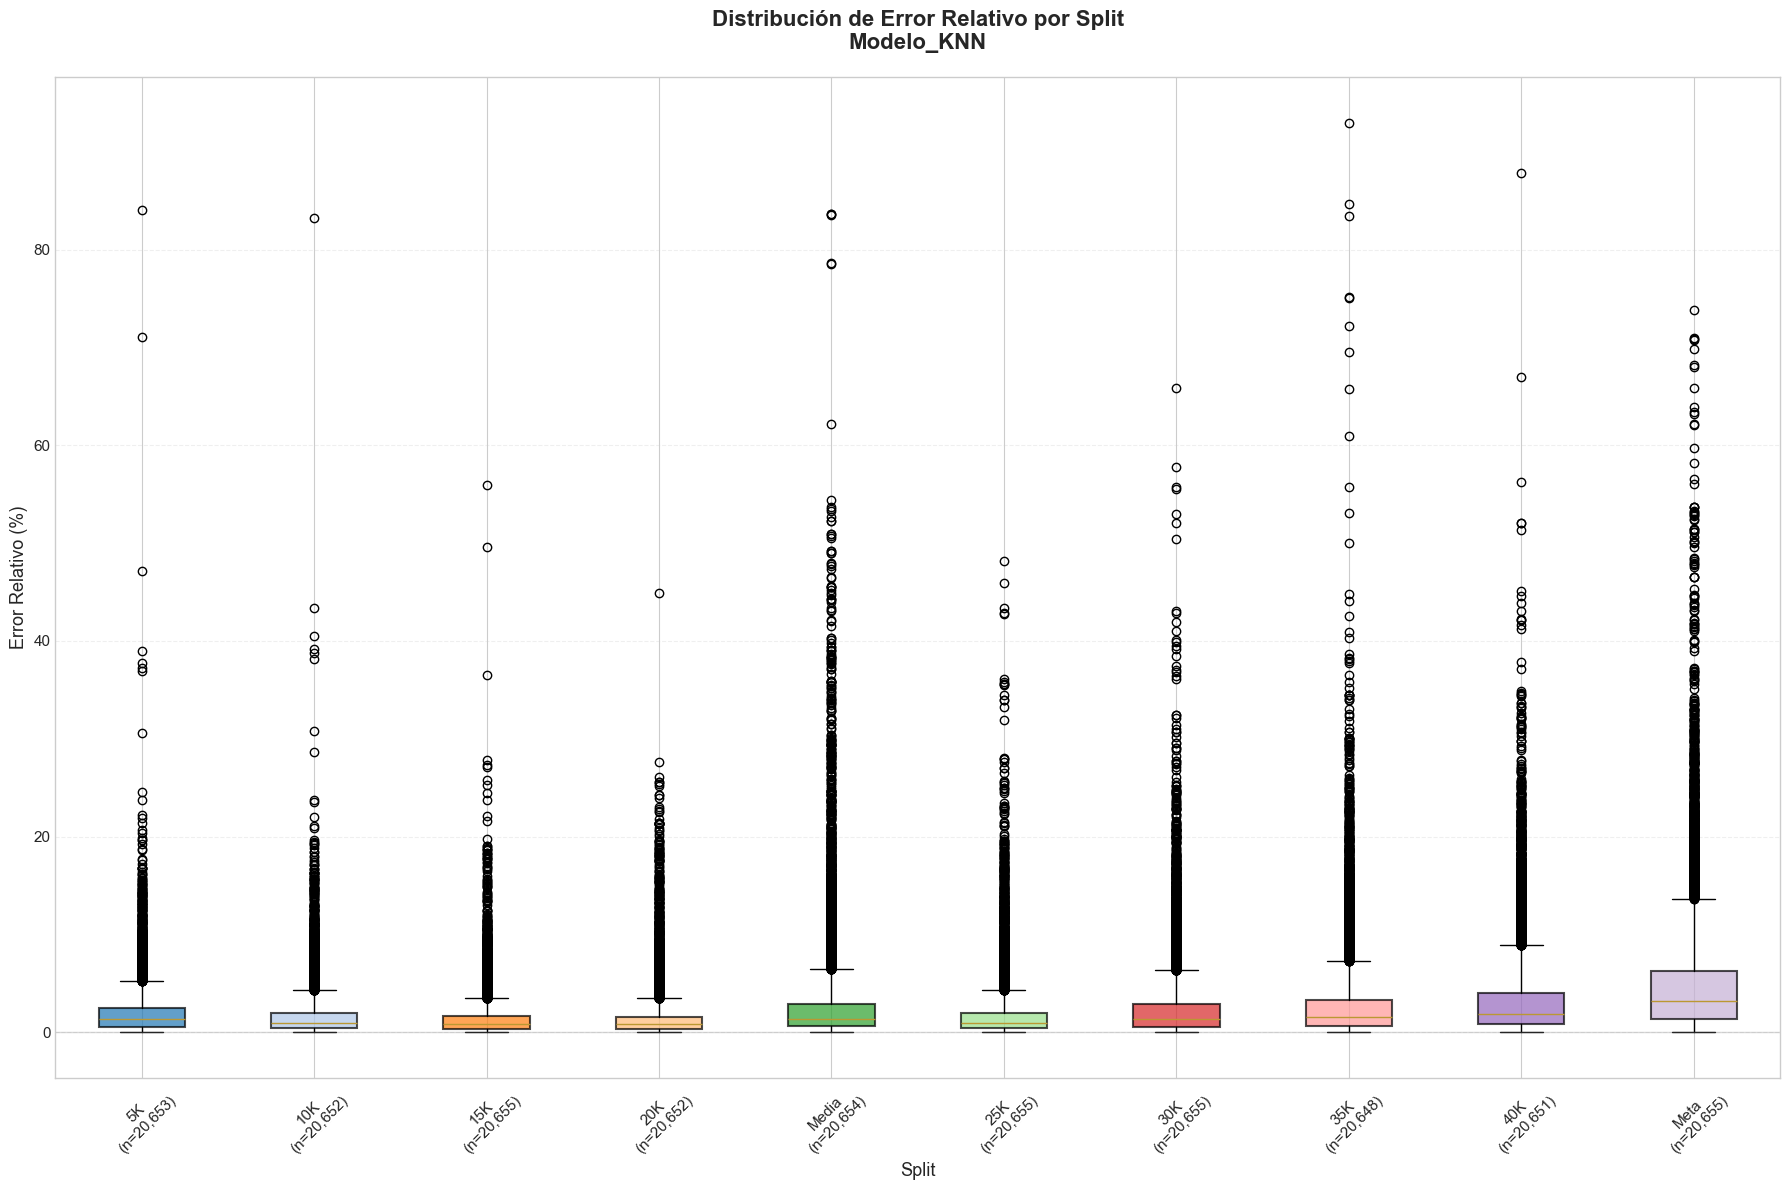

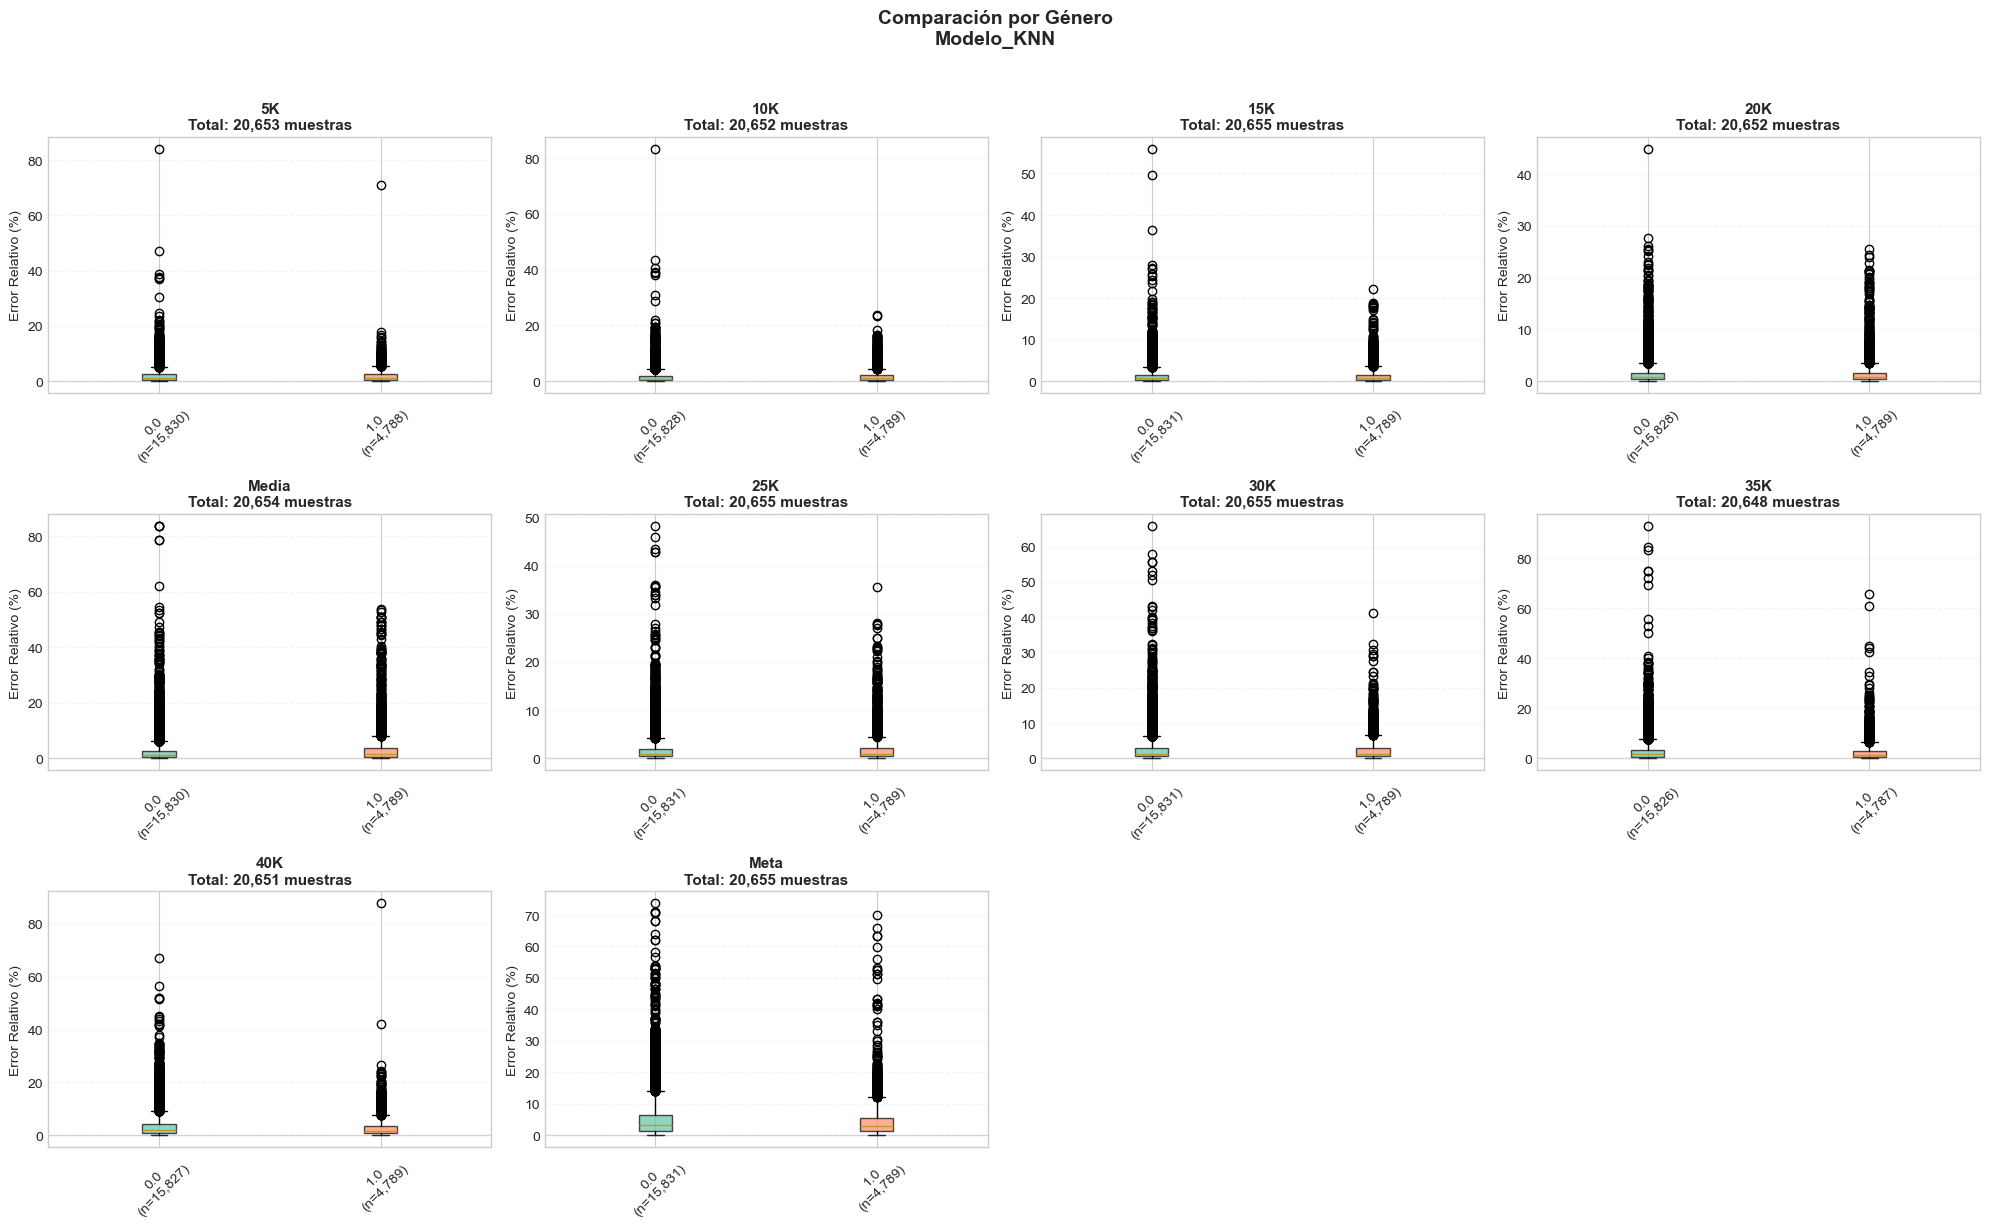

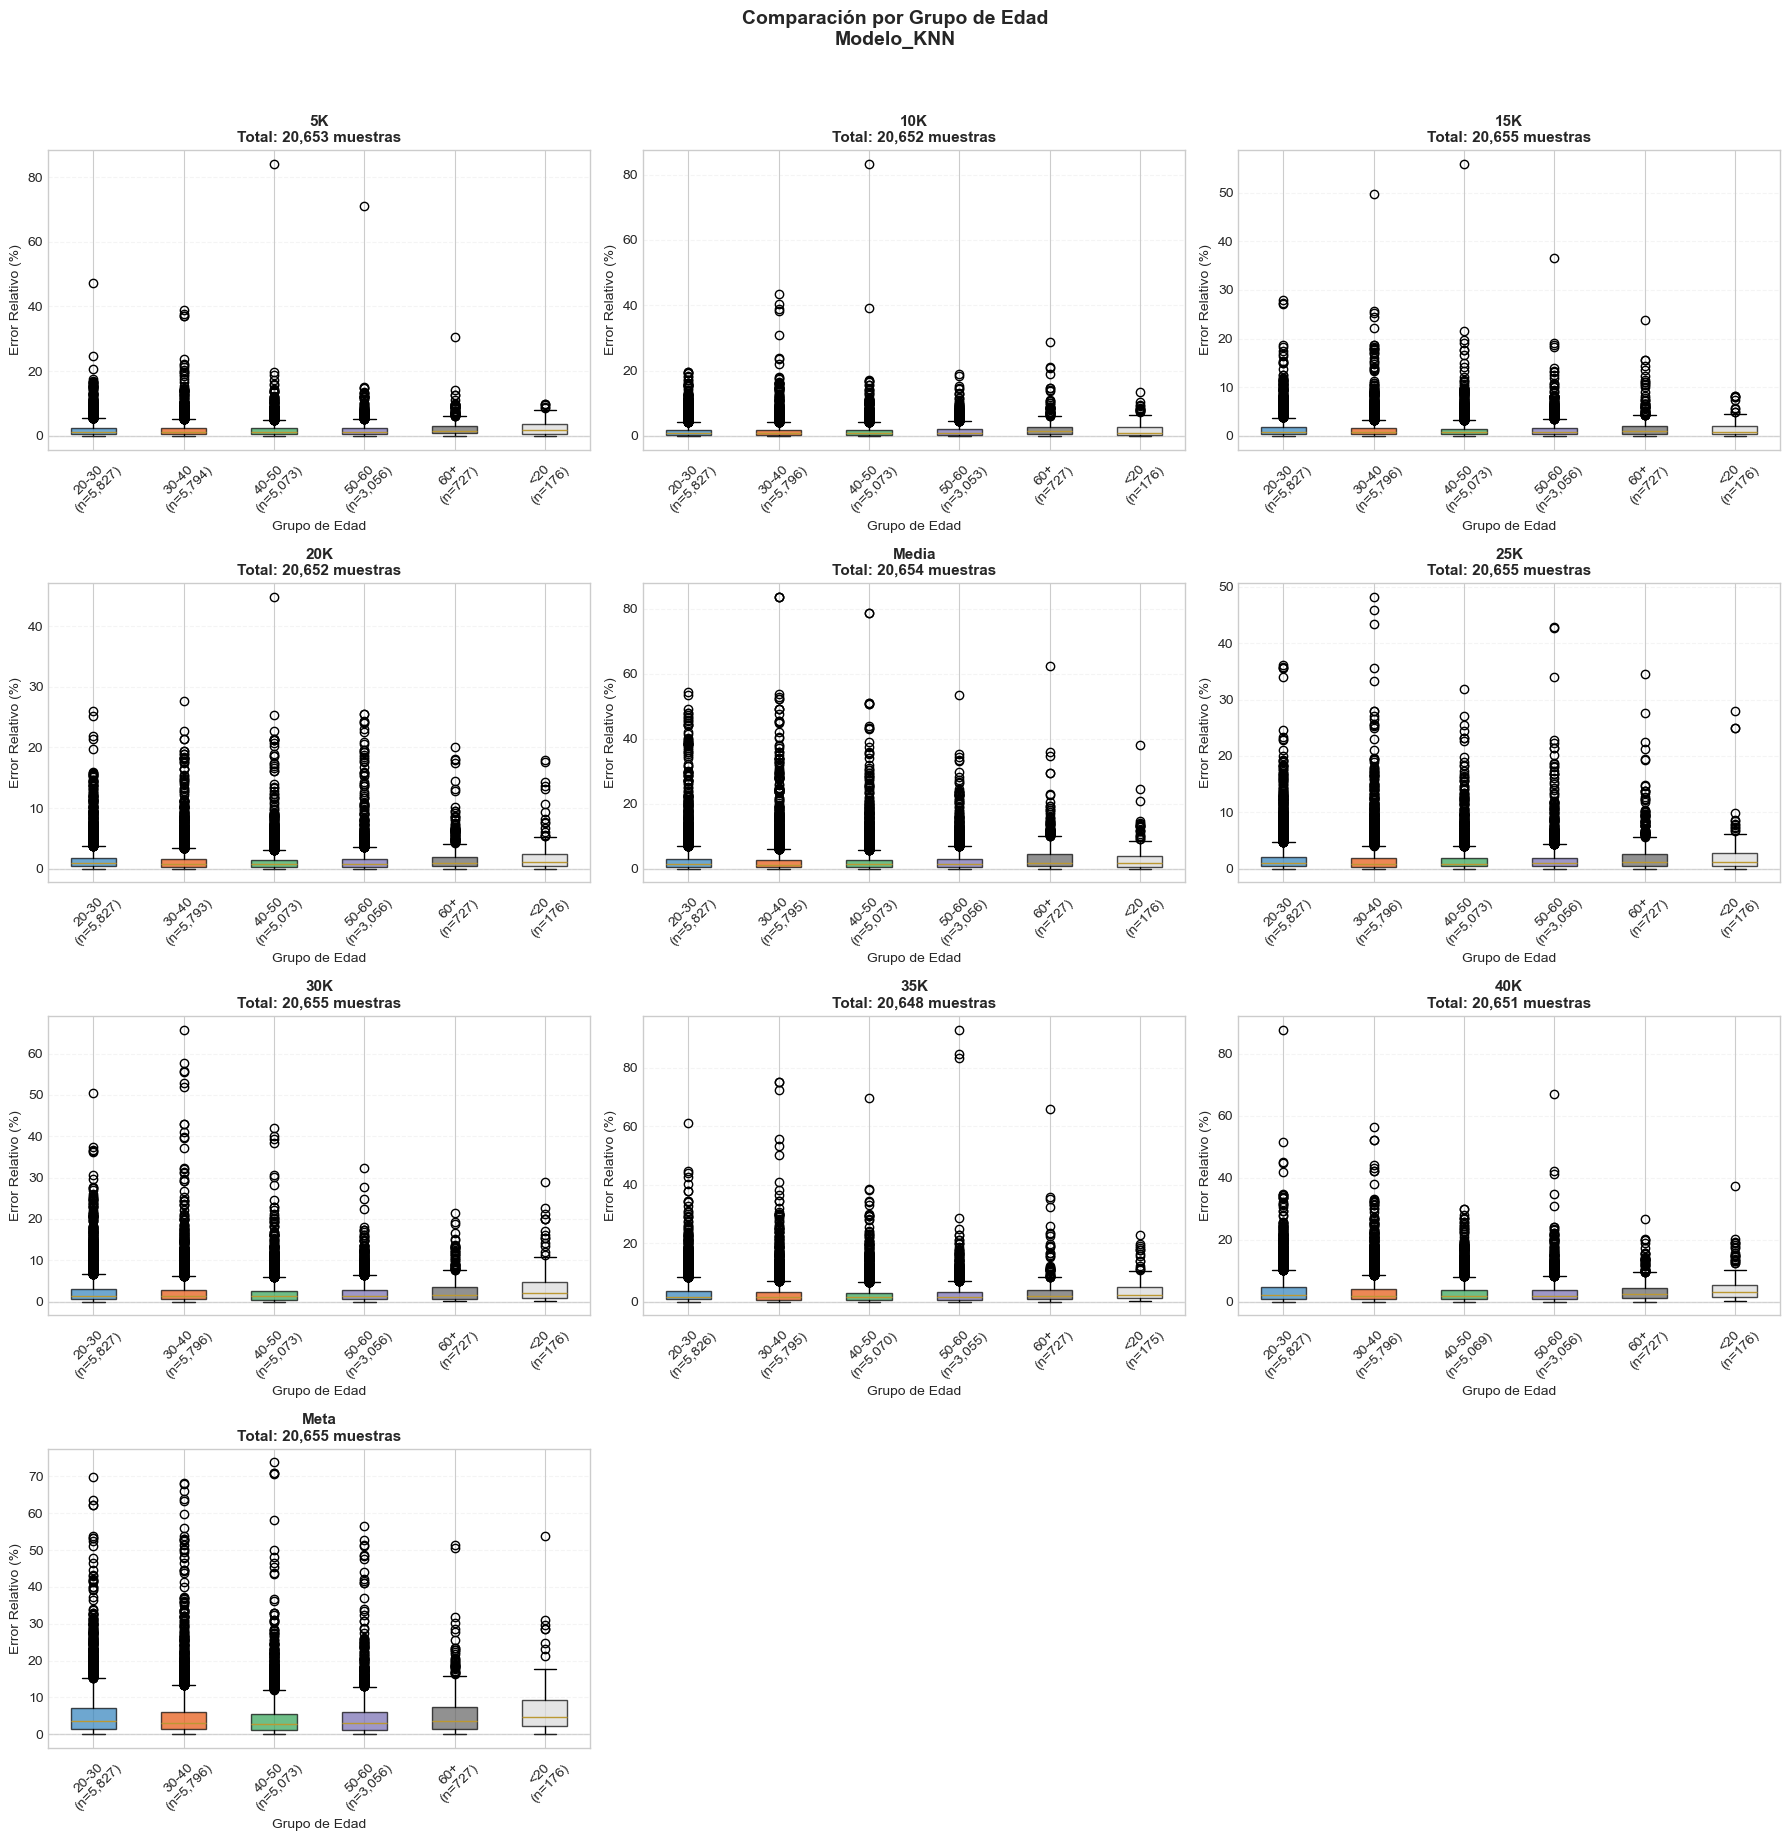

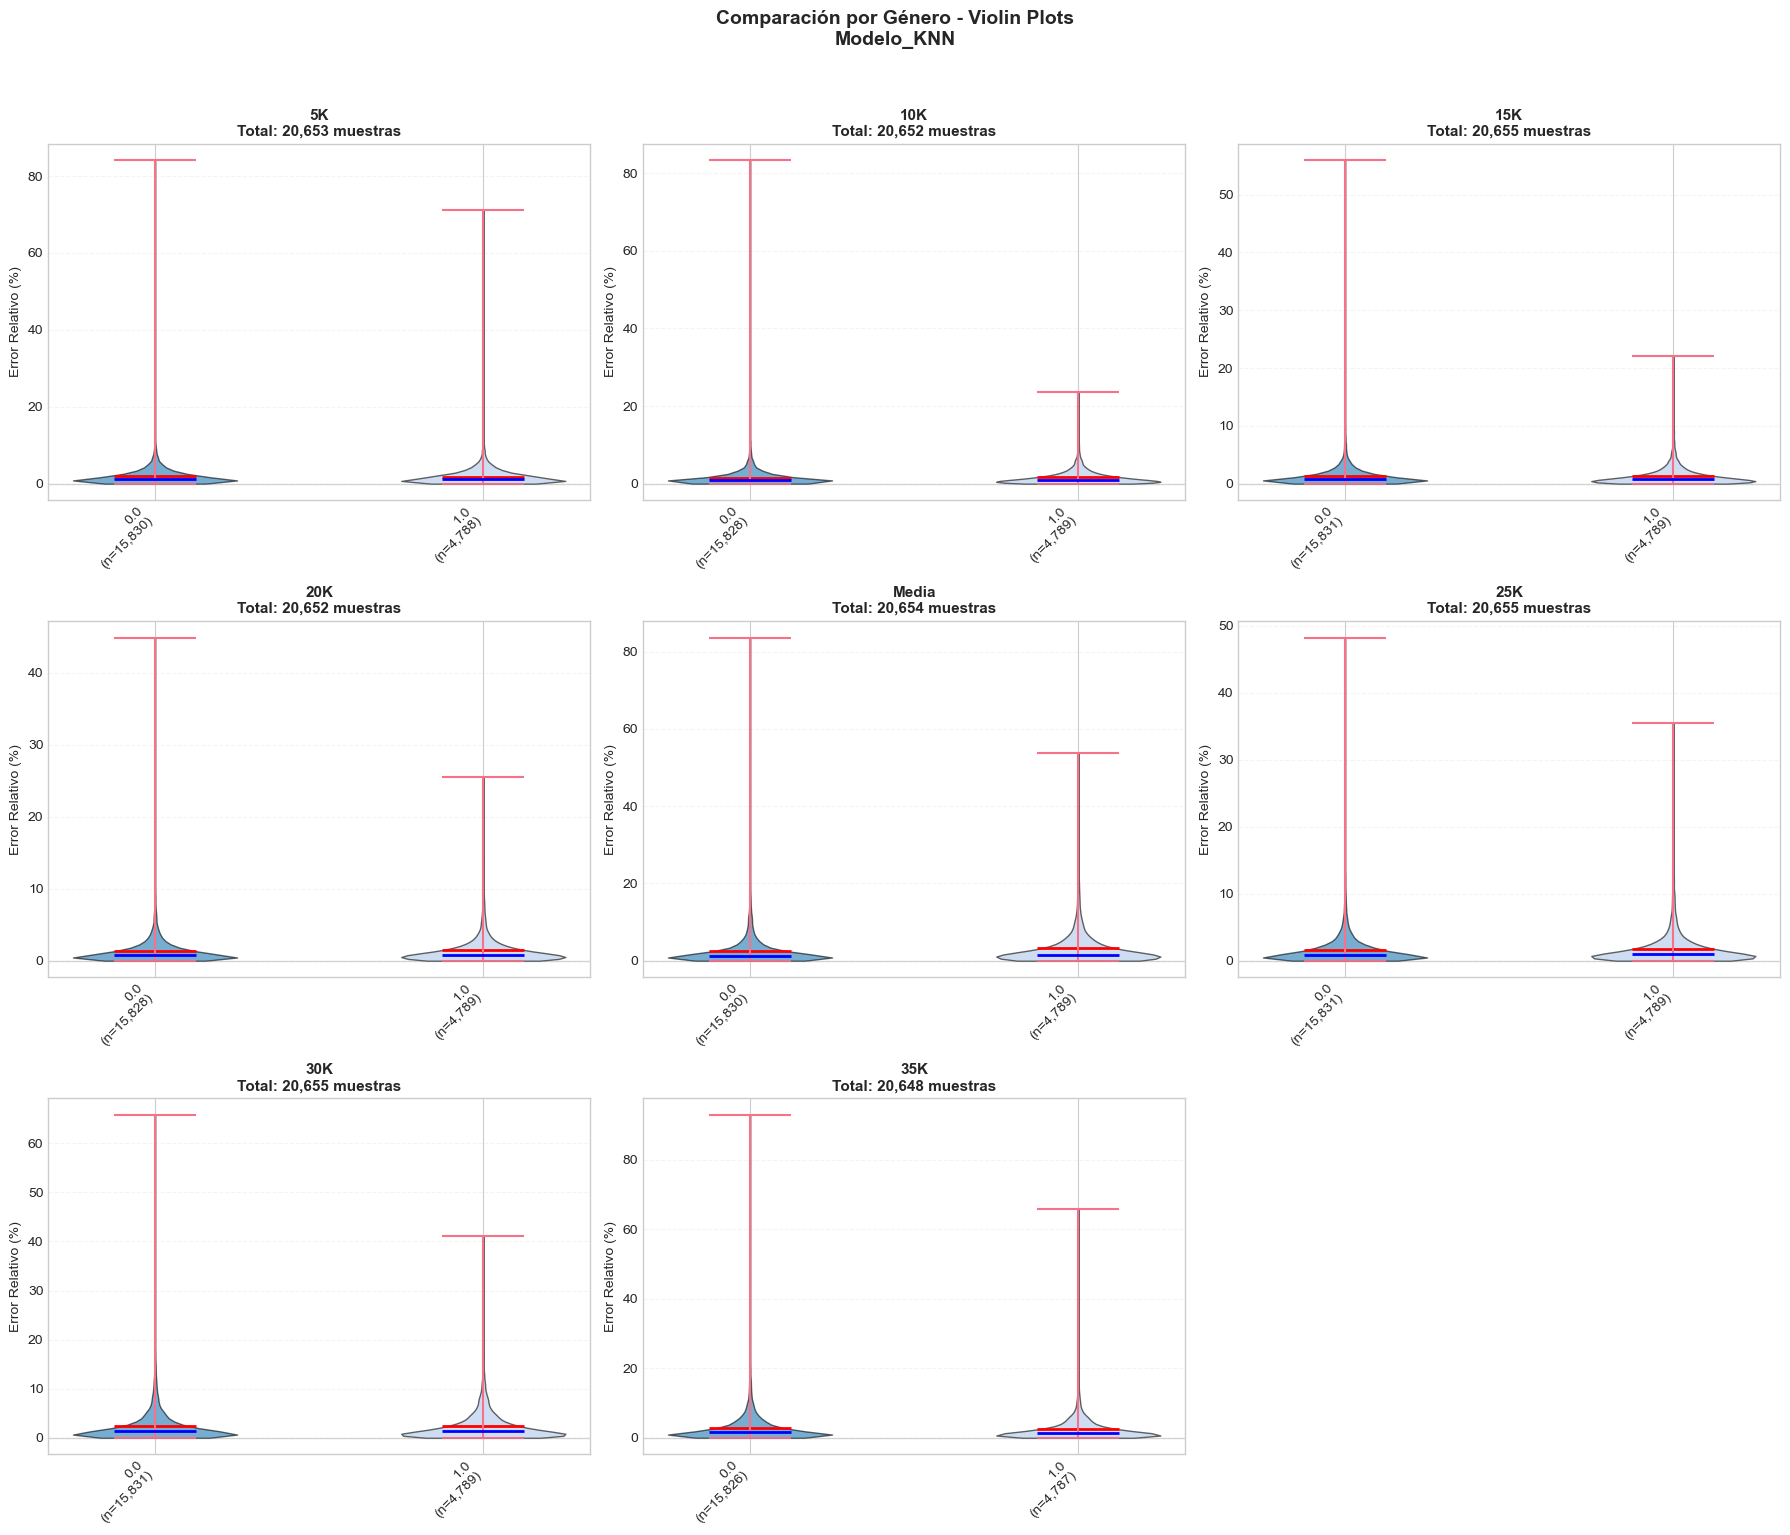

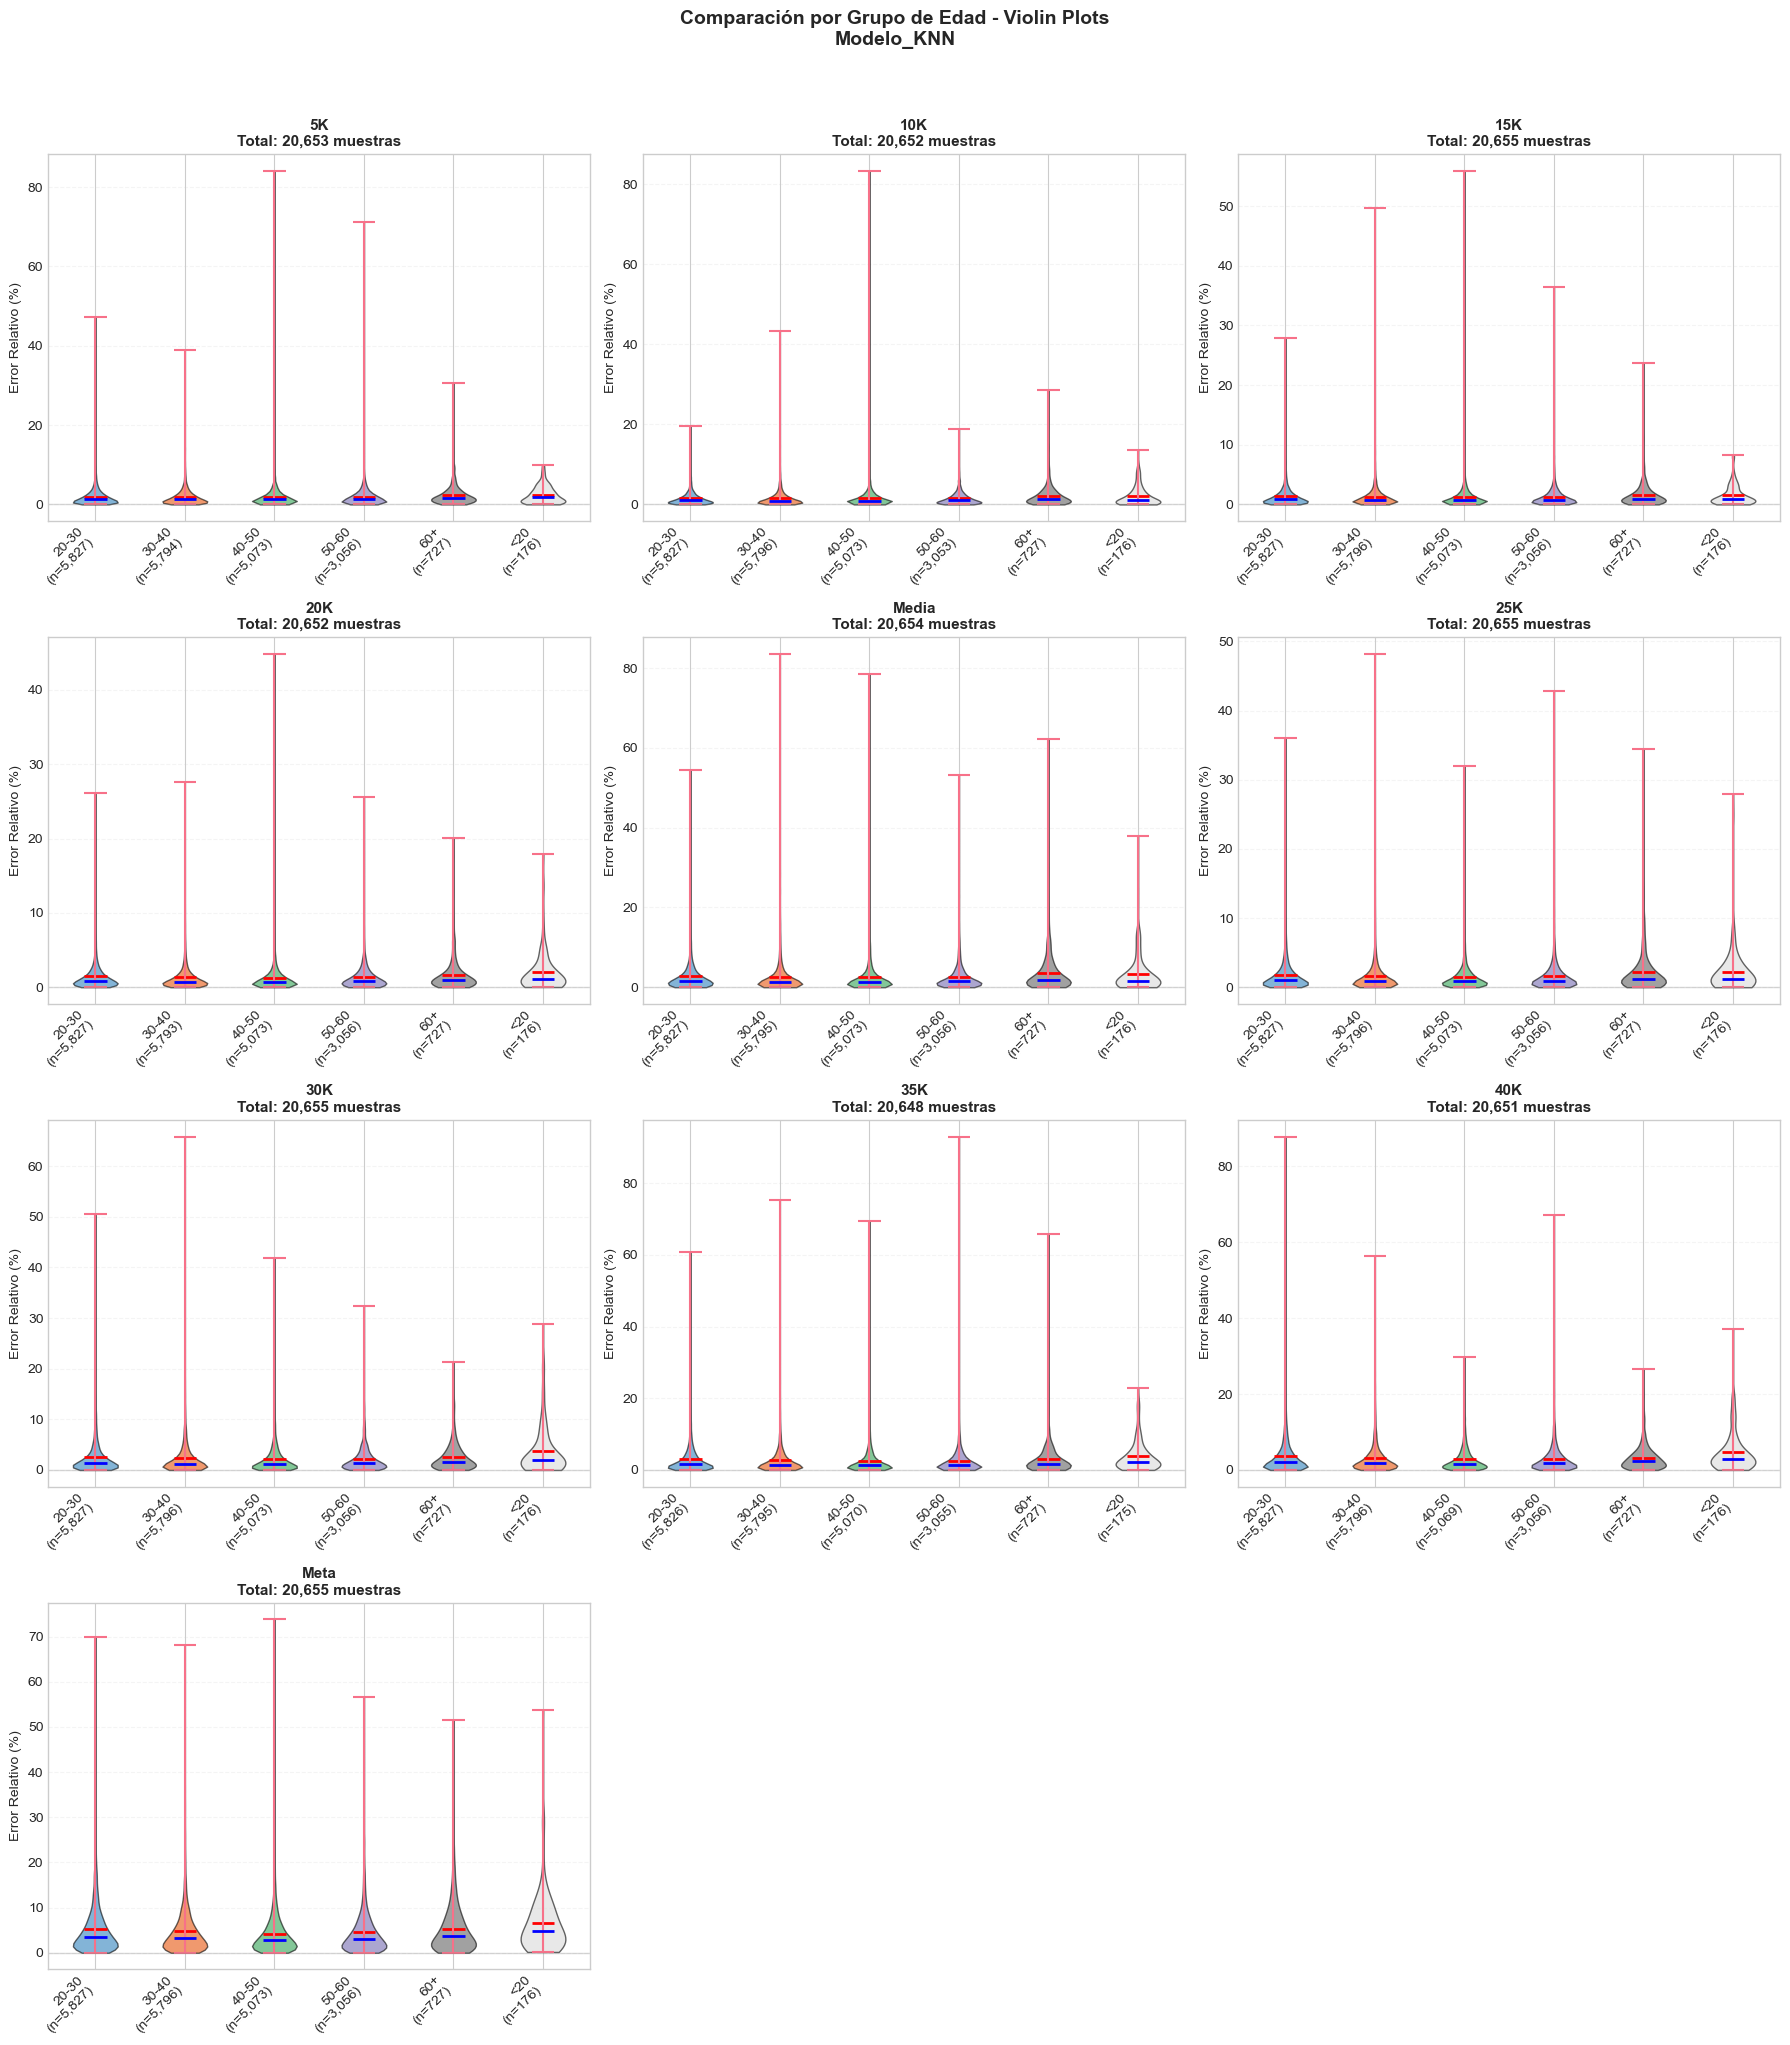

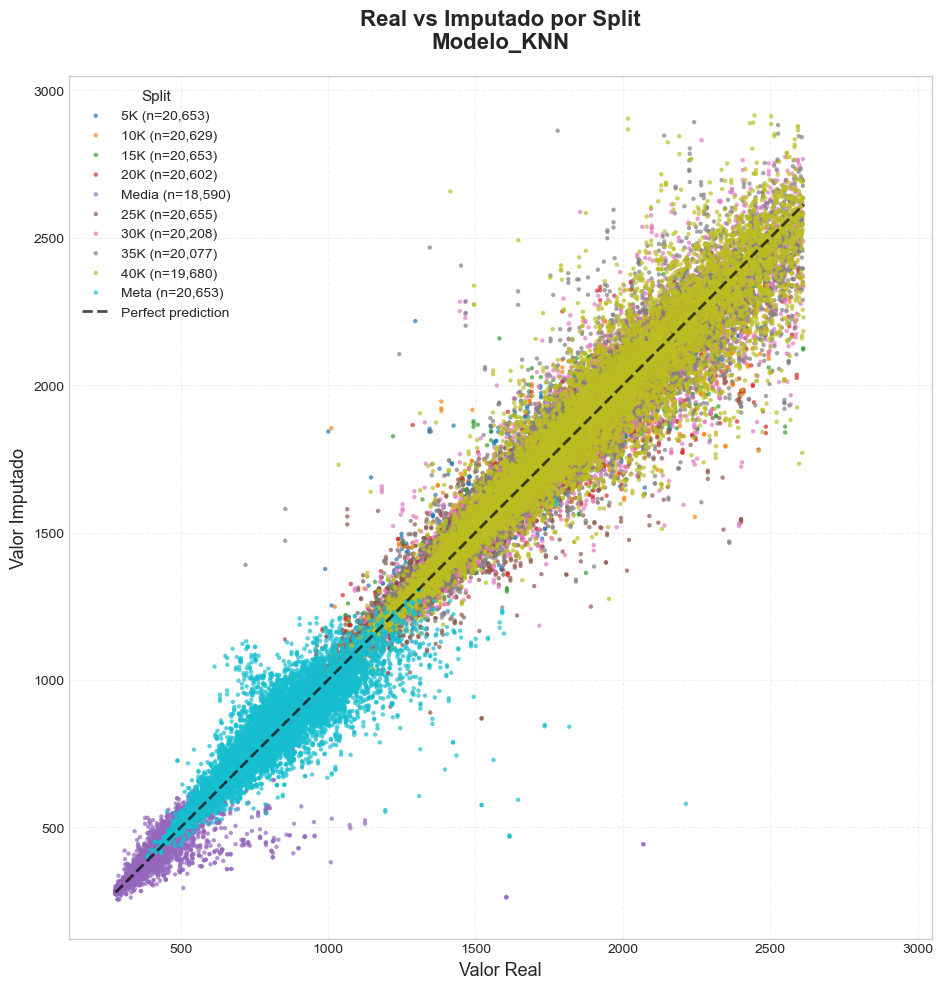


Visualización completada. 6 gráficos generados:
   • boxplots_split
   • boxplots_genero
   • boxplots_edad
   • violin_genero
   • violin_edad
   • scatter_real_vs_imputado


In [32]:
figuras, outliers, resultados_stat = visualizar_analisis_imputacion_robusto(
    resultados=resultados_reg,
    modelo_nombre="Modelo_KNN",
    max_rel_error_pct=100,
    save_path="./resultados/xgboost_analisis",
    show_plots=True
)

cuando se pone ecdf con df_plot no filtrado salen los graficos muy extremios

In [33]:
'''
import pandas as pd

cols_5k = ['5K', '10K', '15K', '20K', '25K', '30K', '35K', '40K']
cols_5k = [c for c in cols_5k if c in df_wide_mar.columns]

df_filtrado = df_wide_mar[
    (df_wide_mar[cols_5k].lt(780).all(axis=1)) &  # todos los parciales < 780 s
    (df_wide_mar['Media'] < 150) &
    (df_wide_mar['Meta'] < 270)
]

print(df_filtrado)
'''

"\nimport pandas as pd\n\ncols_5k = ['5K', '10K', '15K', '20K', '25K', '30K', '35K', '40K']\ncols_5k = [c for c in cols_5k if c in df_wide_mar.columns]\n\ndf_filtrado = df_wide_mar[\n    (df_wide_mar[cols_5k].lt(780).all(axis=1)) &  # todos los parciales < 780 s\n    (df_wide_mar['Media'] < 150) &\n    (df_wide_mar['Meta'] < 270)\n]\n\nprint(df_filtrado)\n"

In [34]:
#print(df_imputed_sec_mar.head(5))
#print(comparison_knn_mar.head(5))
#print(df_wide_mar.head(5))

In [35]:
#comparison_knn_mar.head(5)

In [36]:
df_wide_mar.shape

(20653, 29)

In [37]:
def resumen_columnas(df, bins=20, base_figsize=(6,4)):
    """
    Muestra histogramas y gráficos de barras como subplots grandes en una sola figura por tipo.
    
    base_figsize: tamaño de cada subplot individual (ancho, alto)
    """
    columnas_filtradas = [col for col in df.columns if not col.endswith("_id")]

    continuas = df[columnas_filtradas].select_dtypes(include=['float64', 'float32']).columns
    discretas = df[columnas_filtradas].select_dtypes(include=['int64', 'int32', 'object', 'category']).columns

    print(f"Número de muestras: {len(df)}\n")

    if len(continuas) > 0:
        n_cols = 2
        n_rows = math.ceil(len(continuas) / n_cols)
        figsize = (base_figsize[0]*n_cols, base_figsize[1]*n_rows)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = axes.flatten()
        for i, col in enumerate(continuas):
            axes[i].hist(df[col], bins=bins, edgecolor='k', alpha=0.7)
            axes[i].set_title(f"{col}", fontsize=12)
            axes[i].set_xlabel("Valor", fontsize=10)
            axes[i].set_ylabel("Frecuencia", fontsize=10)
            axes[i].grid(True)
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

    if len(discretas) > 0:
        n_cols = 2
        n_rows = math.ceil(len(discretas) / n_cols)
        figsize = (base_figsize[0]*n_cols, base_figsize[1]*n_rows)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = axes.flatten()
        for i, col in enumerate(discretas):
            df[col].value_counts().plot(kind='bar', edgecolor='k', alpha=0.7, ax=axes[i])
            axes[i].set_title(f"{col}", fontsize=12)
            axes[i].set_xlabel("Categoría", fontsize=10)
            axes[i].set_ylabel("Frecuencia", fontsize=10)
            axes[i].grid(True, axis='y')
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

In [38]:
#resumen_columnas(df_feat_maraton)

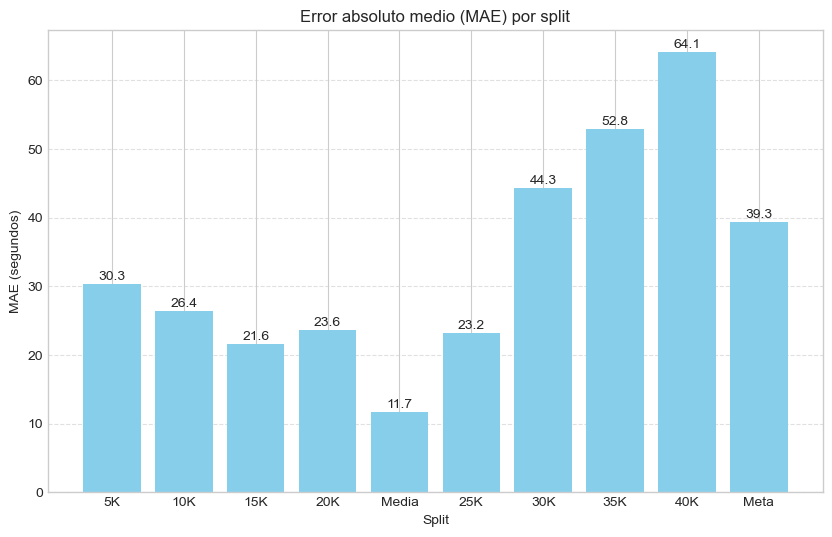

In [39]:
splits_ordered = [s for s in split_cols_maraton if s in mae_per_split_mar]
mae_values_ordered = [mae_per_split_mar[s] for s in splits_ordered]

plt.figure(figsize=(10,6))
plt.bar(splits_ordered, mae_values_ordered, color='skyblue')
plt.xlabel('Split')
plt.ylabel('MAE (segundos)')
plt.title('Error absoluto medio (MAE) por split')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(mae_values_ordered):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center', va='bottom')

plt.show()

In [40]:
df_wide_mar.shape

(20653, 29)

In [41]:
comparison_knn_mar.shape

(206550, 12)

In [42]:
split_distances = {
    '5K': 5,
    '10K': 5,
    '15K': 5,
    '20K': 5,
    'Media': 1.0975,
    '25K': 3.9025,
    '30K': 5,
    '35K': 5,
    '40K': 5,
    'Meta': 2.195
}

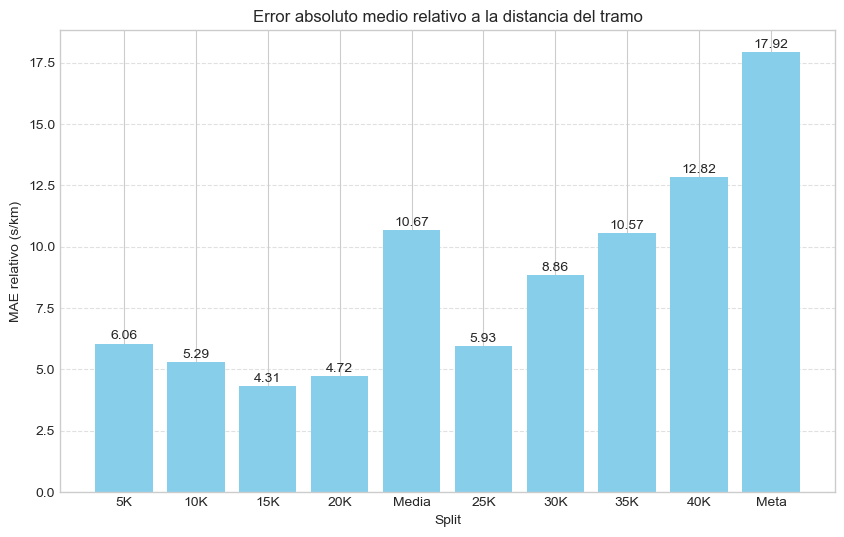

In [43]:
# Ordenar splits que tengan MAE
splits_ordered = [s for s in split_cols_maraton if s in mae_per_split_mar]

# Distancias de cada split (tramo individual)
distances_ordered = [split_distances[s] for s in splits_ordered]

# MAE relativo al tramo
mae_relative = [mae_per_split_mar[s] / split_distances[s] for s in splits_ordered]

# Graficar
plt.figure(figsize=(10,6))
plt.bar(splits_ordered, mae_relative, color='skyblue')
plt.xlabel('Split')
plt.ylabel('MAE relativo (s/km)')
plt.title('Error absoluto medio relativo a la distancia del tramo')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Mostrar valores encima de cada barra
for i, v in enumerate(mae_relative):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', va='bottom')

plt.show()

In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def analisis_mal_imputado(
    df_wide,
    comparison,
    umbrales=[0.10, 0.25, 0.50, 1.0],  # Umbrales para los grupos de error
    radius=0.5,
    n_neighbors_density=15
):
    """
    Analiza imputaciones KNN sin matrices n×n y crea grupos de error.
    
    Devuelve:
    - df_mal: imputaciones con error relativo > 10% (o primer umbral)
    - df_bien: imputaciones con error relativo <= 10% y error > 0
    - df_comparacion: info por atleta y split + columnas de grupos de error
    - df_splits: valores reales por atleta
    - df_features: features usadas para vecindad
    """

    # =====================================================
    # 1. Copia base
    # =====================================================
    df = comparison.copy()
    df['race_athlete_id'] = df['athlete_id'].astype(str) + "_" + df['race_id'].astype(str)

    # Error relativo (por si no existe)
    if 'rel_error' not in df.columns:
        eps = 1e-6
        df['rel_error'] = df['abs_error'] / (df['valor_real'].abs() + eps)

    # =====================================================
    # 2. Crear columnas de grupo de error
    # =====================================================
    for u in umbrales:
        col_name = f'error_mayor_{int(u*100)}%'
        df[col_name] = df['rel_error'].abs() > u

    # Flag principal: mal imputado según primer umbral (10% por defecto)
    df['mal_imputado'] = df[f'error_mayor_{int(umbrales[0]*100)}%']

    # =====================================================
    # 3. Tabla wide de splits reales
    # =====================================================
    df_splits = df.pivot_table(
        index='race_athlete_id',
        columns='split',
        values='valor_real'
    )

    # =====================================================
    # 4. Features para vecindad (solo splits)
    # =====================================================
    df_features = df_splits.copy()

    # Escalado (como en imputación)
    scaler = StandardScaler()
    X = scaler.fit_transform(df_features)

    # =====================================================
    # 5–6. Densidad local basada en kNN (sin O(n²))
    # =====================================================

    nn_k = NearestNeighbors(
        n_neighbors=n_neighbors_density + 1,  # +1 por el self
        metric='nan_euclidean',
        algorithm='brute'   # explícito, evita heurísticas
    )
    nn_k.fit(X)

    distances_k, indices_k = nn_k.kneighbors(X)

    # quitamos self (distancia 0)
    distances_k = distances_k[:, 1:]
    indices_k   = indices_k[:, 1:]

    # Distancia media a k vecinos (tu métrica actual)
    mean_dist_k = pd.Series(
        distances_k.mean(axis=1),
        index=df_features.index,
        name='dist_media_k'
    )

    # NUEVA densidad proxy:
    # cuantos vecinos están "cerca"
    # usa como radio algo relativo al dataset
    r_local = np.nanmedian(distances_k[:, -1])   # distancia típica al k-ésimo vecino

    num_vecinos_radio = pd.Series(
        (distances_k <= r_local).sum(axis=1),
        index=df_features.index,
        name='num_vecinos_radio'
    )

    # =====================================================
    # 7. Dataset de comparación final
    # =====================================================
    cols_a_incluir = ['athlete_id', 'split', 'valor_real', 'valor_imputado', 'abs_error', 'rel_error', 'mal_imputado', 'race_athlete_id'] + [f'error_mayor_{int(u*100)}%' for u in umbrales]

    df_comparacion = df[cols_a_incluir].copy()
    df_comparacion = df_comparacion.merge(num_vecinos_radio, left_on='race_athlete_id', right_index=True)
    df_comparacion = df_comparacion.merge(mean_dist_k, left_on='race_athlete_id', right_index=True)

    # =====================================================
    # 8. Separación bien / mal imputado
    # =====================================================
    df_mal = df_comparacion[df_comparacion['mal_imputado']].copy()
    df_bien = df_comparacion[(~df_comparacion['mal_imputado']) & (df_comparacion['abs_error'] > 0)].copy()

    return df_mal, df_bien, df_comparacion, df_splits, df_features

In [45]:
df_mal_mar, df_bien_mar, df_comparacion_mar, df_splits_mar, df_features_mar = analisis_mal_imputado(df_wide_mar, comparison_knn_mar)

In [46]:
print(df_mal_mar.head(5))
print(df_bien_mar.head(5))
print(df_comparacion_mar.head(5))
print(df_splits_mar.head(5))
print(df_features_mar.head(5))

    athlete_id split   valor_real  valor_imputado   abs_error  rel_error  \
93    176246F3    5K  1709.962036     1486.926147  223.035889   0.130433   
131   1A3ZYBC8    5K  1722.364014     1961.656250  239.292236  -0.138932   
142   1AA946Y6    5K  2039.465942     1827.946655  211.519287   0.103713   
241   21DB7852    5K  1579.433960     1389.705566  189.728394   0.120124   
631   3B1CA412    5K  1642.078979     1874.342285  232.263306  -0.141445   

     mal_imputado                                race_athlete_id  \
93           True  176246F3_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
131          True  1A3ZYBC8_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
142          True  1AA946Y6_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
241          True  21DB7852_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
631          True  3B1CA412_49603c2f-1b2b-457f-b82e-fed8bded1d3d   

     error_mayor_10%  error_mayor_25%  error_mayor_50%  error_mayor_100%  \
93              True            False            False    

In [47]:
df_imputados_mar = pd.concat([df_mal_mar, df_bien_mar], ignore_index=True)

In [48]:
df_imputados_mar.columns

Index(['athlete_id', 'split', 'valor_real', 'valor_imputado', 'abs_error',
       'rel_error', 'mal_imputado', 'race_athlete_id', 'error_mayor_10%',
       'error_mayor_25%', 'error_mayor_50%', 'error_mayor_100%',
       'num_vecinos_radio', 'dist_media_k'],
      dtype='object')

In [49]:
df_imputados_mar['MAE_relativo'] = np.abs(df_imputados_mar['valor_real'] - df_imputados_mar['valor_imputado']) / df_imputados_mar['valor_real']

In [50]:
mae_por_split_mar = df_imputados_mar.groupby('split')['MAE_relativo'].mean().reset_index()

In [51]:
def graficos_variabilidad_split(comparison, df_wide, split_cols=None, boxplot_error='relativo'):
    """
    Genera gráficos por split: MAE relativo, desviación estándar y coeficiente de variación (CV).
    
    Parámetros:
    - comparison: dataframe de imputacion_knn con columnas ['split', 'abs_error', 'rel_error', 'rel_error_pct']
    - df_wide: dataframe con tiempos absolutos por split
    - split_cols: lista con el orden de los splits
    - boxplot_error: 'relativo' o 'absoluto' (para el primer gráfico)
    """
    import matplotlib.pyplot as plt

    if split_cols is None:
        split_cols = comparison['split'].unique()

    # ===== MAE relativo por split =====
    mae_por_split = comparison.groupby('split')['rel_error_pct'].mean().reindex(split_cols).reset_index()
    mae_por_split.columns = ['split', 'MAE_relativo']

    # ===== Desviación estándar =====
    std_por_split = df_wide[split_cols].std().reset_index()
    std_por_split.columns = ['split', 'std_split']

    # ===== Coeficiente de variación =====
    cv_por_split = (df_wide[split_cols].std() / df_wide[split_cols].mean()).reset_index()
    cv_por_split.columns = ['split', 'CV_split']

    # ===== Graficar =====
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    # MAE relativo o absoluto
    if boxplot_error == 'relativo':
        col = 'MAE_relativo'
        ylabel = 'MAE relativo promedio (%)'
    else:
        # MAE absoluto en segundos
        mae_abs_por_split = comparison.groupby('split')['abs_error'].mean().reindex(split_cols).reset_index()
        mae_abs_por_split.columns = ['split', 'MAE_abs']
        col = 'MAE_abs'
        mae_por_split[col] = mae_abs_por_split[col]
        ylabel = 'MAE absoluto promedio (s)'

    axes[0].bar(mae_por_split['split'], mae_por_split[col], color='skyblue')
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(f'MAE {boxplot_error} por split')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    # Desviación estándar
    axes[1].bar(std_por_split['split'], std_por_split['std_split'], color='orange')
    axes[1].set_ylabel('Desviación estándar (s)')
    axes[1].set_title('Variabilidad de tiempo por split')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    # Coeficiente de variación
    axes[2].bar(cv_por_split['split'], cv_por_split['CV_split'], color='green')
    axes[2].set_ylabel('CV de tiempo por split')
    axes[2].set_xlabel('Split')
    axes[2].set_title('Variabilidad relativa (CV) por split')
    axes[2].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

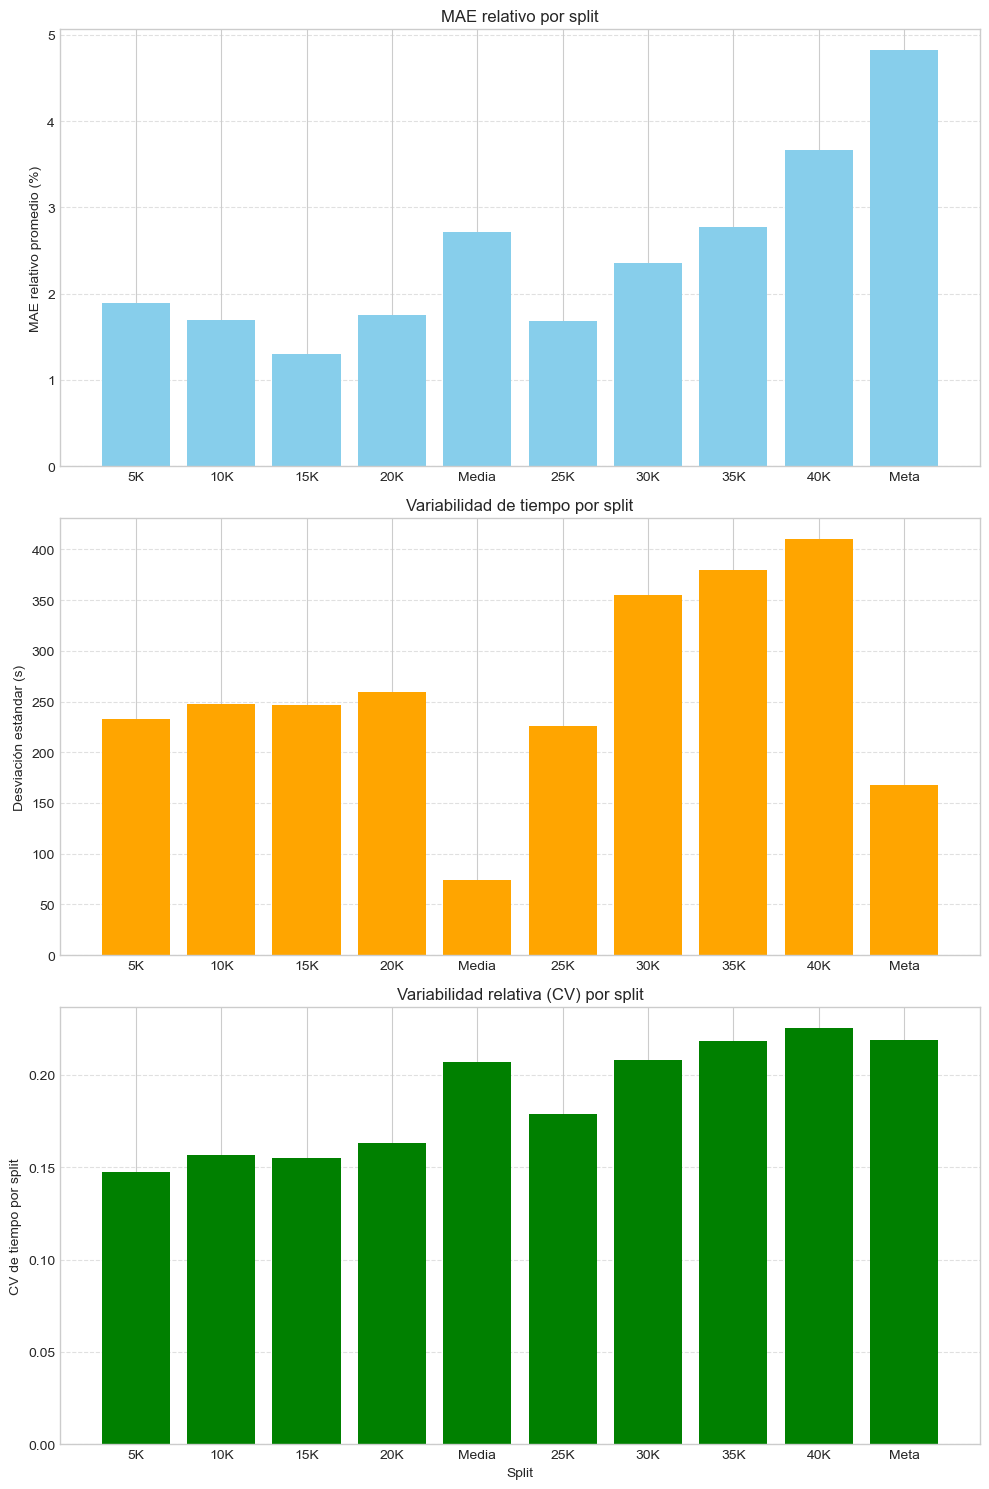

In [52]:
graficos_variabilidad_split(comparison_knn_mar, df_wide_maraton, split_cols=split_cols_maraton, boxplot_error='relativo')

In [53]:
def graficos_variabilidad_error_imputacion(df_imputador_mar, split_cols=['5K','10K','15K','20K','Media','25K','30K','35K','40K','Meta']):
    """
    Genera gráficos por split: MAE relativo, desviación estándar y coeficiente de variación (CV)
    del error absoluto de imputación.
    
    Parámetros:
    - df_imputador_mar: dataframe con columnas ['athlete_id', 'split', 'abs_error']
    - split_cols: lista con el orden de los splits
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # Calcular MAE relativo por split
    #mae_por_split = df_imputador_mar.groupby('split')['abs_error'].mean().reset_index()
    #mae_por_split.columns = ['split', 'MAE_relativo']

    # Calcular desviación estándar por split
    std_por_split = df_imputador_mar.groupby('split')['abs_error'].std().reset_index()
    std_por_split.columns = ['split', 'std_split']

    # Calcular CV por split
    mean_por_split = df_imputador_mar.groupby('split')['abs_error'].mean()
    cv_por_split = (df_imputador_mar.groupby('split')['abs_error'].std() / mean_por_split).reset_index()
    cv_por_split.columns = ['split', 'CV_split']

    # Asegurar el orden de los splits
    #mae_por_split['split'] = pd.Categorical(mae_por_split['split'], categories=split_cols, ordered=True)
    #mae_por_split = mae_por_split.sort_values('split')

    std_por_split['split'] = pd.Categorical(std_por_split['split'], categories=split_cols, ordered=True)
    std_por_split = std_por_split.sort_values('split')

    cv_por_split['split'] = pd.Categorical(cv_por_split['split'], categories=split_cols, ordered=True)
    cv_por_split = cv_por_split.sort_values('split')

    # Graficar
    fig, axes = plt.subplots(2, 1, figsize=(12, 15))

    #axes[0].bar(mae_por_split['split'], mae_por_split['MAE_relativo'], color='skyblue')
    #axes[0].set_ylabel('MAE absoluto promedio (segundos)')
    #axes[0].set_title('MAE por split')
    #axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    axes[0].bar(std_por_split['split'], std_por_split['std_split'], color='orange')
    axes[0].set_ylabel('Desviación estándar (segundos)')
    axes[0].set_title('Variabilidad del error por split')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    axes[1].bar(cv_por_split['split'], cv_por_split['CV_split'], color='green')
    axes[1].set_ylabel('CV del error por split')
    axes[1].set_xlabel('Split')
    axes[1].set_title('Variabilidad relativa (CV) del error por split')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

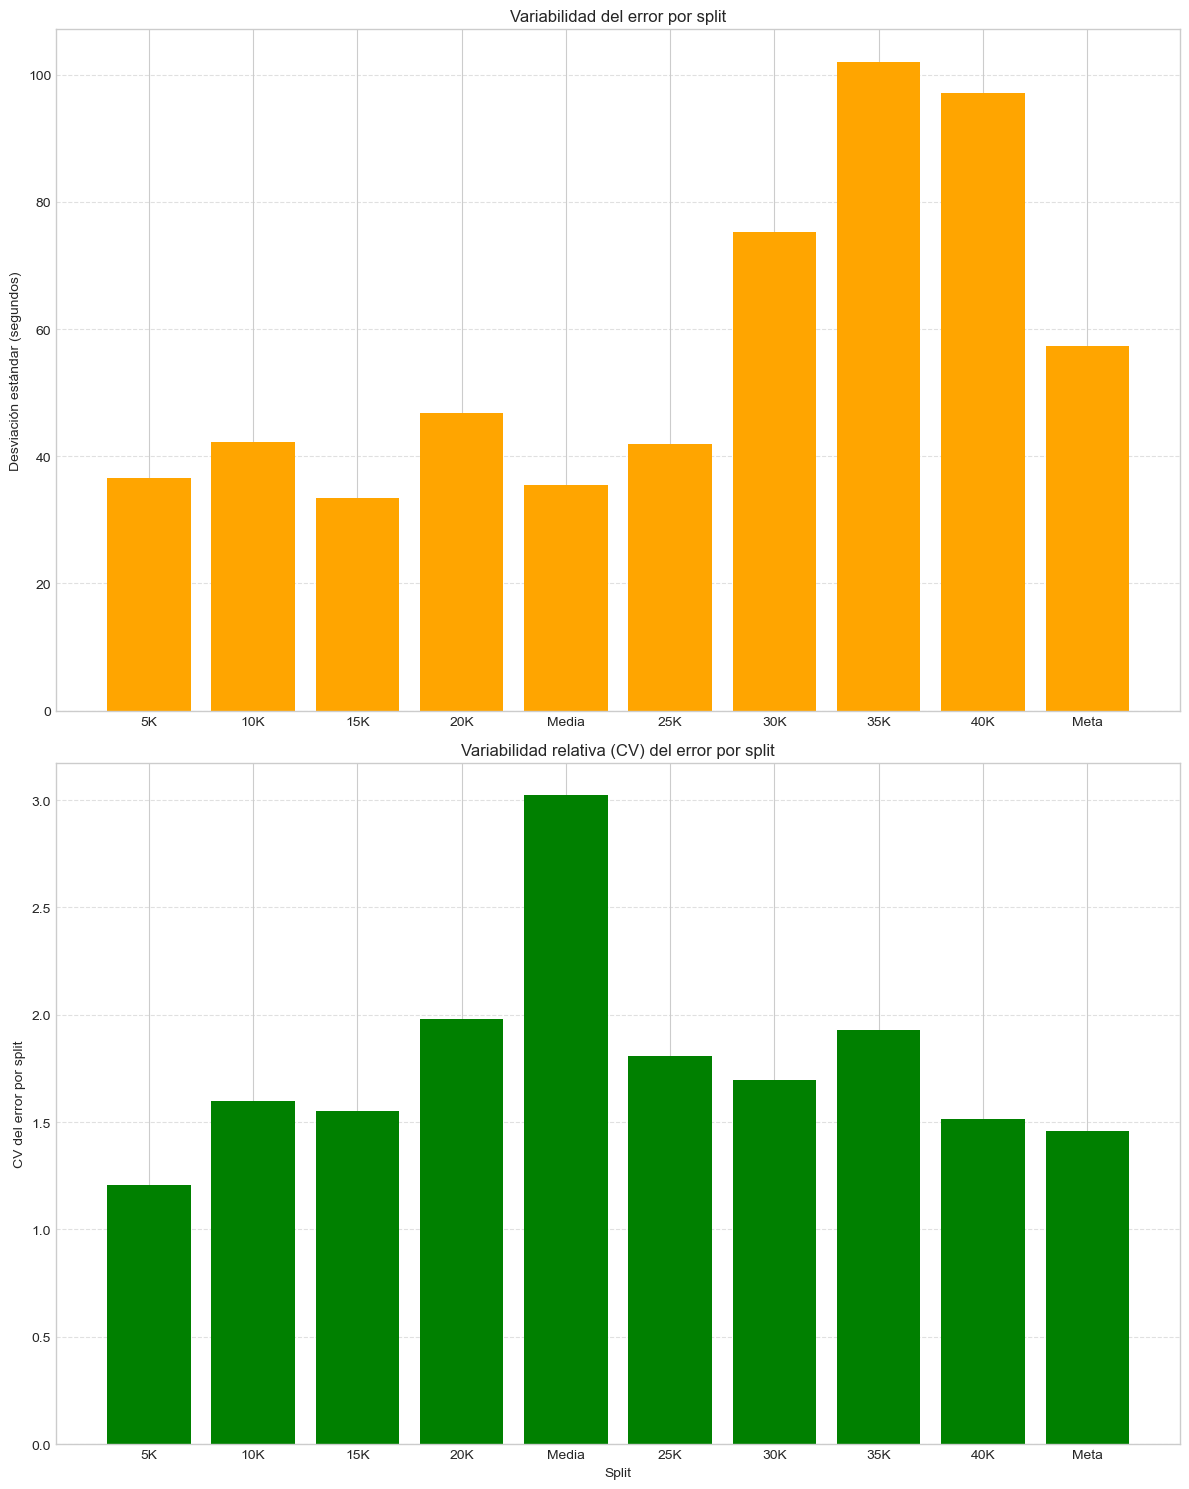

In [54]:
graficos_variabilidad_error_imputacion(df_imputados_mar, split_cols=split_cols_maraton)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns

def analizar_distribucion_error(
    df_comparacion,
    error_col='rel_error_pct',
    por_split=True,
    bins=30,
    kde=True,
    figsize=(15,8),
    verbose=True
):
    """
    Analiza la distribución del error y dibuja todos los splits en un solo plot con subplots.
    
    df_comparacion: DataFrame con al menos columnas 'split', 'rel_error' o 'rel_error_pct'
    error_col: 'rel_error_pct' o 'abs_error' u otra columna de error
    por_split: True -> un subplot por split, False -> solo global
    bins: número de bins para el histograma
    kde: True -> dibuja KDE junto al histograma
    figsize: tamaño de la figura total
    """
    
    # =========================
    # 1. Preparar columna de porcentaje si falta
    # =========================
    if error_col == 'rel_error_pct' and 'rel_error_pct' not in df_comparacion.columns:
        if 'rel_error' in df_comparacion.columns:
            df_comparacion['rel_error_pct'] = df_comparacion['rel_error'] * 100
            if verbose: print("Se creó 'rel_error_pct' a partir de 'rel_error'.")
        else:
            raise KeyError("'rel_error_pct' no existe y tampoco 'rel_error' para calcularlo.")

    # =========================
    # 2. Lista de splits
    # =========================
    splits = df_comparacion['split'].unique() if por_split else [None]
    n_splits = len(splits)
    
    # Definir layout de subplots
    ncols = 3  # número de columnas
    nrows = int(np.ceil(n_splits / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    
    resultados = {}
    
    for i, split in enumerate(splits):
        ax = axes[i]
        if split is not None:
            data = df_comparacion[df_comparacion['split']==split][error_col].dropna()
            title = f"Split: {split}"
        else:
            data = df_comparacion[error_col].dropna()
            title = "Global"
        
        if len(data) == 0:
            ax.set_visible(False)
            continue
        
        # Estadísticas
        s = skew(data)
        k = kurtosis(data)
        resultados[split if split is not None else 'Global'] = {'skew': s, 'kurtosis': k}
        
        if verbose:
            print(f"{title} -> Skew: {s:.3f}, Kurtosis: {k:.3f}, n={len(data)}")
        
        # Histograma + KDE
        sns.histplot(data, bins=bins, kde=kde, color='skyblue', edgecolor='k', ax=ax)
        ax.set_title(f"{title}\nSkew={s:.2f}, Kurt={k:.2f}")
        ax.set_xlabel(error_col.replace('_',' ').title())
        ax.set_ylabel('Frecuencia')
        ax.grid(True, linestyle='--', alpha=0.4)
    
    # Quitar ejes sobrantes si hay más subplots que splits
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return resultados

Se creó 'rel_error_pct' a partir de 'rel_error'.
Split: 5K -> Skew: -11.593, Kurtosis: 475.942, n=20655
Split: 10K -> Skew: -74.742, Kurtosis: 5984.587, n=20655
Split: 15K -> Skew: 0.057, Kurtosis: 56.329, n=20655
Split: 20K -> Skew: -82.271, Kurtosis: 6804.763, n=20655
Split: Media -> Skew: -19.124, Kurtosis: 1645.475, n=20655
Split: 25K -> Skew: 1.367, Kurtosis: 32.961, n=20655
Split: 30K -> Skew: 0.406, Kurtosis: 25.621, n=20655
Split: 35K -> Skew: -11.330, Kurtosis: 380.161, n=20655
Split: 40K -> Skew: -80.064, Kurtosis: 6566.321, n=20655
Split: Meta -> Skew: -0.279, Kurtosis: 11.448, n=20655


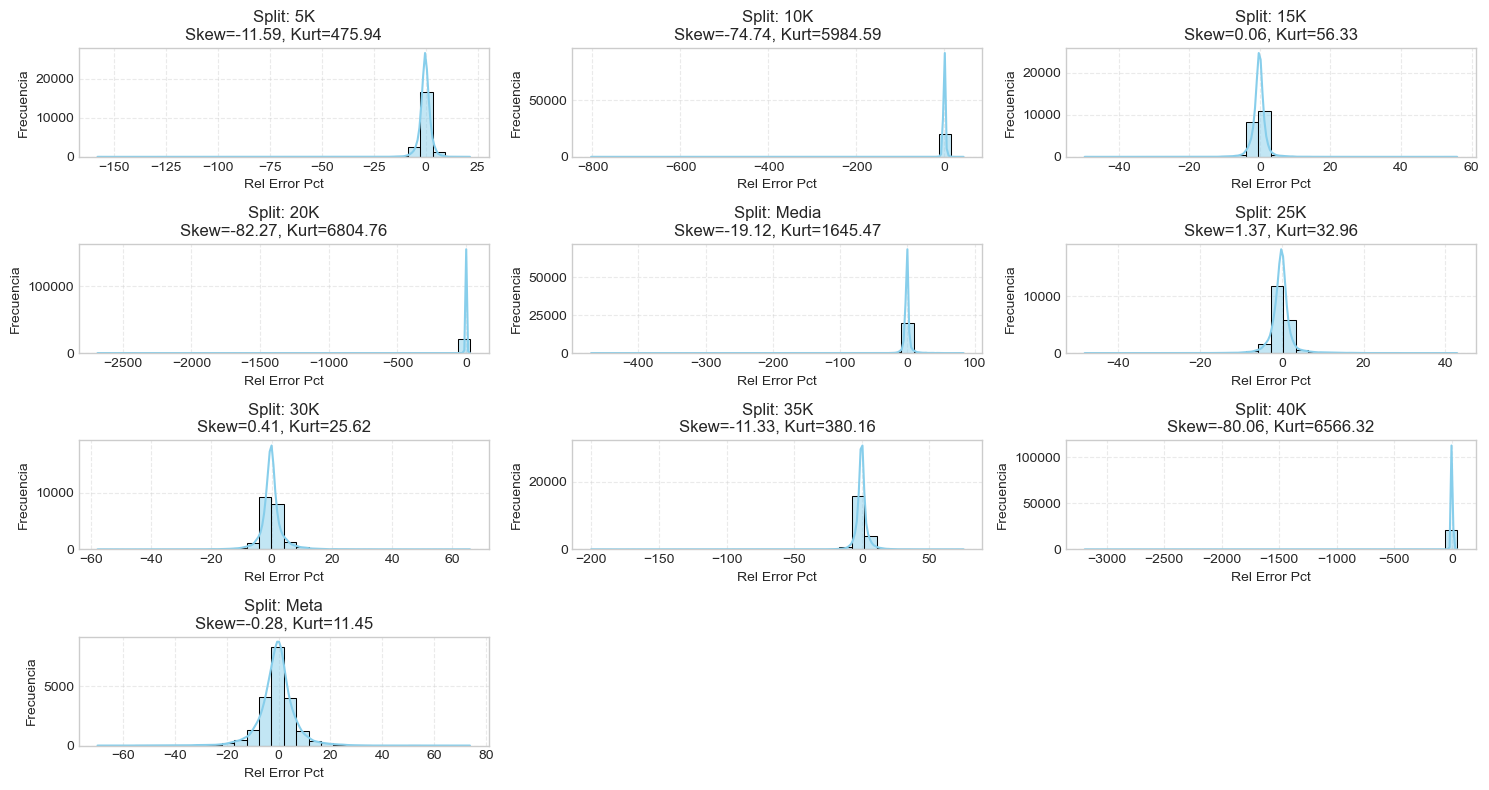

Global -> Skew: 12.239, Kurtosis: 469.473, n=206550


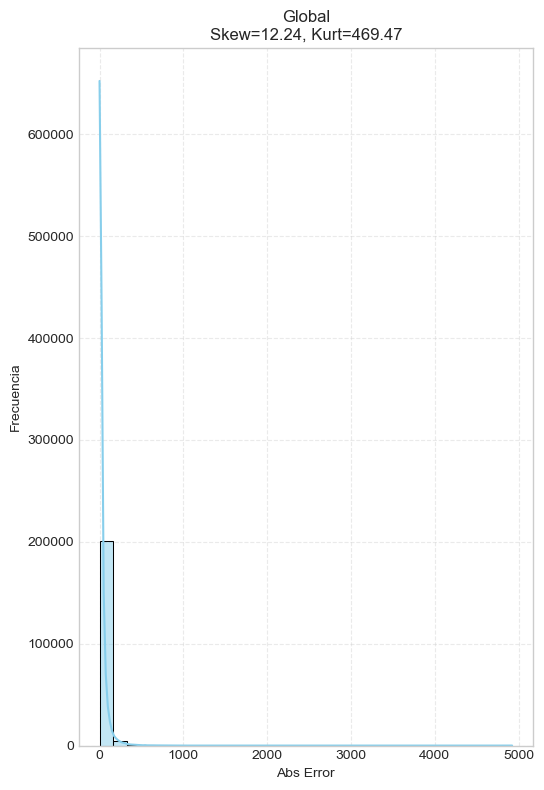

In [56]:
# Analizar error relativo por split
res_skew_kurt = analizar_distribucion_error(df_comparacion_mar, error_col='rel_error_pct', por_split=True)

# Analizar error absoluto global
res_skew_kurt_global = analizar_distribucion_error(df_comparacion_mar, error_col='abs_error', por_split=False)

In [57]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# def analizar_error_acumulado(
#     df_comparacion,
#     df_splits,
#     ordered_splits,
#     error_col='abs_error',
#     plot=True
# ):
#     """
#     Analiza errores de imputación considerando:
#     1. Error acumulado por carrera
#     2. Error vs desviación estándar del split
    
#     df_comparacion: DataFrame con columnas ['athlete_id', 'split', 'valor_real', 'valor_imputado', error_col]
#     df_splits: DataFrame wide de splits reales (athlete_id como índice)
#     ordered_splits: lista con el orden de splits para la acumulación
#     error_col: 'abs_error' o 'rel_error_pct'
#     plot: True -> genera gráficos
#     """
    
#     # ======================================================
#     # 1. Error acumulado por carrera
#     # ======================================================
#     # Pivot de error
#     df_error_wide = df_comparacion.pivot(index='athlete_id', columns='split', values=error_col)
#     df_error_wide = df_error_wide[ordered_splits]  # asegurar orden
    
#     # Suma acumulada
#     df_error_cumsum = df_error_wide.cumsum(axis=1)
    
#     # Promedio acumulado por split
#     mean_error_cumsum = df_error_cumsum.mean()
    
#     # ======================================================
#     # 2. Error vs desviación estándar del split
#     # ======================================================
#     std_splits = df_splits[ordered_splits].std()
#     mean_error_split = df_error_wide.mean()
    
#     df_error_vs_std = pd.DataFrame({
#         'split': ordered_splits,
#         'std_split': std_splits.values,
#         'mean_error': mean_error_split.values
#     })
    
#     # ======================================================
#     # 3. Gráficos
#     # ======================================================
#     if plot:
#         fig, axes = plt.subplots(1,2, figsize=(14,5))
        
#         # a) Error acumulado promedio
#         axes[0].plot(range(len(ordered_splits)), mean_error_cumsum.values, marker='o')
#         axes[0].set_xticks(range(len(ordered_splits)))
#         axes[0].set_xticklabels(ordered_splits, rotation=45)
#         axes[0].set_ylabel(error_col.replace('_',' ').title())
#         axes[0].set_title("Error acumulado promedio por carrera")
#         axes[0].grid(True, linestyle='--', alpha=0.4)
        
#         # b) Error vs std del split
#         axes[1].scatter(df_error_vs_std['std_split'], df_error_vs_std['mean_error'], color='orange')
#         for i, txt in enumerate(df_error_vs_std['split']):
#             axes[1].annotate(txt, (df_error_vs_std['std_split'][i], df_error_vs_std['mean_error'][i]))
#         axes[1].set_xlabel("Desviación estándar del split (s)")
#         axes[1].set_ylabel(error_col.replace('_',' ').title())
#         axes[1].set_title("Error vs desviación estándar del split")
#         axes[1].grid(True, linestyle='--', alpha=0.4)
        
#         plt.tight_layout()
#         plt.show()
    
#     return {
#         'error_cumsum': df_error_cumsum,
#         'mean_error_cumsum': mean_error_cumsum,
#         'error_vs_std': df_error_vs_std
#     }

In [58]:
# resultado = analizar_error_acumulado(
#     df_comparacion=df_comparacion_mar,
#     df_splits=df_splits_mar,
#     ordered_splits=split_cols_maraton,
#     error_col='abs_error',
#     plot=True
# )

In [59]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

def resumen_imputacion(df_comparison, div_col='split', valor_real_col='valor_real',
                        valor_imputado_col='valor_imputado'):
    """
    Crea un DataFrame resumen de la calidad de la imputación KNN por split y global,
    incluyendo número de atletas con error <10%.
    
    Parámetros:
    - df_comparison: DataFrame con al menos las columnas:
        'split', 'valor_real', 'valor_imputado', 'abs_error', 'rel_error'
    - split_col: nombre de la columna que indica el split
    - valor_real_col: columna con valores reales
    - valor_imputado_col: columna con valores imputados
    
    Devuelve:
    - df_resumen: DataFrame con métricas por split y fila global ('ALL')
    """
    
    # Calcular errores absolutos y relativos si no existen
    if 'abs_error' not in df_comparison.columns:
        df_comparison['abs_error'] = (df_comparison[valor_real_col] - df_comparison[valor_imputado_col]).abs()
    if 'rel_error' not in df_comparison.columns:
        eps = 1e-6
        df_comparison['rel_error'] = (df_comparison[valor_real_col] - df_comparison[valor_imputado_col]) / df_comparison[valor_real_col]
    
    # Función resumen por grupo
    def calc_metrics(df):
        n = len(df)
        mae_abs = df['abs_error'].mean()
        mae_rel = df['rel_error'].mean()
        std_abs = df['abs_error'].std()
        cv_abs = std_abs / mae_abs if mae_abs != 0 else np.nan
        
        # Percentiles más finos
        p10 = df['rel_error'].quantile(0.10)
        p25 = df['rel_error'].quantile(0.25)
        p50 = df['rel_error'].quantile(0.50)
        p75 = df['rel_error'].quantile(0.75)
        p90 = df['rel_error'].quantile(0.90)
        p95 = df['rel_error'].quantile(0.95)
        p99 = df['rel_error'].quantile(0.99)
        
        r2 = r2_score(df[valor_real_col], df[valor_imputado_col]) if n > 1 else np.nan

        # Conteos por umbral
        n_out_10 = (df['rel_error'].abs() >= 0.10).sum()
        n_out_25 = (df['rel_error'].abs() >= 0.25).sum()
        n_out_50 = (df['rel_error'].abs() >= 0.50).sum()
        n_out_100 = (df['rel_error'].abs() >= 1.0).sum()
        n_less_10 = (df['rel_error'].abs() < 0.10).sum()  # NUEVO: atletas <10% de error
        
        return pd.Series({
            'n_atletas': n,
            'MAE_abs': mae_abs,
            'MAE_rel': mae_rel,
            'std_abs': std_abs,
            'CV_abs': cv_abs,
            'p10_rel': p10,
            'p25_rel': p25,
            'p50_rel': p50,
            'p75_rel': p75,
            'p90_rel': p90,
            'p95_rel': p95,
            'p99_rel': p99,
            'R2': r2,
            'n_less_10%': n_less_10,      
            'n_error_≥10%': n_out_10,
            'n_error_≥25%': n_out_25,
            'n_error_≥50%': n_out_50,
            'n_error_≥100%': n_out_100
        })

    
    # Resumen por split
    df_resumen_split = df_comparison.groupby(div_col).apply(calc_metrics).reset_index()
    
    # Resumen global
    df_resumen_global = calc_metrics(df_comparison).to_frame().T
    df_resumen_global[div_col] = 'ALL'
    df_resumen_global = df_resumen_global[df_resumen_split.columns]
    
    # Concatenar
    df_resumen = pd.concat([df_resumen_split, df_resumen_global], ignore_index=True)
    
    return df_resumen

In [60]:
resumen_imputacion(df_comparacion_mar, div_col='split', valor_real_col='valor_real', valor_imputado_col='valor_imputado')

,split,n_atletas,MAE_abs,MAE_rel,std_abs,CV_abs,p10_rel,p25_rel,p50_rel,p75_rel,p90_rel,p95_rel,p99_rel,R2,n_less_10%,n_error_≥10%,n_error_≥25%,n_error_≥50%,n_error_≥100%
0,10K,20655.0,26.430405,-0.003244,42.248348,1.598475,-0.025068,-0.012399,-0.002089,0.006967,0.020317,0.034004,0.077038,0.959902,20472.0,183.0,11.0,4.0,3.0
1,15K,20655.0,21.558130,-0.002789,33.473476,1.552708,-0.022456,-0.010446,-0.002066,0.005418,0.015122,0.023626,0.057352,0.973956,20546.0,109.0,8.0,1.0,0.0
2,20K,20655.0,23.583818,-0.005952,46.727016,1.981317,-0.021973,-0.010626,-0.001955,0.005434,0.014977,0.026076,0.076240,0.960015,20452.0,203.0,10.0,3.0,3.0
3,25K,20655.0,23.157667,-0.002193,41.914963,1.809982,-0.026874,-0.012397,-0.001964,0.006639,0.019036,0.032128,0.098769,0.955756,20334.0,321.0,26.0,0.0,0.0
4,30K,20655.0,44.280239,-0.000338,75.215851,1.698632,-0.033316,-0.014754,-0.001943,0.010813,0.035718,0.059189,0.128775,0.938752,19997.0,658.0,46.0,7.0,0.0
5,35K,20655.0,52.848621,-0.001513,101.970543,1.929483,-0.040924,-0.017036,-0.001603,0.013012,0.039942,0.065939,0.143855,0.908502,19814.0,841.0,81.0,19.0,7.0
6,40K,20655.0,64.092239,-0.004633,97.150620,1.515794,-0.046082,-0.020098,-0.002753,0.016986,0.050020,0.083284,0.161085,0.919663,19434.0,1221.0,76.0,10.0,4.0
7,5K,20655.0,30.278868,-0.002991,36.575356,1.207950,-0.031026,-0.014955,-0.001788,0.011019,0.025532,0.037269,0.066871,0.958964,20490.0,165.0,10.0,4.0,2.0
8,Media,20655.0,11.709235,-0.002177,35.410133,3.024120,-0.040046,-0.018842,-0.004536,0.007798,0.028610,0.062229,0.199139,0.764539,19700.0,955.0,165.0,18.0,1.0
9,Meta,20655.0,39.338284,-0.006586,57.353878,1.457966,-0.080503,-0.037495,-0.004649,0.025737,0.065876,0.097556,0.194659,0.811170,18311.0,2344.0,241.0,36.0,0.0


In [61]:
def plot_error_histograms_by_split(df, split_col='split', error_col='abs_error', bins=20, base_figsize=(6,4)):
    """
    Dibuja histogramas de los errores absolutos por cada split, ajustando automáticamente
    el tamaño de la figura para que los subplots no queden aplastados.

    Parámetros:
    - df: DataFrame con las columnas de split y error absoluto
    - split_col: nombre de la columna con los splits
    - error_col: nombre de la columna con los errores absolutos
    - bins: número de bins en los histogramas
    - base_figsize: tamaño base de cada subplot individual (ancho, alto)
    """
    splits = df[split_col].unique()
    n_splits = len(splits)
    
    n_cols = 2
    n_rows = math.ceil(n_splits / n_cols)
    
    figsize = (base_figsize[0]*n_cols, base_figsize[1]*n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, split in enumerate(splits):
        data_split = df[df[split_col] == split][error_col]
        sns.histplot(data_split, bins=bins, kde=False, color='skyblue', ax=axes[i])
        axes[i].set_title(f'Split: {split}', fontsize=12)
        axes[i].set_xlabel('Error absoluto', fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [62]:
#plot_error_histograms_by_split(df_imputados_mar, split_col='split', error_col='abs_error', bins=25)

Contamos el número de atletas en cada grupo

In [63]:
def resumen_grupos_error(df_mal, por_split=True):
    """
    Calcula y muestra el número de atletas en diferentes grupos de error.

    Grupos considerados:
    - ≥10%
    - ≥25%
    - ≥50%
    - ≥100%

    Parámetros:
    - df_mal: dataframe que contiene al menos las columnas:
        'athlete_id', 'split', 'abs_error', 'valor_real'
    - por_split: bool, si True agrupa por split, si False lo hace global
    """
    import pandas as pd

    # =====================================================
    # 1. Crear columnas de error mayor
    # =====================================================
    umbrales = [0.10, 0.25, 0.50, 1.0]
    for u in umbrales:
        col_name = f'error_mayor_{int(u*100)}%'
        if col_name not in df_mal.columns:
            df_mal[col_name] = df_mal['abs_error'] / df_mal['valor_real'].abs() > u

    # =====================================================
    # 2. Agrupar y mostrar
    # =====================================================
    if por_split:
        splits = df_mal['split'].unique()
        for split in splits:
            df_split = df_mal[df_mal['split'] == split]
            print(f"\n--- Split: {split} ---")
            for u in umbrales:
                col_name = f'error_mayor_{int(u*100)}%'
                n_atletas = df_split[df_split[col_name]]['athlete_id'].nunique()
                print(f"≥{int(u*100)}%: {n_atletas} atletas")
    else:
        print("\n--- Global ---")
        for u in umbrales:
            col_name = f'error_mayor_{int(u*100)}%'
            n_atletas = df_mal[df_mal[col_name]]['athlete_id'].nunique()
            print(f"≥{int(u*100)}%: {n_atletas} atletas")

In [64]:
resumen_grupos_error(df_mal_mar)


--- Split: 5K ---
≥10%: 117 atletas
≥25%: 8 atletas
≥50%: 4 atletas
≥100%: 2 atletas

--- Split: 10K ---
≥10%: 121 atletas
≥25%: 7 atletas
≥50%: 2 atletas
≥100%: 1 atletas

--- Split: 15K ---
≥10%: 79 atletas
≥25%: 6 atletas
≥50%: 1 atletas
≥100%: 0 atletas

--- Split: 20K ---
≥10%: 135 atletas
≥25%: 7 atletas
≥50%: 1 atletas
≥100%: 1 atletas

--- Split: Media ---
≥10%: 671 atletas
≥25%: 111 atletas
≥50%: 11 atletas
≥100%: 1 atletas

--- Split: 25K ---
≥10%: 221 atletas
≥25%: 16 atletas
≥50%: 0 atletas
≥100%: 0 atletas

--- Split: 30K ---
≥10%: 469 atletas
≥25%: 33 atletas
≥50%: 4 atletas
≥100%: 0 atletas

--- Split: 35K ---
≥10%: 607 atletas
≥25%: 55 atletas
≥50%: 15 atletas
≥100%: 6 atletas

--- Split: 40K ---
≥10%: 868 atletas
≥25%: 53 atletas
≥50%: 6 atletas
≥100%: 2 atletas

--- Split: Meta ---
≥10%: 1641 atletas
≥25%: 171 atletas
≥50%: 23 atletas
≥100%: 0 atletas


In [82]:
comparison_knn_mar['fue_imputado'] = comparison_knn_mar['abs_error'] > 0

# Filtramos los atletas bien imputados
atletas_bien_imputados_mar = comparison_knn_mar[
    (comparison_knn_mar['abs_error'] > 0) & 
    (comparison_knn_mar['abs_error'] <= 0.1 * comparison_knn_mar['valor_real'])
]['race_athlete_id'].unique()

# Creamos el DataFrame directamente
df_atletas_bien_imputados = comparison_knn_mar[
    comparison_knn_mar['race_athlete_id'].isin(atletas_bien_imputados_mar)
][['race_athlete_id','split','valor_real','valor_imputado','abs_error', 'rel_error_pct']].copy()

print(df_atletas_bien_imputados.head())
print("Número de atletas imputados con error ≤10%:", len(atletas_bien_imputados_mar))

                                                             race_athlete_id  \
0  05b1654f-a583-5e81-a92b-78fa6637f114_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
1                              11191BAA_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
2                             114500001_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
3                             114500006_49603c2f-1b2b-457f-b82e-fed8bded1d3d   
4                              1154ZB55_49603c2f-1b2b-457f-b82e-fed8bded1d3d   

  split   valor_real  valor_imputado  abs_error  rel_error_pct  
0    5K  1020.526978     1009.228027  11.298950       1.107168  
1    5K  1491.000977     1474.322021  16.678955       1.118641  
2    5K  1179.848999     1162.567505  17.281494       1.464721  
3    5K  1141.224976     1121.737305  19.487671       1.707610  
4    5K  1377.869019     1395.675659  17.806641       1.292332  
Número de atletas imputados con error ≤10%: 13895


In [81]:
comparison_knn_mar.columns

Index(['athlete_id', 'race_id', 'race_athlete_id', 'split', 'valor_real',
       'valor_imputado', 'abs_error', 'gender', 'age', 'age_group',
       'rel_error', 'rel_error_pct', 'fue_imputado'],
      dtype='object')

In [66]:
comparison_knn_mar.head()

,athlete_id,race_id,race_athlete_id,split,valor_real,valor_imputado,abs_error,gender,age,age_group,rel_error,rel_error_pct,fue_imputado
0,05b1654f-a583-5e81-a92b-78fa6637f114,49603c2f-1b2b-457f-b82e-fed8bded1d3d,05b1654f-a583-5e81-a92b-78fa6637f114_49603c2f-1b2b-457f-b82e-fed8bded1d3d,5K,1020.526978,1009.228027,11.298950,1.0,21.149897,20-30,0.011072,1.107168,True
1,11191BAA,49603c2f-1b2b-457f-b82e-fed8bded1d3d,11191BAA_49603c2f-1b2b-457f-b82e-fed8bded1d3d,5K,1491.000977,1474.322021,16.678955,0.0,26.767967,20-30,0.011186,1.118641,True
2,114500001,49603c2f-1b2b-457f-b82e-fed8bded1d3d,114500001_49603c2f-1b2b-457f-b82e-fed8bded1d3d,5K,1179.848999,1162.567505,17.281494,0.0,35.419576,30-40,0.014647,1.464721,True
3,114500006,49603c2f-1b2b-457f-b82e-fed8bded1d3d,114500006_49603c2f-1b2b-457f-b82e-fed8bded1d3d,5K,1141.224976,1121.737305,19.487671,0.0,46.171116,40-50,0.017076,1.707610,True
4,1154ZB55,49603c2f-1b2b-457f-b82e-fed8bded1d3d,1154ZB55_49603c2f-1b2b-457f-b82e-fed8bded1d3d,5K,1377.869019,1395.675659,17.806641,0.0,50.976044,50-60,-0.012923,1.292332,True


In [67]:
todos_atletas_mar = df_wide_mar['race_athlete_id'].unique()
atletas_imputados_mar = np.union1d(atletas_bien_imputados_mar, df_mal_mar['race_athlete_id'].unique())
atletas_no_imputados_mar = np.setdiff1d(todos_atletas_mar, atletas_imputados_mar)

print("Número de atletas no imputados:", len(atletas_no_imputados_mar))

Número de atletas no imputados: 6754


In [92]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_curvas_error_imputacion(
    df_wide, df_mal, atletas_bien_imputados,
    split_positions, splits_seleccionados=None,
    figsize=(12,6), colores=None,
    random_state=42, B=1000
):
    """
    Grafica curvas promedio de tiempos reales por grupo de error de imputación usando bootstrapping.
    
    Parámetros:
    - df_wide: DataFrame con tiempos reales por split
    - df_mal: DataFrame con atletas mal imputados y errores
    - atletas_bien_imputados: lista/array con athlete_id bien imputados (<10%)
    - split_positions: dict con posición acumulada de cada split (km)
    - splits_seleccionados: lista de splits a usar, o None para todos
    - figsize: tamaño de la figura
    - colores: lista de colores para cada grupo
    - random_state: semilla para reproducibilidad
    - B: número de repeticiones bootstrap
    """
    
    if colores is None:
        colores = ['green','orange','red','purple','brown']
    
    splits_ordered = ['5K', '10K', '15K', '20K', 'Media', '25K', '30K', '35K', '40K', 'Meta']
    
    if splits_seleccionados is not None:
        splits_cols = [s for s in splits_ordered if s in splits_seleccionados and s in df_wide.columns]
    else:
        splits_cols = [s for s in splits_ordered if s in df_wide.columns]
    
    posiciones_x = [split_positions[s] for s in splits_cols]

    grupos = {
        '<10%': [a for a in atletas_bien_imputados if a in df_wide['race_athlete_id'].values],
        '≥10%': [a for a in df_mal[df_mal['error_mayor_10%']]['race_athlete_id'].unique() if a in df_wide['race_athlete_id'].values],
        '≥25%': [a for a in df_mal[df_mal['error_mayor_25%']]['race_athlete_id'].unique() if a in df_wide['race_athlete_id'].values],
        '≥50%': [a for a in df_mal[df_mal['error_mayor_50%']]['race_athlete_id'].unique() if a in df_wide['race_athlete_id'].values],
        '≥100%': [a for a in df_mal[df_mal['error_mayor_100%']]['race_athlete_id'].unique() if a in df_wide['race_athlete_id'].values],
    }
    
    n_muestra_ref = min(len(a) for a in grupos.values() if len(a) > 0)
    np.random.seed(random_state)
    
    def boot_curva(atletas, acumulado=True):
        curvas_boot = []
        for b in range(B):
            sample_ids = np.random.choice(atletas, size=n_muestra_ref, replace=True)
            curvas_sample = df_wide[df_wide['race_athlete_id'].isin(sample_ids)][splits_cols]
            if acumulado:
                curvas_sample = curvas_sample.cumsum(axis=1)
            curvas_boot.append(curvas_sample.mean(axis=0).values)
        curvas_boot = np.array(curvas_boot)
        media = curvas_boot.mean(axis=0)
        ci_inf = np.percentile(curvas_boot, 2.5, axis=0)
        ci_sup = np.percentile(curvas_boot, 97.5, axis=0)
        return media, ci_inf, ci_sup

    plt.figure(figsize=figsize)
    for i, (grupo, atletas) in enumerate(grupos.items()):
        if len(atletas) == 0:
            continue
        media, ci_inf, ci_sup = boot_curva(atletas, acumulado=True)
        plt.plot(posiciones_x, media, marker='o', color=colores[i], linewidth=2,
                 label=f'{grupo} (n={len(atletas)})')
        plt.fill_between(posiciones_x, ci_inf, ci_sup, color=colores[i], alpha=0.2)
    
    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo acumulado (segundos)')
    plt.title('Curvas promedio de tiempos acumulados según error de imputación')
    plt.xticks(posiciones_x, splits_cols, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
    
    plt.figure(figsize=figsize)
    for i, (grupo, atletas) in enumerate(grupos.items()):
        if len(atletas) == 0:
            continue
        media, ci_inf, ci_sup = boot_curva(atletas, acumulado=False)
        plt.plot(posiciones_x, media, marker='o', color=colores[i], linewidth=2,
                 label=f'{grupo} (n={len(atletas)})')
        plt.fill_between(posiciones_x, ci_inf, ci_sup, color=colores[i], alpha=0.2)
    
    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo por tramo (segundos)')
    plt.title('Curvas promedio de tiempos por tramo según error de imputación')
    plt.xticks(posiciones_x, splits_cols, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

In [69]:
split_positions = {
    '5K': 5.0,
    '10K': 10.0,
    '15K': 15.0,
    '20K': 20.0,
    'Media': 21.0975,
    '25K': 25.0,
    '30K': 30.0,
    '35K': 35.0,
    '40K': 40.0,
    'Meta': 42.195
}

In [70]:
df_mal_mar.head()

,athlete_id,split,valor_real,valor_imputado,abs_error,rel_error,mal_imputado,race_athlete_id,error_mayor_10%,error_mayor_25%,error_mayor_50%,error_mayor_100%,num_vecinos_radio,dist_media_k
93,176246F3,5K,1709.962036,1486.926147,223.035889,0.130433,True,176246F3_49603c2f-1b2b-457f-b82e-fed8bded1d3d,True,False,False,False,0,0.829650
131,1A3ZYBC8,5K,1722.364014,1961.656250,239.292236,-0.138932,True,1A3ZYBC8_49603c2f-1b2b-457f-b82e-fed8bded1d3d,True,False,False,False,0,2.114364
142,1AA946Y6,5K,2039.465942,1827.946655,211.519287,0.103713,True,1AA946Y6_49603c2f-1b2b-457f-b82e-fed8bded1d3d,True,False,False,False,0,0.739132
241,21DB7852,5K,1579.433960,1389.705566,189.728394,0.120124,True,21DB7852_49603c2f-1b2b-457f-b82e-fed8bded1d3d,True,False,False,False,0,0.606726
631,3B1CA412,5K,1642.078979,1874.342285,232.263306,-0.141445,True,3B1CA412_49603c2f-1b2b-457f-b82e-fed8bded1d3d,True,False,False,False,0,1.859573


In [71]:
# Conteo de atletas con cada tipo de error
errores_resumen = {
    'mal_imputado': df_mal_mar['mal_imputado'].sum(),
    'error_mayor_10%': df_mal_mar['error_mayor_10%'].sum(),
    'error_mayor_25%': df_mal_mar['error_mayor_25%'].sum(),
    'error_mayor_50%': df_mal_mar['error_mayor_50%'].sum(),
    'error_mayor_100%': df_mal_mar['error_mayor_100%'].sum(),
}

# Mostrar resultados
print("Conteo de atletas con errores por categoría:")
for k, v in errores_resumen.items():
    print(f"  {k}: {v}")

Conteo de atletas con errores por categoría:
  mal_imputado: 7000
  error_mayor_10%: 7000
  error_mayor_25%: 674
  error_mayor_50%: 102
  error_mayor_100%: 20


In [90]:
# Supongamos que el race_athlete_id que quieres inspeccionar es '12345'
race_id = '112ABAZ1_49603c2f-1b2b-457f-b82e-fed8bded1d3d'

# Filtrar todas las filas de ese atleta
df_atleta = comparison_knn_mar[comparison_knn_mar['race_athlete_id'] == race_id]

print(df_atleta)

       athlete_id                               race_id  \
4133     112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
16524    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
24788    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
37179    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
45443    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
57834    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
66098    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
78489    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
86753    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
99144    112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
107408   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
119799   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
128063   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
140454   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
148718   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d   
161109   112ABAZ1  49603c2f-1b2b-457f-b82e-fed8bded1d3d 

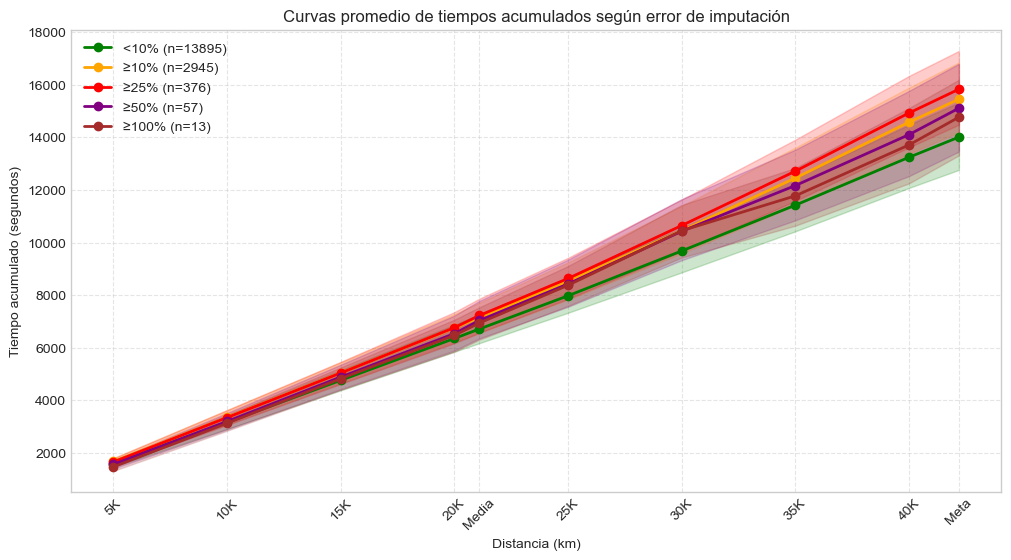

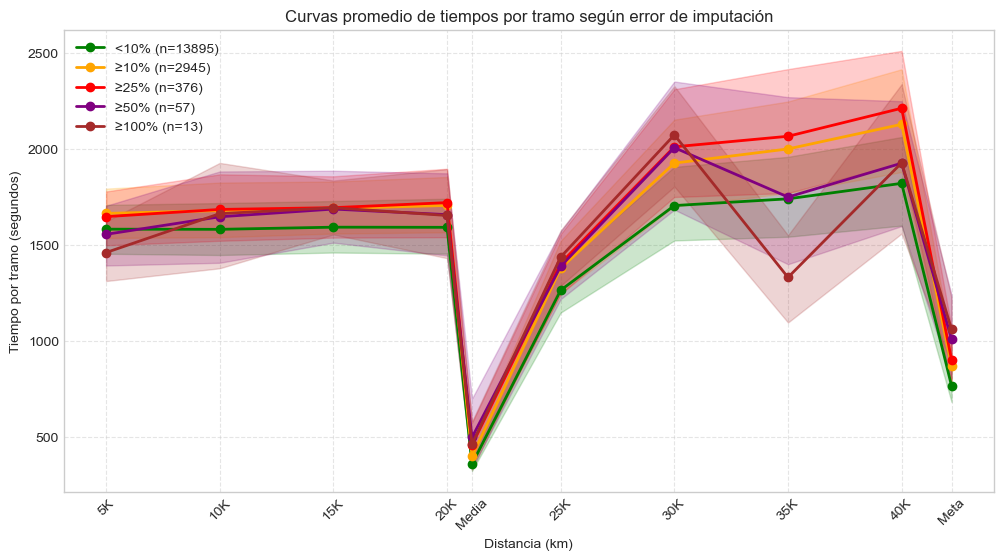

In [94]:
graficar_curvas_error_imputacion(
    df_wide=df_wide_mar,
    df_mal=df_mal_mar,
    atletas_bien_imputados=atletas_bien_imputados_mar,
    split_positions=split_positions,
    random_state=42,
    B=1000
)

#### PLot vecinos knn

In [ ]:
# def plot_knn_neighbors_curves(
#     df_wide, 
#     ordered_splits, 
#     athlete_id_sel, 
#     n_neighbors=5, 
#     split_target=None, 
#     method='imputer',  # 'imputer' o 'classic'
#     show_imputed_diff=True
# ):
#     """
#     Grafica la curva de splits de un atleta junto con sus vecinos según KNN.

#     Parámetros:
#     - df_wide: DataFrame original con columnas de splits y 'athlete_id'.
#     - ordered_splits: lista de splits (columnas) en orden.
#     - athlete_id_sel: ID del atleta a visualizar (string).
#     - n_neighbors: número de vecinos a mostrar.
#     - split_target: split a mostrar la diferencia imputado vs real (solo para 'imputer').
#     - method: 'imputer' usa KNNImputer, 'classic' usa KNN basado en distancias.
#     - show_imputed_diff: si True, marca la diferencia imputado vs real (solo para 'imputer').

#     Devuelve:
#     - Lista de IDs de los vecinos seleccionados.
#     """
#     import numpy as np
#     import pandas as pd
#     import matplotlib.pyplot as plt
#     from sklearn.preprocessing import StandardScaler
#     from sklearn.impute import KNNImputer
#     from sklearn.metrics import pairwise_distances

#     df = df_wide.copy()
#     idx_sel = df.index[df['athlete_id'] == athlete_id_sel][0]

#     # Escalado de splits para cálculo de distancias
#     scaler = StandardScaler()
#     df_scaled = df.copy()
#     df_scaled[ordered_splits] = scaler.fit_transform(df[ordered_splits])

#     if method == 'imputer':
#         # Ocultar valor del split a imputar
#         if split_target is not None:
#             df_scaled.loc[idx_sel, split_target] = np.nan

#         # KNN Imputer
#         imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance', metric='nan_euclidean')
#         df_imputed_scaled = pd.DataFrame(
#             imputer.fit_transform(df_scaled[ordered_splits]),
#             columns=ordered_splits,
#             index=df.index
#         )

#         # Desescalar los valores imputados
#         df_imputed = pd.DataFrame(
#             scaler.inverse_transform(df_imputed_scaled),
#             columns=ordered_splits,
#             index=df.index
#         )

#         # Calcular vecinos más cercanos
#         X = df_scaled[ordered_splits].values
#         distances = pairwise_distances(X, X[idx_sel:idx_sel+1], metric='nan_euclidean').flatten()
#         neighbor_idxs = np.argsort(distances)
#         neighbor_idxs = [i for i in neighbor_idxs if i != idx_sel][:n_neighbors]

#     elif method == 'classic':
#         # KNN clásico: vecinos más cercanos según distancia
#         X = df_scaled[ordered_splits].values
#         distances = pairwise_distances(X, X[idx_sel:idx_sel+1], metric='nan_euclidean').flatten()
#         neighbor_idxs = np.argsort(distances)
#         neighbor_idxs = [i for i in neighbor_idxs if i != idx_sel][:n_neighbors]
#         df_imputed = df.copy()  # Para graficar los vecinos con valores reales

#     else:
#         raise ValueError("method debe ser 'imputer' o 'classic'")

#     # =======================
#     # Graficar
#     # =======================
#     plt.figure(figsize=(10,6))

#     # Curvas de los vecinos
#     for i, n_idx in enumerate(neighbor_idxs):
#         plt.plot(
#             ordered_splits, 
#             df_imputed.loc[n_idx, ordered_splits], 
#             color='gray', alpha=0.5,
#             label='Vecinos' if i == 0 else ""
#         )

#     # Curva del atleta seleccionado
#     plt.plot(
#         ordered_splits,
#         df.loc[idx_sel, ordered_splits],
#         color='red', linewidth=2,
#         label='Atleta seleccionado'
#     )

#     # Diferencia imputado vs real (solo si method='imputer' y split_target se da)
#     if method == 'imputer' and split_target is not None and show_imputed_diff:
#         real_val = df.loc[idx_sel, split_target]
#         imput_val = df_imputed.loc[idx_sel, split_target]
#         plt.scatter([split_target], [imput_val], color='blue', s=80, label='Imputado')
#         plt.scatter([split_target], [real_val], color='green', s=80, label='Real')
#         plt.plot([split_target, split_target], [real_val, imput_val], color='black', linestyle='--', alpha=0.7)

#     plt.xlabel('Splits')
#     plt.ylabel('Tiempo (s)')
#     plt.title(f'Curva de splits: atleta {athlete_id_sel} y {len(neighbor_idxs)} vecinos ({method})')
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.4)
#     plt.show()

#     # Devolver IDs de vecinos
#     neighbor_ids = df.loc[neighbor_idxs, 'athlete_id'].tolist()
#     return neighbor_ids

In [ ]:
# plot_knn_neighbors_curves(
#     df_wide=df_wide_mar,
#     ordered_splits=split_cols_maraton,
#     athlete_id_sel='176246F3',
#     n_neighbors=5,
#     split_target='5K',
#     method='imputer',
#     show_imputed_diff=True
# )

In [ ]:
# plot_knn_neighbors_curves(
#     df_wide=df_wide_mar,
#     ordered_splits=split_cols_maraton,
#     athlete_id_sel='176246F3',
#     n_neighbors=5,
#     split_target='5K',
#     method='classic',
#     show_imputed_diff=True
# )

Vemos que el atleta más rápido de la carrera ha tenido un error de imputación en media de unos 60 segundos, cuyo valor medio visto antes es de unos 10 segundos (6 veces mayor) por lo que podríamos tener errores de imputación altos en atletas con un tiempo sublime únicamente poir este mismo hecho. 

In [ ]:
def crear_features_carrera(df, split_cols, pace_cols, debug=False):
    """
    Crea variables derivadas para predicción de splits en maratón:
        - Incrementos entre splits (Δ tiempos y Δ paces)
        - Distancia y tiempo acumulados
        - Ritmos agregados (medio, std, cv)
        - Fatiga / decaimiento
        - Proporción del tiempo total

    Args:
        df: pd.DataFrame con los splits y paces
        split_cols: lista de columnas de splits ['5K','10K',...,'Meta']
        pace_cols: lista de columnas de paces ['pace_5K', ... 'pace_Meta']
        debug: bool, si True imprime logs de depuración

    Returns:
        df_feat: pd.DataFrame con nuevas variables añadidas
    """
    df_feat = df.copy()

    for a, b in zip(split_cols[:-1], split_cols[1:]):
        df_feat[f'inc_{a}_{b}'] = df_feat[b] - df_feat[a]
        
    for a, b in zip(pace_cols[:-1], pace_cols[1:]):
        df_feat[f'delta_{a}_{b}'] = df_feat[b] - df_feat[a]

    dist_split = df_feat[split_cols].values * df_feat[pace_cols].values

    dist_acum = np.cumsum(dist_split, axis=1)
    for i, split in enumerate(split_cols):
        df_feat[f'dist_acum_{split}'] = dist_acum[:, i]

    time_acum = np.cumsum(df_feat[split_cols].values, axis=1)
    for i, split in enumerate(split_cols):
        df_feat[f'time_acum_{split}'] = time_acum[:, i]

    for i, split in enumerate(split_cols):
        pace_so_far = df_feat[pace_cols[:i+1]].values
        df_feat[f'pace_mean_{split}'] = np.mean(pace_so_far, axis=1)
        df_feat[f'pace_std_{split}'] = np.std(pace_so_far, axis=1)
        df_feat[f'pace_cv_{split}'] = df_feat[f'pace_std_{split}'] / df_feat[f'pace_mean_{split}']

    for i, split in enumerate(split_cols):
        df_feat[f'fatigue_{split}'] = df_feat[pace_cols[i]] / df_feat[f'pace_mean_{split}']

    for i, split in enumerate(split_cols):
        df_feat[f'ratio_time_total_{split}'] = df_feat[split] / df_feat['total_time_sec']

    if debug:
        print("Distancia por split (primeras filas):\n", dist_split[:5])
        print("Distancia acumulada (primeras filas):\n", dist_acum[:5])
        print("Tiempo acumulado (primeras filas):\n", time_acum[:5])
        print("Pace medio (primeras filas):\n", df_feat[[f'pace_mean_{s}' for s in split_cols]].head())

    return df_feat


pace_cols = ['pace_5K','pace_10K','pace_15K','pace_20K','pace_Media',
             'pace_25K','pace_30K','pace_35K','pace_40K','pace_Meta']

In [ ]:
vcd v ndsklvkvl

## Ajuste temporal

In [ ]:
df_wide_maraton = preparar_datos(athletes_events_df, athletes_time_df, athletes_df,
    race_id_filter='49603c2f-1b2b-457f-b82e-fed8bded1d3d', event_std_filter='maraton', split_cols=split_cols_maraton)

In [ ]:
df_wide_maraton.head(5)

In [ ]:
df_wide_maraton['gender_label'] = df_wide_maraton['gender'].map({0: 'Hombre', 1: 'Mujer'})

In [ ]:
split_cols_maraton = ['5K','10K','15K','20K','Media','25K', '30K', '35K', '40K', 'Meta']

split_dist_maraton = [5000, 5000, 5000, 5000, 1000, 4000, 5000, 5000, 5000, 2195]

df_wide_maraton['total_time_sec'] = df_wide_maraton[split_cols_maraton].sum(axis=1)

def preparar_df_carrera(df_wide, split_cols, split_dist):

    df = df_wide.copy()

    df['total_time_sec'] = df[split_cols].sum(axis=1)

    for col, dist in zip(split_cols, split_dist):
        df[f'pace_{col}'] = 1 / (df[col] / dist)

    pace_cols = [f'pace_{col}' for col in split_cols]

    df_feat = crear_features_carrera(df, split_cols, pace_cols)

    return df_feat, pace_cols

In [ ]:
df_feat_maraton, pace_cols_maraton = preparar_df_carrera(
    df_wide_maraton,
    split_cols_maraton,
    split_dist_maraton
)

In [ ]:
df_feat_maraton.head(5)

### KMeans

In [ ]:
def cluster_splits_KNN(df_wide, ordered_splits, k_values=[2,3,4,5,6,7,8,9,10,12,15], iqr_multiplier=3, random_state=42):
    """
    Limpia outliers, transforma datos, aplica MiniBatchKMeans para varios k y devuelve resultados y gráficos.
    
    Parámetros:
    - df_wide: DataFrame con los splits como columnas.
    - ordered_splits: lista de nombres de columnas de splits.
    - k_values: lista de valores de k a evaluar.
    - iqr_multiplier: multiplicador para definir outliers (default=3).
    - random_state: semilla para reproducibilidad.
    
    Retorna:
    - df_wide_clean: DataFrame con la columna 'cluster' asignada.
    - centroid_df: DataFrame con centroides de cada cluster en segundos.
    - best_k: valor óptimo de k según Silhouette Score.
    - inertia_values: lista de inertia por cada k evaluado.
    """
    df_wide_clean = df_wide.copy()
    for col in ordered_splits:
        q1 = df_wide_clean[col].quantile(0.25)
        q3 = df_wide_clean[col].quantile(0.75)
        iqr = q3 - q1
        upper_limit = q3 + iqr_multiplier * iqr
        df_wide_clean = df_wide_clean[df_wide_clean[col] <= upper_limit]

    print(f"Filas después de eliminar outliers: {len(df_wide_clean)}")
    
    df_wide_clean[ordered_splits] = df_wide_clean[ordered_splits].apply(np.log1p)

    X = df_wide_clean[ordered_splits].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_score = -1
    best_k = None
    best_labels = None
    best_model = None
    inertia_values = []

    for k in k_values:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=random_state, batch_size=1000)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        inertia_values.append(kmeans.inertia_)
        print(f"k={k}, silhouette_score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
            best_model = kmeans

    print(f"\nMejor k según Silhouette: {best_k} (score={best_score:.4f})")

    df_wide_clean['cluster'] = best_labels

    centroids_scaled = best_model.cluster_centers_
    centroids_real = np.expm1(scaler.inverse_transform(centroids_scaled))
    centroid_df = pd.DataFrame(centroids_real, columns=ordered_splits)
    print("\nCentroides por cluster (tiempos en segundos):")
    print(centroid_df)

    plt.figure(figsize=(10,6))
    for i, centroide in enumerate(centroids_real):
        plt.plot(ordered_splits, centroide, marker='o', label=f'Cluster {i}')
    plt.xlabel("Split")
    plt.ylabel("Tiempo en split (segundos)")
    plt.title(f"Centroides de clusters - k={best_k}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(k_values, inertia_values, marker='o')
    plt.xlabel('Número de clusters k')
    plt.ylabel('Inertia (Suma de errores cuadráticos)')
    plt.title('Elbow Method para determinar k óptimo')
    plt.grid(True)
    plt.show()

    return df_wide_clean, centroid_df, best_k, inertia_values

In [ ]:
df_mar_clean, centroid_mar, best_k_mar, inertia_mar = cluster_splits_KNN(
    df_wide_maraton,
    split_cols_maraton,
    k_values=[2,3,4,5,6,7,8,9,10,12,15],
    iqr_multiplier=3,
    random_state=42
)

### PCA y TSNE y UMAP

#### PCA

In [ ]:
def construir_grupo_error_por_atleta(comparison):
    """
    Devuelve un DataFrame con athlete_id y su grupo de error máximo
    """
    df = comparison.copy()

    # Calcular error relativo
    df['error_relativo'] = df['abs_error'] / df['valor_real']

    def asignar_grupo(err):
        if err >= 1.0:
            return '≥100%'
        elif err >= 0.5:
            return '≥50%'
        elif err >= 0.25:
            return '≥25%'
        elif err >= 0.10:
            return '≥10%'
        else:
            return '<10%'

    # Error máximo por atleta
    df_atleta = (
        df.groupby('athlete_id')['error_relativo']
          .max()
          .reset_index()
    )

    df_atleta['grupo_error'] = df_atleta['error_relativo'].apply(asignar_grupo)

    return df_atleta[['athlete_id', 'grupo_error']]

In [ ]:
def plot_pca_analysis(df_wide, split_cols, comparison_knn= comparison_knn_mar):
    """
    Realiza PCA sobre los splits y genera gráficos por:
    - Género
    - Grupo de edad
    - Club
    - Grupo de tiempo total (cuantiles)
    - Ritmo (variable continua)
    Para combinaciones:
    - PCA1 vs PCA2
    - PCA2 vs PCA3
    - PCA1 vs PCA3
    """

    X = df_wide[split_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)

    explained_variance = pca.explained_variance_ratio_
    print("=== Variancia explicada por componente ===")
    for i, var in enumerate(explained_variance, 1):
        print(f"PCA{i}: {var*100:.2f}%")

    print("\n=== Estadísticas de los scores PCA ===")
    for i in range(3):
        comp_scores = X_pca[:, i]
        print(f"PCA{i+1}: mean={np.mean(comp_scores):.3f}, std={np.std(comp_scores):.3f}, "
              f"min={np.min(comp_scores):.3f}, max={np.max(comp_scores):.3f}")

    print("\n=== Importancia de cada variable en cada componente (loadings) ===")
    for i in range(3):
        print(f"\nPCA{i+1}:")
        for var, loading in zip(split_cols, pca.components_[i]):
            print(f"  {var}: {loading:.4f}")

    df_plot = df_wide.copy()
    df_plot["PCA1"] = X_pca[:, 0]
    df_plot["PCA2"] = X_pca[:, 1]
    df_plot["PCA3"] = X_pca[:, 2]

    df_grupo_error = construir_grupo_error_por_atleta(comparison_knn)
    df_plot = df_plot.merge(df_grupo_error, on='athlete_id', how='left')
    df_plot['grupo_error'] = df_plot['grupo_error'].fillna('No imputados')

    def scatter_by_variable(x_col, y_col, variable, title, labels=None, cmap=None, df_subset=None):
        df_to_plot = df_subset if df_subset is not None else df_plot

        plt.figure(figsize=(8,6))

        if cmap:
            sc = plt.scatter(
                df_to_plot[x_col],
                df_to_plot[y_col],
                c=df_to_plot[variable],
                s=30,
                alpha=0.5,
                cmap=cmap
            )
            plt.colorbar(sc, label=variable)

        else:
            group_sizes = df_to_plot[variable].value_counts()
            ordered_groups = group_sizes.index.tolist()

            if labels is not None:
                ordered_groups = sorted(
                    labels,
                    key=lambda x: group_sizes.get(x, 0),
                    reverse=True
                )

            for val in ordered_groups:
                subset = df_to_plot[df_to_plot[variable] == val]
                if not subset.empty:
                    plt.scatter(
                        subset[x_col],
                        subset[y_col],
                        s=30,
                        alpha=0.5,
                        label=val
                    )

            plt.legend(title=variable)

        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(title)
        plt.grid(True)
        plt.show()


    scatter_by_variable("PCA1", "PCA2", "gender", "PCA1 vs PCA2 por Género")

    bins_edad = [0, 20, 30, 40, 50, 60, 100]
    labels_edad = ["<20", "20-29", "30-39", "40-49", "50-59", "60+"]
    df_plot["edad_grupo"] = pd.cut(df_plot["age"], bins=bins_edad, labels=labels_edad)
    scatter_by_variable("PCA1", "PCA2", "edad_grupo", "PCA1 vs PCA2 por grupo de edad", labels=labels_edad)

    orden_grupos = ['<10%', '≥10%', '≥25%', '≥50%', '≥100%']

    scatter_by_variable("PCA1", "PCA2", variable="grupo_error", title="PCA1 vs PCA2 por grupo de error de imputación", labels=orden_grupos, df_subset=df_plot[df_plot['grupo_error'] != 'No imputados'])

    top_clubs = df_plot["club"].value_counts().head(6).index
    df_plot["club_reducido"] = df_plot["club"].apply(lambda x: x if x in top_clubs else "Otros")
    scatter_by_variable("PCA1", "PCA2", "club_reducido", "PCA1 vs PCA2 por Club")

    df_plot["tiempo_total"] = df_plot[split_cols].sum(axis=1)
    percentiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_values = df_plot["tiempo_total"].quantile(percentiles).values
    bin_labels = ["Top 20%", "20-40%", "40-60%", "60-80%", "Bottom 20%"]
    df_plot["grupo_tiempo"] = pd.cut(df_plot["tiempo_total"], bins=bin_values,
                                     labels=bin_labels, include_lowest=True)
    scatter_by_variable("PCA1", "PCA2", "grupo_tiempo", "PCA1 vs PCA2 por grupo de tiempo", labels=bin_labels)

    df_plot["pace"] = 21097.5 / df_plot["tiempo_total"]
    scatter_by_variable("PCA1", "PCA2", "pace", "PCA1 vs PCA2 coloreado por ritmo", cmap="viridis")

    scatter_by_variable("PCA2", "PCA3", "gender", "PCA2 vs PCA3 por Género")
    scatter_by_variable("PCA2", "PCA3", "edad_grupo", "PCA2 vs PCA3 por grupo de edad", labels=labels_edad)
    scatter_by_variable("PCA2", "PCA3", "club_reducido", "PCA2 vs PCA3 por Club")
    scatter_by_variable("PCA2", "PCA3", "grupo_tiempo", "PCA2 vs PCA3 por grupo de tiempo", labels=bin_labels)
    scatter_by_variable("PCA2", "PCA3", "pace", "PCA2 vs PCA3 coloreado por ritmo", cmap="viridis")
    scatter_by_variable("PCA2", "PCA3", "grupo_error", "PCA2 vs PCA3 por grupo de error", labels=orden_grupos, df_subset=df_plot[df_plot['grupo_error'] != 'No imputados'] )

    scatter_by_variable("PCA1", "PCA3", "gender", "PCA1 vs PCA3 por Género")
    scatter_by_variable("PCA1", "PCA3", "edad_grupo", "PCA1 vs PCA3 por grupo de edad", labels=labels_edad)
    scatter_by_variable("PCA1", "PCA3", "club_reducido", "PCA1 vs PCA3 por Club")
    scatter_by_variable("PCA1", "PCA3", "grupo_tiempo", "PCA1 vs PCA3 por grupo de tiempo", labels=bin_labels)
    scatter_by_variable("PCA1", "PCA3", "pace", "PCA1 vs PCA3 coloreado por ritmo", cmap="viridis")
    scatter_by_variable("PCA1", "PCA3", "grupo_error", "PCA1 vs PCA3 por grupo de error", labels=orden_grupos, df_subset=df_plot[df_plot['grupo_error'] != 'No imputados'] )

    return df_plot, X_scaled, X_pca, pca

In [ ]:
#split_cols = ['5K','10K','15K','20K','Media','25K','30K','35K','40K','Meta']
#split_dist = [5000, 5000, 5000, 5000, 1000, 4000, 5000, 5000, 5000, 2195]

#for col, dist in zip(split_cols, split_dist):
#    df_wide_maraton[f'pace_{col}'] = 1 / (df_wide_maraton[col] / dist)

#pace_cols = [f'pace_{col}' for col in split_cols]

#df_feat_maraton = crear_features_carrera(df_wide_maraton, split_cols, pace_cols)

In [ ]:
df_plot_mar, X_scaled_mar, X_pca_mar, pca_mar = plot_pca_analysis(
    df_feat_maraton,
    split_cols_maraton,
    comparison_knn_mar
)

In [ ]:
df_plot_mar['delta_inicio_fin'] = df_plot_mar['pace_Meta'] - df_plot_mar['pace_5K']
df_plot_mar['concavidad'] = (df_plot_mar['pace_5K'] + df_plot_mar['pace_Meta'])/2 - df_plot_mar['pace_Media']

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='pace', data=df_plot_mar, s=80)
plt.title('PCA1 vs Pace promedio')
plt.xlabel('PCA1')
plt.ylabel('Pace promedio (min/km)')
plt.gca().invert_yaxis()  
plt.grid(True)
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA2', y='delta_inicio_fin', data=df_plot_mar, s=80)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('PCA2 vs diferencia inicio-fin respecto a su propio ritmo')
plt.xlabel('PCA2')
plt.ylabel('Pace Meta - Pace 5K (relativo a sí mismo)')
plt.grid(True)
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA3', y='concavidad', data=df_plot_mar, s=80)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('PCA3 vs forma concava/convexa relativa a su propio ritmo')
plt.xlabel('PCA3')
plt.ylabel('(Pace 5K + Pace Meta)/2 - Pace Media')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def analizar_pca_splits(df_wide, split_cols, split_positions):
    """
    Analiza los splits usando PCA y grafica reconstrucciones acumuladas con scatter.
    
    Parámetros:
    - df_wide: DataFrame con los tiempos reales por split
    - split_cols: lista de columnas de splits en orden
    - split_positions: diccionario con la distancia real acumulada de cada split (km)
    
    Retorna:
    - X_pca, pca, scaler, reconstrucciones PCA2 acumuladas, reconstrucciones PCA3 acumuladas
    """
    # Extraer datos y escalar
    X = df_wide[split_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_
    print(f"Varianza explicada PCA1: {explained[0]*100:.2f}%, PCA2: {explained[1]*100:.2f}%, PCA3: {explained[2]*100:.2f}%")

    # Eje x en km
    posiciones_x = [split_positions[s] for s in split_cols]

    # ----------------------------
    # Variando PCA2 con PCA1 fijo
    # ----------------------------
    pca1_fixed = 0
    pca2_vals = np.linspace(-5, 5, 10)
    reconstructed_curves_pca2 = []

    plt.figure(figsize=(10,6))
    for pca2 in pca2_vals:
        pca_vec = np.array([pca1_fixed, pca2, 0])
        x_reconstructed_scaled = pca.inverse_transform(pca_vec)
        x_reconstructed = scaler.inverse_transform(x_reconstructed_scaled.reshape(1, -1)).flatten()
        x_reconstructed_acum = np.cumsum(x_reconstructed)  # tiempo acumulado
        reconstructed_curves_pca2.append(x_reconstructed_acum)
        plt.scatter(posiciones_x, x_reconstructed_acum, label=f'PCA2={pca2:.1f}')
    
    plt.xlabel("Distancia (km)")
    plt.ylabel("Tiempo acumulado (s)")
    plt.title(f"Curvas reconstruidas acumuladas variando PCA2 (PCA1={pca1_fixed})")
    plt.xticks(posiciones_x, split_cols, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # ----------------------------
    # Variando PCA3 con PCA1 y PCA2 fijos
    # ----------------------------
    pca3_vals = np.linspace(-5, 5, 10)
    reconstructed_curves_pca3 = []

    plt.figure(figsize=(10,6))
    for pca3 in pca3_vals:
        pca_vec = np.array([pca1_fixed, 0, pca3])
        x_reconstructed_scaled = pca.inverse_transform(pca_vec)
        x_reconstructed = scaler.inverse_transform(x_reconstructed_scaled.reshape(1, -1)).flatten()
        x_reconstructed_acum = np.cumsum(x_reconstructed)  # tiempo acumulado
        reconstructed_curves_pca3.append(x_reconstructed_acum)
        plt.scatter(posiciones_x, x_reconstructed_acum, label=f'PCA3={pca3:.1f}')

    plt.xlabel("Distancia (km)")
    plt.ylabel("Tiempo acumulado (s)")
    plt.title(f"Curvas reconstruidas acumuladas variando PCA3 (PCA1={pca1_fixed}, PCA2=0)")
    plt.xticks(posiciones_x, split_cols, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    return X_pca, pca, scaler, reconstructed_curves_pca2, reconstructed_curves_pca3

In [ ]:
analizar_pca_splits(df_wide_maraton, split_cols_maraton, split_positions)

#### TSNE

In [ ]:
import matplotlib.pyplot as plt
from openTSNE import TSNE
import numpy as np

def plot_tsne_subplots(df, X_scaled, perplexity, title_prefix="openTSNE"):
    """
    Genera subplots openTSNE 3x2, coloreando por distintas variables
    y dibujando los grupos más grandes al fondo.
    """

    # -------------------------
    # openTSNE embedding
    # -------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        n_jobs=4,
        initialization="pca",
        learning_rate="auto",
        early_exaggeration=12
    )

    X_tsne = tsne.fit(X_scaled)

    df = df.copy()
    df["TSNE1"] = X_tsne[:, 0]
    df["TSNE2"] = X_tsne[:, 1]

    # -------------------------
    # Subplots
    # -------------------------
    fig, axes = plt.subplots(3, 2, figsize=(14, 16))
    axes = axes.flatten()

    def scatter_ordered(ax, variable, cmap=None, ordered_labels=None, title=None):
        df_to_plot = df.copy()

        if cmap is None:
            # Ordenar categorías por tamaño (grandes al fondo)
            group_sizes = df_to_plot[variable].value_counts()
            if ordered_labels is not None:
                ordered = sorted(
                    ordered_labels,
                    key=lambda x: group_sizes.get(x, 0),
                    reverse=True
                )
            else:
                ordered = group_sizes.index.tolist()

            for val in ordered:
                subset = df_to_plot[df_to_plot[variable] == val]
                if not subset.empty:
                    ax.scatter(
                        subset["TSNE1"],
                        subset["TSNE2"],
                        s=30,
                        alpha=0.6,
                        label=val
                    )
            ax.legend(title=variable)

        else:
            sc = ax.scatter(
                df_to_plot["TSNE1"],
                df_to_plot["TSNE2"],
                c=df_to_plot[variable],
                s=30,
                alpha=0.7,
                cmap=cmap
            )
            fig.colorbar(sc, ax=ax, label=variable)

        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.4)

    # -------------------------
    # Paneles
    # -------------------------
    scatter_ordered(
        axes[0], "gender",
        title=f"{title_prefix} (perp={perplexity}) – Género"
    )

    scatter_ordered(
        axes[1], "edad_grupo",
        title=f"{title_prefix} (perp={perplexity}) – Edad"
    )

    scatter_ordered(
        axes[2], "club_reducido",
        title=f"{title_prefix} (perp={perplexity}) – Club"
    )

    scatter_ordered(
        axes[3], "grupo_tiempo",
        title=f"{title_prefix} (perp={perplexity}) – Grupo tiempo"
    )

    scatter_ordered(
        axes[4], "pace",
        cmap="viridis",
        title=f"{title_prefix} (perp={perplexity}) – Ritmo"
    )

    if "grupo_error" in df.columns:
        orden_error = ['<10%', '≥10%', '≥25%', '≥50%', '≥100%']
        scatter_ordered(
            axes[5], "grupo_error",
            ordered_labels=orden_error,
            title=f"{title_prefix} (perp={perplexity}) – Error imputación"
        )
    else:
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
df_tsne = df_plot_mar.copy()
#plot_tsne_subplots(df_tsne, X_scaled_mar, perplexity=40, title_prefix="t-SNE")

Para datos tabulares y ruidosos con muchas filas (~20k) y pocas columnas (~24):

- Perplexity (30–50):
Se eligió un valor medio para capturar la estructura local real sin amplificar demasiado el ruido. Valores muy bajos harían que el embedding reflejara ruido y clústeres falsos.

- Early exaggeration (8–12):
Mantenerlo bajo evita separar artificialmente los puntos ruidosos en clústeres que no existen.

- Learning rate (100–500):
Se eligió moderado para que la optimización sea estable y no haga que los puntos “exploten” en el embedding.

- n_components=2:
Visualización en 2D para explorar la estructura de los datos.

- Metric=euclidean:
Adecuada para datos tabulares numéricos donde las dimensiones son comparables.

- Resumen:
t-SNE enfatiza la estructura local, y los parámetros elegidos buscan capturar relaciones reales sin sobreinterpretar el ruido.

In [ ]:
import matplotlib.pyplot as plt
from openTSNE import TSNE
import numpy as np

def explorar_opentsne_parametros(
    X_scaled,
    perplexities=(30, 50, 100),
    early_exaggerations=(8, 12, 24),
    lr=(100, 200, 500),
    figsize=(15, 12),
    random_state=42
):
    """
    Explora combinaciones relevantes de openTSNE sin colorear por variables externas.
    """

    n_rows = len(perplexities)
    n_cols = len(early_exaggerations)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_2d(axes)

    for i, perp in enumerate(perplexities):
        for j, ee in enumerate(early_exaggerations):
            for k, lr in enumerate(lr):

                tsne = TSNE(
                    n_components=2,
                    perplexity=perp,
                    early_exaggeration=ee,
                    learning_rate=lr,
                    random_state=random_state,
                    n_jobs=4
                )

                embedding = tsne.fit(X_scaled)
                X_embedded = embedding.view(np.ndarray)

                ax = axes[i, j]
                ax.scatter(
                    X_embedded[:, 0],
                    X_embedded[:, 1],
                    s=12,
                    alpha=0.6
                )

                ax.set_title(f"perp={perp}, EE={ee}")
                ax.set_xticks([])
                ax.set_yticks([])
                ax.grid(True, linestyle="--", alpha=0.3)

    plt.suptitle("Exploración sistemática de openTSNE", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
explorar_opentsne_parametros(
    X_scaled_mar,
    perplexities=(5, 10, 30, 50),
    early_exaggerations=(8, 12, 24),
    lr=(100, 200, 500)
    figsize=(15, 12),
    random_state=42)

#### UMAP

In [ ]:
def umap_analysis(df_wide, split_cols, n_neighbors=30, min_dist=0.1, metric='euclidean'):
    """
    Aplica UMAP sobre los splits y genera subplots coloreando según variables de interés:
    - Género
    - Grupo de edad
    - Club reducido
    - Grupo de tiempo total (cuantiles)
    - Ritmo (variable continua)
    - Grupo de error (si existe)
    
    Los grupos más grandes se dibujan al fondo para evitar superposición.
    
    Retorna:
    - embedding: coordenadas 2D de UMAP
    - df_plot: DataFrame con columnas UMAP1 y UMAP2
    """

    X = df_wide[split_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_plot = df_wide.copy()
    df_plot['UMAP1'] = embedding[:, 0]
    df_plot['UMAP2'] = embedding[:, 1]

    if 'edad_grupo' not in df_plot.columns and 'age' in df_plot.columns:
        bins_edad = [0, 20, 30, 40, 50, 60, 100]
        labels_edad = ["<20", "20-29", "30-39", "40-49", "50-59", "60+"]
        df_plot['edad_grupo'] = pd.cut(df_plot['age'], bins=bins_edad, labels=labels_edad)

    if 'club' in df_plot.columns:
        top_clubs = df_plot['club'].value_counts().head(6).index
        df_plot['club_reducido'] = df_plot['club'].apply(lambda x: x if x in top_clubs else 'Otros')

    df_plot['tiempo_total'] = df_plot[split_cols].sum(axis=1)
    percentiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_values = df_plot['tiempo_total'].quantile(percentiles).values
    bin_labels = ["Top 20%", "20-40%", "40-60%", "60-80%", "Bottom 20%"]
    df_plot['grupo_tiempo'] = pd.cut(df_plot['tiempo_total'], bins=bin_values, labels=bin_labels, include_lowest=True)

    df_plot['pace'] = 21097.5 / df_plot['tiempo_total']

    color_vars = ['gender', 'edad_grupo', 'club_reducido', 'grupo_tiempo', 'pace']
    if 'grupo_error' in df_plot.columns:
        color_vars.append('grupo_error')

    n_vars = len(color_vars)
    ncols = 2
    nrows = (n_vars + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(color_vars):
        ax = axes[i]
        if df_plot[var].dtype.name == 'category' or df_plot[var].dtype == object or len(df_plot[var].unique()) < 10:
            group_sizes = df_plot[var].value_counts()
            ordered_groups = group_sizes.index.tolist()
            if var == 'grupo_error':
                ordered_groups = ['<10%', '≥10%', '≥25%', '≥50%', '≥100%']
                ordered_groups = [g for g in ordered_groups if g in df_plot[var].unique()]
            for val in ordered_groups:
                subset = df_plot[df_plot[var] == val]
                if not subset.empty:
                    ax.scatter(subset['UMAP1'], subset['UMAP2'], s=50, alpha=0.6, label=val)
            ax.legend(title=var)
        else:
            sc = ax.scatter(df_plot['UMAP1'], df_plot['UMAP2'], c=df_plot[var], s=50, alpha=0.7, cmap='viridis')
            fig.colorbar(sc, ax=ax, label=var)
        ax.set_xlabel('UMAP1')
        ax.set_ylabel('UMAP2')
        ax.set_title(f'UMAP coloreado por {var}')
        ax.grid(True)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return embedding, df_plot

In [ ]:
embedding, df_umap = umap_analysis(df_plot_mar, split_cols_maraton, n_neighbors=30, min_dist=0.1, metric='euclidean')

Para los mismos datos:

- n_neighbors (30–200):
Se eligió un rango medio-alto para suavizar el efecto del ruido y obtener un embedding más estable que capture tanto relaciones locales como globales.

- min_dist (0.3–1.0):
Valores moderados impiden que los puntos ruidosos se agrupen artificialmente, permitiendo visualizar patrones generales sin crear clústeres falsos.

- Metric=euclidean:
Adecuado para datos tabulares; mantiene la interpretación de distancias reales entre observaciones.

- n_components=2:
Para visualización de la estructura general de los datos.

- Resumen:
UMAP permite capturar estructura local y global de forma más robusta frente al ruido que t-SNE. Los parámetros se eligieron para equilibrar la preservación de patrones reales y la estabilidad del embedding en un dataset grande.

In [ ]:
'''
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

def umap_multi_params(df_wide, split_cols, param_list, figsize=(15, 10), pca_components=None):
    """
    Aplica UMAP sobre los splits usando múltiples conjuntos de parámetros
    y genera gráficos de los embeddings en 2D sin colorear por variables.
    
    Parámetros:
    - df_wide: DataFrame con los splits.
    - split_cols: lista de columnas de splits.
    - param_list: lista de diccionarios con parámetros de UMAP, 
                  ejemplo: [{'n_neighbors':15,'min_dist':0.1,'metric':'euclidean'}]
    - figsize: tamaño de la figura (ancho, alto)
    - pca_components: int o None. Si se indica, aplica PCA antes de UMAP.
    
    Retorna:
    - embeddings_dict: diccionario con clave=parámetros, valor=embedding 2D
    """
    
    X = df_wide[split_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Aplicar PCA si se indica
    if pca_components is not None:
        pca = PCA(n_components=pca_components, random_state=42)
        X_scaled = pca.fit_transform(X_scaled)
    
    embeddings_dict = {}
    n_plots = len(param_list)
    n_cols = 2
    n_rows = (n_plots + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, params in enumerate(param_list):
        n_neighbors = params.get('n_neighbors', 30)
        min_dist = params.get('min_dist', 0.1)
        metric = params.get('metric', 'euclidean')
        
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                            metric=metric, random_state=42)
        embedding = reducer.fit_transform(X_scaled)
        embeddings_dict[(n_neighbors, min_dist, metric)] = embedding
        
        ax = axes[i]
        ax.scatter(embedding[:, 0], embedding[:, 1], s=20, alpha=0.7)
        ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}')
        ax.set_xlabel('UMAP1')
        ax.set_ylabel('UMAP2')
        ax.grid(True)
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    return embeddings_dict
'''


In [ ]:
'''
param_list = [
    {'n_neighbors': 30, 'min_dist': 0.3, 'metric': 'euclidean'},
    {'n_neighbors': 50, 'min_dist': 0.3, 'metric': 'euclidean'},
    {'n_neighbors': 50, 'min_dist': 0.5, 'metric': 'euclidean'},
    {'n_neighbors': 100, 'min_dist': 0.5, 'metric': 'euclidean'},
    {'n_neighbors': 200, 'min_dist': 1.0, 'metric': 'euclidean'},
]

embeddings_dict = umap_multi_params(df_wide, split_cols, param_list)
'''

### DBSCAN

In [ ]:
def plot_k_distance_curve(df_wide_clean, ordered_splits, k=10, figsize=(8, 5)):
    """
    Calcula y grafica la curva de distancias al k-ésimo vecino
    para ayudar a seleccionar eps en DBSCAN.

    Parámetros
    ----------
    df_wide_clean : DataFrame
        DataFrame con los splits limpios (sin outliers y transformados).
    ordered_splits : list
        Lista ordenada de splits a usar como features.
    k : int, opcional (default=10)
        Número de vecinos para la curva k-distance.
    figsize : tuple, opcional
        Tamaño de la figura del plot.

    Returns
    -------
    distances_sorted : np.array
        Vector con las distancias ordenadas al k-ésimo vecino.
    X_scaled : np.array
        Matriz de features escalada.
    """
    
    X = df_wide_clean[ordered_splits].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)

    distances_sorted = np.sort(distances[:, k-1])

    plt.figure(figsize=figsize)
    plt.plot(distances_sorted)
    plt.xlabel("Puntos ordenados")
    plt.ylabel(f"Distancia al {k}-ésimo vecino")
    plt.title("Curva k-distancia para elegir eps")
    plt.grid(True)
    plt.show()

    return distances_sorted, X_scaled

In [ ]:
distances_sorted_mar, X_scaled_mar = plot_k_distance_curve(
    df_wide_maraton, split_cols_maraton, k=100
)

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def dbscan_clustering(
    df_wide_clean,
    X_scaled,
    eps=0.8,
    min_samples=100,
    figsize=(18, 5)
):
    """
    Ejecuta DBSCAN sobre X_scaled y visualiza los clusters
    en tres proyecciones PCA: (1,2), (1,3), (2,3).

    Returns
    -------
    df_out : DataFrame con columna 'dbscan_label'
    n_clusters : int
    n_outliers : int
    X_pca : array (n_samples, 3)
    """

    # -------------------------
    # DBSCAN
    # -------------------------
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    df_out = df_wide_clean.copy()
    df_out["dbscan_label"] = dbscan_labels

    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_outliers = np.sum(dbscan_labels == -1)

    print(f"Número de clusters detectados: {n_clusters}")
    print(f"Número de outliers: {n_outliers}")

    # -------------------------
    # PCA (3 componentes)
    # -------------------------
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_
    print(
        f"Varianza explicada -> "
        f"PCA1: {explained[0]*100:.2f}%, "
        f"PCA2: {explained[1]*100:.2f}%, "
        f"PCA3: {explained[2]*100:.2f}%"
    )

    # -------------------------
    # Plots
    # -------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    planos = [
        (0, 1, "PCA1", "PCA2"),
        (0, 2, "PCA1", "PCA3"),
        (1, 2, "PCA2", "PCA3")
    ]

    for ax, (i, j, xi, yi) in zip(axes, planos):
        sc = ax.scatter(
            X_pca[:, i],
            X_pca[:, j],
            c=dbscan_labels,
            cmap="tab20",
            s=40,
            alpha=0.7
        )
        ax.set_xlabel(xi)
        ax.set_ylabel(yi)
        ax.set_title(f"{xi} vs {yi}")
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.suptitle(
        f"DBSCAN sobre distintas proyecciones PCA "
        f"(eps={eps}, min_samples={min_samples})",
        fontsize=14
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return df_out, n_clusters, n_outliers, X_pca

In [ ]:
df_dbscan_mar, n_clusters_mar, n_outliers_mar, X_pca_mar = dbscan_clustering(
    df_wide_maraton,
    X_scaled_mar,
    eps=3,
    min_samples=100
)

In [ ]:
# Crear columna de outlier
df_dbscan_mar['is_outlier'] = df_dbscan_mar['dbscan_label'] == -1

# DataFrame solo con outliers
df_dbscan_outliers_mar = df_dbscan_mar[df_dbscan_mar['is_outlier']].copy()

print(f"Número de outliers: {df_dbscan_outliers_mar.shape[0]}")

In [ ]:
def graficar_curvas_outliers_vs_rest(df_wide, atletas_outliers, split_positions, figsize=(12,6)):
    """
    Grafica curvas promedio de tiempos:
    - Outliers
    - Resto de atletas
    
    Parámetros:
    - df_wide: DataFrame con columnas 'athlete_id' + splits
    - atletas_outliers: lista/array de athlete_id de outliers
    - split_positions: diccionario con km de cada split
    """
    import numpy as np
    import matplotlib.pyplot as plt

    splits_ordered = ['5K', '10K', '15K', '20K', 'Media', '25K', '30K', '35K', '40K', 'Meta']
    splits_cols = [c for c in df_wide.columns if c in splits_ordered]
    posiciones_x = [split_positions[s] for s in splits_ordered]

    grupos = {
        'Resto': df_wide.loc[~df_wide['athlete_id'].isin(atletas_outliers), 'athlete_id'].values,
        'Outliers': atletas_outliers
    }

    colores = ['green', 'red']

    # ---------------------------
    # 1) Tiempo acumulado
    # ---------------------------
    plt.figure(figsize=figsize)
    for i, (grupo, atletas) in enumerate(grupos.items()):
        if len(atletas) == 0:
            continue
        curvas = df_wide[df_wide['athlete_id'].isin(atletas)][splits_cols]
        if curvas.empty:
            continue
        curva_promedio = curvas.cumsum(axis=1).mean(axis=0)
        plt.plot(posiciones_x, curva_promedio.values, marker='o', color=colores[i], linewidth=2,
                 label=f'{grupo} (n={len(curvas)})')

    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo acumulado (segundos)')
    plt.title('Curvas promedio de tiempos acumulados')
    plt.xticks(posiciones_x, splits_ordered, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # ---------------------------
    # 2) Tiempo por tramo
    # ---------------------------
    plt.figure(figsize=figsize)
    for i, (grupo, atletas) in enumerate(grupos.items()):
        if len(atletas) == 0:
            continue
        curvas = df_wide[df_wide['athlete_id'].isin(atletas)][splits_cols]
        if curvas.empty:
            continue
        curva_promedio = curvas.mean(axis=0)
        plt.plot(posiciones_x, curva_promedio.values, marker='o', color=colores[i], linewidth=2,
                 label=f'{grupo} (n={len(curvas)})')

    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo por tramo (segundos)')
    plt.title('Curvas promedio de tiempos por tramo')
    plt.xticks(posiciones_x, splits_ordered, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

In [ ]:
graficar_curvas_outliers_vs_rest(
    df_wide=df_wide_maraton,
    atletas_outliers=df_dbscan_outliers_mar['athlete_id'].values,
    split_positions=split_positions
)

In [ ]:
# IDs de cada grupo
outliers_ids = df_dbscan_outliers_mar['athlete_id'].values
resto_ids = df_wide_mar[~df_wide_mar['athlete_id'].isin(outliers_ids)]['athlete_id'].values

# Crear DataFrames solo con athlete_id para cada grupo
df_outliers = pd.DataFrame({'athlete_id': outliers_ids})
df_resto = pd.DataFrame({'athlete_id': resto_ids})

In [ ]:
# Outliers
prop_outliers = proporciones_error(
    df_group=df_outliers,
    comparison=df_mal_mar,   # df con errores de imputación reales
    por_split=False
)

# Resto de atletas
prop_resto = proporciones_error(
    df_group=df_resto,
    comparison=df_mal_mar,
    por_split=False
)

In [ ]:
print("Proporciones de mal imputados en OUTLIERS:")
print(prop_outliers)

print("\nProporciones de mal imputados en RESTO de atletas:")
print(prop_resto)

In [ ]:
def analizar_outliers_dbscan(df, ordered_splits, label_col='dbscan_label'):
    """
    Separa outliers e inliers según DBSCAN y genera estadísticas + boxplots comparativos.

    Parámetros:
        df : DataFrame con datos limpios y columna dbscan_label
        ordered_splits : lista de columnas de splits en orden
        label_col : nombre de columna donde DBSCAN guardó las etiquetas (default: 'dbscan_label')
    """

    outliers = df[df[label_col] == -1]
    inliers = df[df[label_col] != -1]

    print(f"Número de outliers: {len(outliers)}")
    print(f"Número de puntos en clusters: {len(inliers)}\n")

    print("---- Estadísticas de los puntos en clusters ----")
    print(inliers[ordered_splits].describe())
    print("\n---- Estadísticas de los outliers ----")
    print(outliers[ordered_splits].describe())

    plt.figure(figsize=(10,6))

    plt.boxplot(
        [inliers[split] for split in ordered_splits],
        positions=np.arange(len(ordered_splits))*2 - 0.4,
        widths=0.6
    )

    plt.boxplot(
        [outliers[split] for split in ordered_splits],
        positions=np.arange(len(ordered_splits))*2 + 0.4,
        widths=0.6
    )

    plt.xticks(np.arange(len(ordered_splits))*2, ordered_splits)

    plt.ylabel("Tiempo en split (segundos)")
    plt.title("Comparación entre puntos en clusters (izquierda) y outliers (derecha)")
    plt.grid(True)
    plt.show()

    return inliers, outliers

In [ ]:
inliers_mar, outliers_mar = analizar_outliers_dbscan(df_dbscan_mar, split_cols_maraton)

### HDBSCAN

In [ ]:
def hdbscan_outliers(
    df,
    features,
    use_pca=True,
    n_pca_components=3,
    param_grid=None,
    plot=True,
    random_state=42
):
    """
    Detecta outliers y clusters con HDBSCAN.
    
    Args:
        df: DataFrame con los datos.
        features: lista de columnas a usar para HDBSCAN.
        use_pca: bool, si True reduce dimensiones antes con PCA.
        n_pca_components: número de componentes PCA si use_pca=True.
        param_grid: lista de dicts con combinaciones de hiperparámetros.
        plot: bool, si True genera gráficos PCA comparando 2 a 2.
        random_state: semilla para reproducibilidad.
    
    Returns:
        df_outliers: DataFrame con atletas detectados como outliers (-1).
        hdbscan_results: lista con resultados de cada combinación de parámetros.
    """
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    import hdbscan
    
    np.random.seed(random_state)
    
    X = df[features].values
    X_scaled = StandardScaler().fit_transform(X)
    
    # Reducir dimensiones si se indica
    # Reducir dimensiones si se indica
    if use_pca:
        pca = PCA(n_components=n_pca_components, random_state=random_state)
        X_proc = pca.fit_transform(X_scaled)
        print(f"PCA aplicado: {n_pca_components} componentes explican {np.sum(pca.explained_variance_ratio_)*100:.1f}% de la varianza")
        
        # Añadir componentes al DataFrame
        for i in range(n_pca_components):
            df[f'PC{i+1}'] = X_proc[:, i]
    else:
        X_proc = X_scaled

    
    # Grid de hiperparámetros
    if param_grid is None:
        param_grid = [
            {'min_cluster_size': 50, 'min_samples': 25},
            {'min_cluster_size': 100, 'min_samples': 50}
        ]
    
    hdbscan_results = []
    outlier_ids_all = set()
    
    for params in param_grid:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=params['min_cluster_size'],
            min_samples=params['min_samples'],
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=True
        )
        labels = clusterer.fit_predict(X_proc)
        df_result = df.copy()
        df_result['cluster'] = labels
        df_result['is_outlier'] = labels == -1
        
        # Mostrar info de clusters
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
        print(f"Parámetros: min_cluster_size={params['min_cluster_size']}, min_samples={params['min_samples']}")
        print(f"Clusters detectados: {n_clusters}")
        for lbl in sorted(unique_labels):
            count = (labels == lbl).sum()
            print(f"  Cluster {lbl}: {count} atletas")
        print(f"Outliers: {(labels == -1).sum()}\n")
        
        outlier_ids_all.update(df_result.loc[df_result['is_outlier'], 'athlete_id'])
        hdbscan_results.append({'params': params, 'df': df_result})
        
        # Graficar si se indica
        if plot and use_pca and n_pca_components >= 3:
            def plot_pca_2d(df_plot, x_col, y_col, title):
                plt.figure(figsize=(6,5))
                plt.scatter(df_plot[x_col], df_plot[y_col], c='lightgray', label='Cluster')
                plt.scatter(df_plot.loc[df_plot['is_outlier'], x_col],
                            df_plot.loc[df_plot['is_outlier'], y_col],
                            color='red', label='Outlier')
                plt.xlabel(x_col)
                plt.ylabel(y_col)
                plt.title(title)
                plt.legend()
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.show()
            
            plot_pca_2d(df_result, 'PC1', 'PC2', f"HDBSCAN {params} | PCA1 vs PCA2")
            plot_pca_2d(df_result, 'PC2', 'PC3', f"HDBSCAN {params} | PCA2 vs PCA3")
            plot_pca_2d(df_result, 'PC1', 'PC3', f"HDBSCAN {params} | PCA1 vs PCA3")
    
    # DataFrame con todos los atletas identificados como outliers
    df_outliers = df[df['athlete_id'].isin(outlier_ids_all)].copy()
    
    return df_outliers, hdbscan_results

In [ ]:
df_outliers, hdbscan_results = hdbscan_outliers(
    df=df_wide_maraton,
    features=split_cols_maraton,
    use_pca=True,          # True para reducir dimensiones antes de HDBSCAN
    n_pca_components=3,    # 3 componentes para graficar en 2D
    param_grid = [
    {'min_cluster_size': 100, 'min_samples': 50},
    {'min_cluster_size': 200, 'min_samples': 100},
    {'min_cluster_size': 500, 'min_samples': 200}
        ],
    plot=True,             # True para ver gráficos
    random_state=42
)

### Atletas por rendimiento

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def split_por_deciles(df, valor='total_time_sec', n_deciles=10, imputar=True):
    """
    Divide un DataFrame en grupos por deciles según una columna numérica.
    
    Parámetros:
    - df: DataFrame original
    - valor: columna numérica para calcular deciles (default='total_time_sec')
    - n_deciles: número de deciles (default=10)
    - imputar: si True, reemplaza NaN por la media de cada columna numérica
    
    Retorna:
    - dict_deciles: diccionario donde la clave es 'Decil 1', 'Decil 2', ... y el valor es el DataFrame de ese decil
    """
    df_copy = df.copy()
    
    # Imputar NaN si es necesario
    numeric_cols = df_copy.select_dtypes(include=np.number).columns
    if imputar:
        df_copy[numeric_cols] = df_copy[numeric_cols].fillna(df_copy[numeric_cols].mean())
    
    # Calcular deciles
    df_copy['decil'] = pd.qcut(df_copy[valor], n_deciles, labels=range(1, n_deciles+1))
    
    # Crear diccionario de DataFrames por decil
    dict_deciles = {f'Decil {i}': df_copy[df_copy['decil']==i].copy() for i in range(1, n_deciles+1)}
    
    return dict_deciles

In [ ]:
deciles_dict = split_por_deciles(df_tsne, valor='total_time_sec', n_deciles=10)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def comparar_estadisticas_multi(
    dfs,
    labels,
    df_base=None,
    numeric_cols=None,
    categorical_cols=None,
    bins=30,
    alpha=0.6,
    exclude_cols=None,
    kde=True
):
    """
    Compara estadísticas descriptivas, boxplots, histogramas y tablas/gráficos de variables categóricas
    entre múltiples DataFrames.
    
    Parámetros:
    - dfs: lista de DataFrames a comparar
    - labels: lista de etiquetas para cada DataFrame
    - df_base: DataFrame de referencia para seleccionar columnas si numeric_cols/categorical_cols es None
    - numeric_cols: lista de columnas numéricas a analizar
    - categorical_cols: lista de columnas categóricas a analizar
    - bins: número de bins para histogramas
    - alpha: transparencia de los histogramas
    - exclude_cols: columnas a excluir de numeric_cols
    - kde: si True, superpone KDE en histogramas
    """
    if len(dfs) != len(labels):
        raise ValueError("dfs y labels deben tener la misma longitud")
    
    if df_base is None:
        df_base = dfs[0]

    if exclude_cols is None:
        exclude_cols = ["athlete_id", "race_id", "event_id"]

    # Columnas numéricas
    if numeric_cols is None:
        numeric_cols = [c for c in df_base.select_dtypes(include="number").columns if c not in exclude_cols]
    
    # Columnas categóricas
    if categorical_cols is None:
        categorical_cols = [c for c in df_base.select_dtypes(include="object").columns if c not in exclude_cols]
    
    # =======================
    # Estadísticas descriptivas
    # =======================
    print("=== Estadísticas descriptivas numéricas ===")
    for df, label in zip(dfs, labels):
        print(f"\n{label}:")
        display(df[numeric_cols].describe().T)
    
    print("\n=== Tablas de frecuencia para variables categóricas ===")
    for col in categorical_cols:
        print(f"\nVariable: {col}")
        for df, label in zip(dfs, labels):
            print(f"\n{label}:")
            display(df[col].value_counts(dropna=False))
    
    # =======================
    # BOXPLOTS
    # =======================
    n_vars = len(numeric_cols)
    n_cols = min(5, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    colors = sns.color_palette("Set2", len(dfs))
    
    fig_box, axes_box = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes_box = np.array(axes_box).flatten()
    
    for i, col in enumerate(numeric_cols):
        data = [df[col].dropna() for df in dfs]
        bplots = axes_box[i].boxplot(data, labels=labels, patch_artist=True)
        for patch, color in zip(bplots['boxes'], colors):
            patch.set_facecolor(color)
        axes_box[i].set_title(col)
        axes_box[i].tick_params(axis='x', rotation=45)
        axes_box[i].grid(True, axis='y', alpha=0.3)
    
    for j in range(i+1, len(axes_box)):
        fig_box.delaxes(axes_box[j])
    fig_box.suptitle("Boxplots comparativos", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # =======================
    # HISTOGRAMAS
    # =======================
    fig_hist, axes_hist = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes_hist = np.array(axes_hist).flatten()
    
    for i, col in enumerate(numeric_cols):
        ax = axes_hist[i]
        for df, label, color in zip(dfs, labels, colors):
            ax.hist(df[col].dropna(), bins=bins, alpha=alpha, label=label, density=True, histtype='step', linewidth=2, color=color)
            if kde:
                sns.kdeplot(df[col].dropna(), ax=ax, color=color, lw=1.5, label=f"KDE {label}")
        ax.set_title(col)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for j in range(i+1, len(axes_hist)):
        fig_hist.delaxes(axes_hist[j])
    fig_hist.suptitle("Histogramas comparativos", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # =======================
    # GRÁFICOS DE VARIABLES CATEGÓRICAS
    # =======================
    for col in categorical_cols:
        plt.figure(figsize=(6,4))
        combined = pd.concat([df[[col]].assign(grupo=label) for df, label in zip(dfs, labels)])
        sns.countplot(data=combined, x=col, hue='grupo', palette=colors)
        plt.title(f"Distribución de {col} por grupo")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
dfs_deciles = [deciles_dict[f'Decil {i}'] for i in range(1, 11)]
labels_deciles = [f'Decil {i}' for i in range(1, 11)]

comparar_estadisticas_numericas_multi(
    dfs=dfs_deciles,
    labels=labels_deciles,
    df_base=df_tsne  
)

In [ ]:
'''
def guardar_descriptivas_txt(filename, descriptivas_dict):
    with open(filename, "w", encoding="utf-8") as f:
        for titulo, df_desc in descriptivas_dict.items():
            f.write("=" * 80 + "\n")
            f.write(f"{titulo}\n")
            f.write("=" * 80 + "\n\n")
            
            f.write(df_desc.to_string(float_format="{:.4f}".format))
            f.write("\n\n\n")
'''

In [ ]:
'''
descriptivas = {
    "=== Estadísticas descriptivas: Conjunto completo ===": desc_completo,
    "=== Estadísticas descriptivas: Grupo seleccionado ===": desc_seleccionado,
    "=== Estadísticas descriptivas: Top 200 ===": desc_top200
}

guardar_descriptivas_txt("estadisticas_descriptivas_mejores_atletas.txt", descriptivas)
'''

### Relación con los mal imputados

In [ ]:
# Diccionario para almacenar los resultados
prop_deciles = {}

for i in range(1, 11):
    decil_name = f'Decil {i}'
    df_decil = dfs_deciles[i-1]  # dfs_deciles es la lista con los DataFrames
    prop_decil = proporciones_error(df_decil, comparison_knn_mar)
    prop_deciles[decil_name] = prop_decil

# Ahora prop_deciles['Decil 1'], prop_deciles['Decil 2'], ... contienen los resultados

tabla_comparativa_deciles = pd.concat(prop_deciles, keys=prop_deciles.keys())
display(tabla_comparativa_deciles)

In [ ]:
with open('tabla_comparativa_knn.txt', 'w') as f:
    f.write("=== TABLA COMPARATIVA KNN ===\n\n")
    f.write(tabla_comparativa_deciles.to_string())

print("Archivo 'tabla_comparativa_light.txt' guardado correctamente.")

In [ ]:
# Diccionario para almacenar los resultados por decil
prop_deciles_split = {}

for i in range(1, 11):
    decil_name = f'Decil {i}'
    df_decil = dfs_deciles[i-1]  # dfs_deciles es la lista de DataFrames
    prop_decil = proporciones_error(df_decil, comparison_regr_mar, por_split=True)
    prop_deciles_split[decil_name] = prop_decil

# Concatenar en un solo DataFrame para comparar fácilmente
tabla_comparativa_deciles_split = pd.concat(prop_deciles_split, keys=prop_deciles_split.keys())
display(tabla_comparativa_deciles_split)

In [ ]:
with open('tabla_comparativa_xgb.txt', 'w') as f:
    f.write("=== TABLA COMPARATIVA XGBoost ===\n\n")
    f.write(tabla_comparativa_xgb.to_string())

print("Archivo 'tabla_comparativa_light.txt' guardado correctamente.")

In [ ]:
# Diccionario para almacenar los resultados por decil
prop_deciles_split = {}

for i in range(1, 11):
    decil_name = f'Decil {i}'
    df_decil = dfs_deciles[i-1]  # dfs_deciles es la lista de DataFrames
    prop_decil = proporciones_error(df_decil, comparison_mar_lgbm, por_split=True)
    prop_deciles_split[decil_name] = prop_decil

# Concatenar en un solo DataFrame para comparar fácilmente
tabla_comparativa_deciles_split = pd.concat(prop_deciles_split, keys=prop_deciles_split.keys())
display(tabla_comparativa_deciles_split)

In [ ]:
with open('tabla_comparativa_light.txt', 'w') as f:
    f.write("=== TABLA COMPARATIVA LIGHTGBM ===\n\n")
    f.write(tabla_comparativa_light.to_string())

print("Archivo 'tabla_comparativa_light.txt' guardado correctamente.")

### Outliers

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import pandas as pd

def detect_outliers(df, x_col, y_col,
                    method="mahalanobis",
                    contamination=0.01,
                    random_state=42):
    X = df[[x_col, y_col]].values
    df_out = df.copy()

    if method == "mahalanobis":
        centro = X.mean(axis=0)
        cov = np.cov(X.T)
        cov_inv = np.linalg.inv(cov)
        diff = X - centro
        dist = np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv, diff))
        df_out["score"] = dist
        threshold = np.quantile(dist, 1 - contamination)
        df_out["is_outlier"] = dist > threshold

    elif method == "lof":
        lof = LocalOutlierFactor(
            n_neighbors=20,
            contamination=contamination
        )
        labels = lof.fit_predict(X)
        df_out["score"] = -lof.negative_outlier_factor_
        df_out["is_outlier"] = labels == -1

    elif method == "isolation_forest":
        iso = IsolationForest(
            contamination=contamination,
            random_state=random_state
        )
        labels = iso.fit_predict(X)
        df_out["score"] = -iso.score_samples(X)
        df_out["is_outlier"] = labels == -1

    else:
        raise ValueError("Método no soportado")

    df_outliers = df_out[df_out["is_outlier"]].copy()
    df_outliers = df_outliers[df.columns] 

    return df_out, df_outliers

In [ ]:
import matplotlib.pyplot as plt

def plot_pca_outliers(df, x_col, y_col,
                             own_outliers=None,
                             other_outlier_sets=None,
                             other_labels=None,
                             title=None):
    """
    Dibuja scatter 2D y resalta outliers:
    - own_outliers: DataFrame de outliers de la proyección actual
    - other_outlier_sets: lista de DataFrames de outliers de otras combinaciones
    - other_labels: lista de nombres para los otros conjuntos
    - La leyenda indica coincidencia específica por representación
    """
    plt.figure(figsize=(8,6))
    plt.scatter(df[x_col], df[y_col], s=30, alpha=0.3, color='gray', label='Puntos')
    
    # Índices propios
    own_indices = set() if own_outliers is None else set(own_outliers.index)
    
    # Diccionario que guarda con qué otros conjuntos coincide cada propio
    overlap_dict = {idx: [] for idx in own_indices}
    
    # Colores predefinidos
    colors_others = ['blue', 'green', 'orange', 'purple', 'brown']
    colors_overlap = ['magenta', 'cyan', 'lime', 'darkorange', 'deeppink']
    
    if other_outlier_sets is not None and other_labels is not None:
        for i, out_df in enumerate(other_outlier_sets):
            other_indices = set(out_df.index)
            overlap = own_indices & other_indices
            for idx in overlap:
                overlap_dict[idx].append(other_labels[i])
            # Dibujar los outliers que no coinciden con propios
            only_other = other_indices - own_indices
            if only_other:
                df_only = df.loc[list(only_other)]
                plt.scatter(df_only[x_col], df_only[y_col],
                            s=90, facecolors='none', edgecolors=colors_others[i % len(colors_others)],
                            linewidths=2, label=other_labels[i])
    
    # Dibujar outliers propios con coincidencias explícitas
    drawn_labels = set()
    for idx in own_indices:
        df_point = df.loc[[idx]]
        if len(overlap_dict[idx]) == 0:
            label = 'Outlier propio'
            color = 'red'
        else:
            # Coincidencias, construir label específico
            label = 'Outlier propio + ' + ' + '.join(overlap_dict[idx])
            color = colors_overlap[len(overlap_dict[idx])-1 % len(colors_overlap)]
        
        # Solo dibujar label una vez en la leyenda
        if label in drawn_labels:
            label_to_use = None
        else:
            label_to_use = label
            drawn_labels.add(label)
        
        plt.scatter(df_point[x_col], df_point[y_col],
                    s=90 + 10*len(overlap_dict[idx]),  # tamaño proporcional a número de coincidencias
                    facecolors='none', edgecolors=color,
                    linewidths=2, label=label_to_use)
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
df_pca12, df_pca12_outliers = detect_outliers(df_plot_mar, 'PCA1', 'PCA2', method='mahalanobis', contamination=0.001)
df_pca23, df_pca23_outliers = detect_outliers(df_plot_mar, 'PCA2', 'PCA3', method='mahalanobis', contamination=0.001)
df_pca13, df_pca13_outliers = detect_outliers(df_plot_mar, 'PCA1', 'PCA3', method='mahalanobis', contamination=0.001)

In [ ]:
# Propios outliers para cada proyección
own_pca12 = df_pca12_outliers
own_pca23 = df_pca23_outliers
own_pca13 = df_pca13_outliers

# Otros outliers para cada gráfico
other_pca12 = [df_pca23_outliers, df_pca13_outliers]
labels_pca12 = ['Outliers PCA2-PCA3', 'Outliers PCA1-PCA3']

other_pca23 = [df_pca12_outliers, df_pca13_outliers]
labels_pca23 = ['Outliers PCA1-PCA2', 'Outliers PCA1-PCA3']

other_pca13 = [df_pca12_outliers, df_pca23_outliers]
labels_pca13 = ['Outliers PCA1-PCA2', 'Outliers PCA2-PCA3']

# Graficar PCA1 vs PCA2
plot_pca_outliers(df_plot_mar, 'PCA1', 'PCA2',
                  own_outliers=own_pca12,
                  other_outlier_sets=other_pca12,
                  other_labels=labels_pca12,
                  title='PCA1 vs PCA2 con outliers')

# Graficar PCA2 vs PCA3
plot_pca_outliers(df_plot_mar, 'PCA2', 'PCA3',
                  own_outliers=own_pca23,
                  other_outlier_sets=other_pca23,
                  other_labels=labels_pca23,
                  title='PCA2 vs PCA3 con outliers')

# Graficar PCA1 vs PCA3
plot_pca_outliers(df_plot_mar, 'PCA1', 'PCA3',
                  own_outliers=own_pca13,
                  other_outlier_sets=other_pca13,
                  other_labels=labels_pca13,
                  title='PCA1 vs PCA3 con outliers')

In [ ]:
def plot_with_outliers(df, x_col, y_col, title=None):
    """
    Dibuja scatter 2D y resalta outliers detectados.
    """
    plt.figure(figsize=(8,6))
    plt.scatter(df[x_col], df[y_col], s=30, alpha=0.4, label='Puntos')
    outliers = df[df['is_outlier']]
    plt.scatter(outliers[x_col], outliers[y_col],
                s=90, facecolors='none', edgecolors='red', linewidths=2, label='Outliers')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
df_tsne_out, df_tsne_outliers = detect_outliers(
    df_tsne,
    "TSNE1",
    "TSNE2",
    method="lof",
    contamination=0.01
)

plot_with_outliers(
    df_tsne_out,
    "TSNE1",
    "TSNE2",
    title="t-SNE Outliers (LOF)"
)

In [ ]:
df_umap_out, df_umap_outliers = detect_outliers(
    df_umap,
    "UMAP1",
    "UMAP2",
    method="isolation_forest",
    contamination=0.01
)

plot_with_outliers(
    df_umap_out,
    "UMAP1",
    "UMAP2",
    title="UMAP Outliers (Isolation Forest)"
)

In [ ]:
comparar_estadisticas_numericas_multi(
    dfs=[df_plot_mar, df_pca12_outliers, df_pca23_outliers, df_pca13_outliers],
    labels=["Completo", "pca12", "pca23", "pca13"],
    df_base=df_plot_mar
)

In [ ]:
comparar_estadisticas_numericas_multi(
    dfs=[df_tsne, df_tsne_outliers],
    labels=["df_tsne", "df_tsne_outliers"],
    df_base=df_tsne
)

In [ ]:
comparar_estadisticas_numericas_multi(
    dfs=[df_umap, df_umap_outliers],
    labels=["df_umap", "df_umap_outliers"],
    df_base=df_umap
)

### ISOLATION FOREST

Es un método de detección de outliers **basado en aislamiento**. La idea clave es que los outliers son más fáciles de aislar que los puntos normales. Cada punto se puede aislar dividiendo recursivamente los datos en subgrupos mediante **splits aleatorios** de las features. Cuanto **menos divisiones** se necesitan para aislar un punto, más probable es que sea un outlier.

#### **Funcionamiento**

1. Se construye un conjunto de **árboles aleatorios (Isolation Trees)**:
   - Cada árbol selecciona **una feature al azar**.
   - Se elige un **valor de corte aleatorio** dentro del rango de esa feature.
   - Se divide el conjunto de datos en dos subgrupos.
   - Se repite recursivamente hasta aislar cada punto o alcanzar la profundidad máxima.

2. Para cada punto \(x_i\), se calcula la **profundidad media** a la que queda aislado en todos los árboles del bosque:
$$
h(x_i) = \text{profundidad media de aislamiento de } x_i
$$

3. El **score de outlier** se define como:
$$
s(x_i, n) = 2^{-\frac{h(x_i)}{c(n)}}
$$
donde:
- \(n\) = número de muestras usadas para el árbol  
- \(c(n)\) = media de la profundidad esperada de aislamiento en un árbol binario aleatorio  

Valores cercanos a \(s \approx 1\) indican **outliers**, mientras que valores \(s \ll 0.5\) indican **puntos normales**.

#### **Características principales**
- **No asume distribución**: ideal para tus splits de maratones que no son normales.  
- **Escalable**: funciona bien con decenas de miles de atletas y muchas variables.  
- **Controlable**: el parámetro `contamination` define el porcentaje de outliers esperado.

#### **Contexto**
- Atletas con splits **mucho más rápidos** que la media serán aislados rápidamente → outliers.  
- Atletas con splits consistentes con la mayoría serán aislados después de muchas divisiones → normales.  
- Se pueden incluir variables adicionales como edad, género y club para detectar outliers relativos a grupos específicos.

#### **Parámetros principales**

| Parámetro | Función | Efecto |
|-----------|---------|--------|
| `n_estimators` | Número de árboles | Más árboles → score más estable, más costo |
| `max_samples` | Muestras por árbol | Menos muestras → más rápido, menos exacto |
| `contamination` | Porcentaje de outliers esperado | Define umbral de decisión |
| `random_state` | Semilla aleatoria | Reproducibilidad |


In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=400,       # número de árboles
    max_samples="auto",     # 256 filas por árbol (suficiente)
    max_features=0.7,       # 70% de columnas aleatorias por árbol
    contamination=0.01,     # 1% de outliers esperados
    random_state=42,        # reproducibilidad
    bootstrap=False
)

In [ ]:
df_feat.head(5)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

exclude_cols = ['athlete_id', 'race_id', 'event_id', 'gender_label', 'club']
feature_cols = [c for c in df_feat.columns if c not in exclude_cols and df_feat[c].dtype in ['float64', 'int64']]

X = df_feat[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_feat.index)

iso_forest = IsolationForest(
    n_estimators=400,
    max_samples="auto",
    max_features=0.7,
    contamination=0.005,
    random_state=42,
    bootstrap=False
)
iso_forest.fit(X_scaled)

labels = iso_forest.predict(X_scaled)
scores = iso_forest.decision_function(X_scaled)

df_feat['iforest_label'] = labels
df_feat['is_outlier'] = labels == -1
df_feat['anomaly_score'] = scores

print("Número de outliers detectados:", df_feat['is_outlier'].sum())
print("Proporción:", df_feat['is_outlier'].mean())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[labels==1,0], X_pca[labels==1,1], label='Inliers', alpha=0.5, s=50, color='blue')
plt.scatter(X_pca[labels==-1,0], X_pca[labels==-1,1], label='Outliers', alpha=0.7, s=50, color='red')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outliers detectados por Isolation Forest")
plt.legend()
plt.grid(True)
plt.show()

mean_normales = X_scaled_df[~df_feat['is_outlier']].mean()
mean_outliers = X_scaled_df[df_feat['is_outlier']].mean()
delta = (mean_outliers - mean_normales).sort_values(ascending=False)

comparacion = pd.DataFrame({
    "media_normales": mean_normales,
    "media_outliers": mean_outliers,
    "diferencia_outlier_minus_normal": delta
}).sort_values("diferencia_outlier_minus_normal", ascending=False)

print("\n=== DIFERENCIAS ENTRE OUTLIERS Y NORMALES ===")
print(comparacion)

print("\nTOP 10 variables que más diferencian outliers de normales:")
print(comparacion.head(10))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

exclude_cols = ['athlete_id', 'race_id', 'event_id', 'gender_label', 'club']
feature_cols = [c for c in df_feat.columns if c not in exclude_cols and df_feat[c].dtype in ['float64', 'int64']]

X = df_feat[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_feat.index)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_samples': ['auto', 0.5, 1.0],
    'max_features': [0.5, 0.7, 1.0],
    'contamination': [0.005, 0.01, 0.02]
}

results = []

for n_est in param_grid['n_estimators']:
    for max_s in param_grid['max_samples']:
        for max_f in param_grid['max_features']:
            for cont in param_grid['contamination']:
                iso = IsolationForest(
                    n_estimators=n_est,
                    max_samples=max_s,
                    max_features=max_f,
                    contamination=cont,
                    random_state=42,
                    bootstrap=False
                )
                iso.fit(X_scaled)
                labels = iso.predict(X_scaled)
                is_outlier = labels == -1
                n_outliers = is_outlier.sum()
                avg_abs_delta = np.mean(np.abs(X_scaled[is_outlier].mean(axis=0) - X_scaled[~is_outlier].mean(axis=0)))
                results.append({
                    'n_estimators': n_est,
                    'max_samples': max_s,
                    'max_features': max_f,
                    'contamination': cont,
                    'n_outliers': n_outliers,
                    'avg_abs_delta': avg_abs_delta
                })

df_results = pd.DataFrame(results)
best_params = df_results.sort_values('avg_abs_delta').iloc[0]
print("\nMejor combinación de parámetros encontrada:")
print(best_params)

iso_best = IsolationForest(
    n_estimators=int(best_params['n_estimators']),
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    contamination=best_params['contamination'],
    random_state=42,
    bootstrap=False
)
iso_best.fit(X_scaled)
labels = iso_best.predict(X_scaled)
scores = iso_best.decision_function(X_scaled)

df_feat['iforest_label'] = labels
df_feat['is_outlier'] = labels == -1
df_feat['anomaly_score'] = scores

print("\nNúmero de outliers detectados:", df_feat['is_outlier'].sum())
print("Proporción:", df_feat['is_outlier'].mean())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[labels==1,0], X_pca[labels==1,1], label='Inliers', alpha=0.5, s=50, color='blue')
plt.scatter(X_pca[labels==-1,0], X_pca[labels==-1,1], label='Outliers', alpha=0.7, s=50, color='red')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outliers detectados por Isolation Forest (mejor combinación de parámetros)")
plt.legend()
plt.grid(True)
plt.show()

mean_normales = X_scaled_df[~df_feat['is_outlier']].mean()
mean_outliers = X_scaled_df[df_feat['is_outlier']].mean()
delta = (mean_outliers - mean_normales).sort_values(ascending=False)

comparacion = pd.DataFrame({
    "media_normales": mean_normales,
    "media_outliers": mean_outliers,
    "diferencia_outlier_minus_normal": delta
}).sort_values("diferencia_outlier_minus_normal", ascending=False)

print("\n=== DIFERENCIAS ENTRE OUTLIERS Y NORMALES ===")
print(comparacion)
print("\nTOP 10 variables que más diferencian outliers de normales:")
print(comparacion.head(10))


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib as mpl
import pandas as pd

sample_df = df_feat.sample(n=290, random_state=42)
top10_outliers = df_feat[df_feat['is_outlier']].sort_values('anomaly_score').head(10)
plot_df = pd.concat([sample_df, top10_outliers]).drop_duplicates()

scores = plot_df['anomaly_score'].values
norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

cmap = get_cmap("coolwarm")
fig, ax = plt.subplots(figsize=(14,8))

for i, (_, row) in enumerate(plot_df.iterrows()):
    color = cmap(norm_scores[i])
    
    lw = 3 if row['athlete_id'] in top10_outliers['athlete_id'].values else (2 if row['is_outlier'] else 1)
    alpha = 1.0 if row['athlete_id'] in top10_outliers['athlete_id'].values else (0.8 if row['is_outlier'] else 0.5)
    
    ax.plot(split_cols, row[split_cols], color=color, alpha=alpha, linewidth=lw)
    ax.scatter(split_cols, row[split_cols], color=color, s=20, alpha=alpha)

ax.set_xlabel("Distancia")
ax.set_ylabel("Tiempo acumulado (s)")
ax.set_title("Líneas de tiempo de parciales por atleta\nColor = nivel de anomalía (azul=anómalo, rojo=normal)")
ax.grid(True)

norm = mpl.colors.Normalize(vmin=scores.min(), vmax=scores.max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Anomaly Score (Isolation Forest)')

plt.show()

In [ ]:
def analizar_outliers_isolation(df, ordered_splits, label_col='iso_label'):
    """
    Separa outliers e inliers según Isolation Forest y genera estadísticas + boxplots comparativos.

    Parámetros:
        df : DataFrame con datos limpios y columna iso_label
        ordered_splits : lista de columnas de splits en orden
        label_col : nombre de columna donde Isolation Forest guardó las etiquetas (default: 'iso_label')
    
    Retorna:
        inliers : DataFrame con atletas normales
        outliers : DataFrame con atletas detectados como outliers
    """
    outliers = df[df[label_col] == -1]
    inliers = df[df[label_col] != -1]

    print(f"Número de outliers: {len(outliers)}")
    print(f"Número de puntos normales: {len(inliers)}\n")

    print("---- Estadísticas de los puntos normales ----")
    print(inliers[ordered_splits].describe())
    print("\n---- Estadísticas de los outliers ----")
    print(outliers[ordered_splits].describe())

    plt.figure(figsize=(10,6))

    plt.boxplot(
        [inliers[split] for split in ordered_splits],
        positions=np.arange(len(ordered_splits))*2 - 0.4,
        widths=0.6
    )

    plt.boxplot(
        [outliers[split] for split in ordered_splits],
        positions=np.arange(len(ordered_splits))*2 + 0.4,
        widths=0.6
    )

    plt.xticks(np.arange(len(ordered_splits))*2, ordered_splits)
    plt.ylabel("Tiempo en split (segundos)")
    plt.title("Comparación entre atletas normales (izquierda) y outliers (derecha)")
    plt.grid(True)
    plt.show()

    return inliers, outliers

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_scaled)
df_feat['iso_label'] = iso_forest.predict(X_scaled)

ordered_splits = ['5K','10K','15K','20K','Meta']
inliers, outliers = analizar_outliers_isolation(df_feat, ordered_splits)

In [ ]:
stats_inliers = inliers[ordered_splits].describe().T  
stats_outliers = outliers[ordered_splits].describe().T

comparison = stats_inliers.join(stats_outliers, lsuffix='_inliers', rsuffix='_outliers')
print(comparison)

In [ ]:
desc_vars = ['gender']

for var in desc_vars:
    print(f"\n--- Variable: {var} ---")
    
    print("Inliers:")
    print(inliers[var].value_counts())
    print("\nOutliers:")
    print(outliers[var].value_counts())
    
    print("\nProporciones inliers:")
    print(inliers[var].value_counts(normalize=True))
    print("\nProporciones outliers:")
    print(outliers[var].value_counts(normalize=True))

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(inliers['age'], label='Inliers', fill=True, alpha=0.5)
sns.kdeplot(outliers['age'], label='Outliers', fill=True, alpha=0.5)
plt.title("Distribución de edad: Inliers vs Outliers")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.legend()
plt.show()

print("Edad inliers:\n", inliers['age'].describe())
print("\nEdad outliers:\n", outliers['age'].describe())

In [ ]:
prop_inliers = (inliers['club'] == 'Independiente').mean()
print(f"Proporción de inliers con club 'Independiente': {prop_inliers:.4f} ({prop_inliers*100:.2f}%)")

prop_outliers = (outliers['club'] == 'Independiente').mean()
print(f"Proporción de outliers con club 'Independiente': {prop_outliers:.4f} ({prop_outliers*100:.2f}%)")

In [ ]:
prop_inliers = (inliers['club'] == '').mean()
print(f"Proporción de inliers con club 'Independiente': {prop_inliers:.4f} ({prop_inliers*100:.2f}%)")

prop_outliers = (outliers['club'] == '').mean()
print(f"Proporción de outliers con club 'Independiente': {prop_outliers:.4f} ({prop_outliers*100:.2f}%)")

### HDBSCAN

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=10, cluster_selection_epsilon=0.0)
cluster_labels = clusterer.fit_predict(X_scaled)  

df_out = df_feat.copy()
df_out['hdbscan_label'] = cluster_labels

n_outliers = (cluster_labels == -1).sum()
print(f"Número de outliers detectados por HDBSCAN: {n_outliers}")
print(f"Número de clusters detectados: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[cluster_labels != -1, 0], X_pca[cluster_labels != -1, 1], 
            label='Inliers / Clusters', alpha=0.5, s=50, color='blue')
plt.scatter(X_pca[cluster_labels == -1, 0], X_pca[cluster_labels == -1, 1], 
            label='Outliers', alpha=0.7, s=50, color='red')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outliers detectados por HDBSCAN (-1 = outlier)")
plt.legend()
plt.grid(True)
plt.show()

### LOF

Es un método de detección de outliers **basado en densidad local**. La idea clave es que los outliers se encuentran en regiones de baja densidad comparadas con sus vecinos. Cada punto se compara con sus vecinos más cercanos para determinar cuán diferente es su densidad local.  

#### **Funcionamiento**

1. Para cada punto $x_i$, se selecciona un conjunto de $k$ vecinos más cercanos ($N_k(x_i)$) usando una métrica de distancia (por ejemplo, Euclídea).

2. Se calcula la **distancia de alcance** para cada vecino $x_j \in N_k(x_i)$:
$$
\text{reach-dist}_k(x_i, x_j) = \max\{d(x_i, x_j), d_k(x_j)\}
$$
donde $d_k(x_j)$ es la distancia del vecino $x_j$ a su k-ésimo vecino más cercano.

3. Se calcula la **densidad local** de $x_i$ como la inversa del promedio de distancias de alcance a sus vecinos:
$$
\text{lrd}_k(x_i) = \left( \frac{ \sum_{x_j \in N_k(x_i)} \text{reach-dist}_k(x_i, x_j) }{|N_k(x_i)|} \right)^{-1}
$$

4. El **score LOF** se define comparando la densidad local de $x_i$ con la densidad local de sus vecinos:
$$
\text{LOF}_k(x_i) = \frac{ \sum_{x_j \in N_k(x_i)} \text{lrd}_k(x_j) / \text{lrd}_k(x_i) }{|N_k(x_i)|}
$$

Valores $\text{LOF}_k(x_i) \approx 1$ indican puntos **normales**, mientras que valores significativamente mayores que 1 indican **outliers**.

#### **Características principales**
- **Captura anomalías locales**: detecta atletas cuyos splits son inconsistentes respecto a sus vecinos, incluso si su tiempo total es competitivo.  
- **No requiere distribución global**: útil para tiempos de parciales que no siguen una distribución normal.  
- **Flexible**: el parámetro $k$ controla la escala de comparación, permitiendo enfocar en vecinos cercanos o más amplios.

#### **Contexto aplicado a los datos**
- Atletas con splits **muy variables** respecto a sus vecinos serán detectados como outliers, aunque estén entre los primeros en tiempo total.  
- Atletas consistentes con su grupo local serán considerados normales, incluso si son rápidos o lentos comparados con toda la población.  
- Permite diferenciar **outliers reales** de simplemente atletas rápidos o lentos.

#### **Parámetros principales**

| Parámetro | Función | Efecto |
|-----------|---------|--------|
| `n_neighbors` | Número de vecinos $k$ | Más vecinos → detección más global, menos sensible a puntos aislados |
| `contamination` | Proporción de outliers esperados | Define umbral de decisión para etiquetar outliers |
| `metric` | Métrica de distancia | Controla cómo se miden diferencias entre splits (ej. Euclídea) |

#### **Ventajas frente a Isolation Forest**
- Detecta **outliers locales**: ideal para distinguir atletas rápidos pero consistentes de atletas con splits inusuales.  
- Complementa Isolation Forest: IF detecta outliers globales, LOF detecta anomalías relativas al grupo de vecinos.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

def lof_finetune_plot(df, feature_filter=None, n_neighbors_list=[15,20,30], contamination_list=[0.005,0.01,0.02]):
    """
    Fine-tuning de LOF y visualización de outliers en PCA.
    
    Parámetros:
        df : pd.DataFrame
            DataFrame con los parciales y métricas.
        feature_filter : list
            Columnas sobre las que aplicar LOF (si None, usa todas numéricas excepto excluidas).
        n_neighbors_list : list
            Lista de n_neighbors a probar.
        contamination_list : list
            Lista de contamination a probar.
    """
    if feature_filter is None:
        exclude_cols = ['athlete_id', 'race_id', 'event_id', 'gender_label', 'club']
        feature_filter = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64','int64']]
    
    X = df[feature_filter]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_filter, index=df.index)
    
    results = []
    for n_neighbors in n_neighbors_list:
        for contamination in contamination_list:
            lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, novelty=False)
            labels = lof.fit_predict(X_scaled)
            scores = -lof.negative_outlier_factor_
            
            is_outlier = labels==-1
            n_outliers = is_outlier.sum()
            perc_outliers = 100*is_outlier.mean()
            avg_abs_delta = np.mean(np.abs(X_scaled_df[is_outlier].mean() - X_scaled_df[~is_outlier].mean()))
            
            results.append({
                'n_neighbors': n_neighbors,
                'contamination': contamination,
                'n_outliers': n_outliers,
                'perc_outliers': perc_outliers,
                'avg_abs_delta': avg_abs_delta
            })
    
    df_results = pd.DataFrame(results)
    print("=== Resumen Fine-Tuning LOF ===")
    print(df_results.sort_values('avg_abs_delta'))
    
    best_row = df_results.loc[df_results['avg_abs_delta'].idxmin()]
    n_neighbors_best = int(best_row['n_neighbors'])
    contamination_best = float(best_row['contamination'])
    print(f"\nMejor combinación seleccionada: n_neighbors={n_neighbors_best}, contamination={contamination_best}")
    
    lof_best = LocalOutlierFactor(n_neighbors=n_neighbors_best, contamination=contamination_best, novelty=False)
    labels_best = lof_best.fit_predict(X_scaled)
    scores_best = -lof_best.negative_outlier_factor_
    
    df['lof_label'] = labels_best
    df['is_outlier_lof'] = labels_best==-1
    df['lof_score'] = scores_best
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[labels_best==1,0], X_pca[labels_best==1,1], label='Inliers', alpha=0.5, s=50, color='blue')
    plt.scatter(X_pca[labels_best==-1,0], X_pca[labels_best==-1,1], label='Outliers', alpha=0.7, s=50, color='red')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"Outliers detectados por LOF (n_neighbors={n_neighbors_best}, contamination={contamination_best})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    mean_normales = X_scaled_df[~df['is_outlier_lof']].mean()
    mean_outliers = X_scaled_df[df['is_outlier_lof']].mean()
    delta = (mean_outliers - mean_normales).sort_values(ascending=False)
    
    comparacion = pd.DataFrame({
        "media_normales": mean_normales,
        "media_outliers": mean_outliers,
        "diferencia_outlier_minus_normal": delta
    }).sort_values("diferencia_outlier_minus_normal", ascending=False)
    
    print("\n=== TOP 10 variables que más diferencian outliers de normales (LOF) ===")
    print(comparacion.head(10))
    
    return df, df_results, comparacion


In [ ]:
results = lof_finetune_plot(df_feat, n_neighbors_list=[15,20,30], contamination_list=[0.005,0.01,0.02])

### Muestreo de atletas de altas capacidades

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

def plot_comparison_times_iforest_highlight(df, n=50, m=500, n_estimators=400, contamination=0.01, random_state=42):
    """
    Compara líneas de tiempo de parciales entre:
    - n atletas aleatorios de los m mejores (menor time_acum_Meta)
    - n atletas aleatorios del resto
    
    Además, dibuja los outliers detectados en el grupo de mejores en rojo.
    
    Parámetros:
        df : pd.DataFrame
            DataFrame que contiene los parciales y 'time_acum_Meta'.
        n : int
            Número de atletas a muestrear de cada grupo.
        m : int
            Número total de atletas considerados “mejores”.
        n_estimators : int
            Número de árboles del Isolation Forest.
        contamination : float
            Proporción de outliers esperados en Isolation Forest.
        random_state : int
            Semilla para reproducibilidad.
    """
    dist_cols = ['5K', '10K', '15K', '20K', 'Meta']
    
   
    df_sorted = df.sort_values('time_acum_Meta')
    best_m = df_sorted.head(m).copy()
    rest = df_sorted.iloc[m:]
    
    best_sample = best_m.sample(n=min(n, len(best_m)), random_state=random_state)
    rest_sample = rest.sample(n=min(n, len(rest)), random_state=random_state)
    
    exclude_cols = ['athlete_id', 'race_id', 'event_id', 'gender_label', 'club']
    feature_cols = [c for c in best_m.columns if c not in exclude_cols and best_m[c].dtype in ['float64','int64']]
    
    X = best_m[feature_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    iso_forest = IsolationForest(
        n_estimators=n_estimators,
        max_samples='auto',
        max_features=0.7,
        contamination=contamination,
        random_state=random_state
    )
    iso_forest.fit(X_scaled)
    
    labels = iso_forest.predict(X_scaled)  
    best_m['is_outlier'] = labels == -1
    
    perc_outliers = best_m['is_outlier'].mean() * 100
    print(f"Porcentaje de los {m} mejores atletas considerados outliers: {perc_outliers:.2f}%")
    
    plt.figure(figsize=(14,8))
    
    for _, row in best_sample[~best_sample['is_outlier']].iterrows():
        plt.plot(dist_cols, row[dist_cols], color='green', alpha=0.6, linewidth=1.5)
    
    for _, row in best_sample[best_sample['is_outlier']].iterrows():
        plt.plot(dist_cols, row[dist_cols], color='red', alpha=0.8, linewidth=2)
    
    for _, row in rest_sample.iterrows():
        plt.plot(dist_cols, row[dist_cols], color='orange', alpha=0.5, linewidth=1)
    
    plt.xlabel("Distancia")
    plt.ylabel("Tiempo acumulado (s)")
    plt.title(f"Líneas de tiempo de parciales\nVerde = mejores sin outlier | Rojo = outliers dentro de los mejores | Naranja = resto")
    plt.grid(True)
    plt.show()

In [ ]:
plot_comparison_times_iforest_highlight(df_feat, n=30, m=50, n_estimators=400, contamination=0.05)

### pruebas

In [ ]:
splits = ['5K', '10K', '15K', '20K', 'Meta']
distancias = [5, 10, 15, 20, 21.097]

df_wide_ac = df_wide.copy()
df_wide_ac[splits] = df_wide[splits].cumsum(axis=1)

df_wide_ac['tiempo_total'] = df_wide_ac['Meta']

percentiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bins = df_wide_ac['tiempo_total'].quantile(percentiles).values
labels = ['Top 20%', '20-40%', '40-60%', '60-80%', 'Bottom 20%']

df_wide_ac['grupo_tiempo'] = pd.cut(
    df_wide_ac['tiempo_total'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tamaño_muestra = 150

muestras = (
    df_wide_ac.groupby('grupo_tiempo')
    .apply(lambda x: x.sample(min(tamaño_muestra, len(x))))
    .reset_index(drop=True)
)

splits_ac = splits  

colores_grupo = {
    'Top 20%': 'green',
    '20-40%': 'blue',
    '40-60%': 'orange',
    '60-80%': 'purple',
    'Bottom 20%': 'red'
}

grupos = muestras['grupo_tiempo'].unique()

fig, axes = plt.subplots(len(grupos), 1, figsize=(10, 4 * len(grupos)), sharex=True)

for ax, grupo in zip(axes, grupos):

    df_grupo = muestras[muestras['grupo_tiempo'] == grupo]

    for idx, row in df_grupo.iterrows():
        tiempos_acumulados = [row[s] for s in splits_ac]  

        ax.scatter(
            tiempos_acumulados,
            distancias,
            s=35,
            color=colores_grupo[grupo],
            alpha=0.6
        )

    ax.set_title(f'Grupo: {grupo}', fontsize=12)
    ax.set_ylabel('Distancia (km)')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Tiempo acumulado (s)')
plt.tight_layout()
plt.show()

### pruebas

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]
lowest_bic = np.inf
best_gmm = None
bic_scores = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    bic_scores.append(bic)
    print(f"k={k}, BIC={bic:.2f}")
    
    if bic < lowest_bic:
        lowest_bic = bic
        best_gmm = gmm

print(f"\nMejor k según BIC: {best_gmm.n_components}")

labels_gmm = best_gmm.predict(X_scaled)
df_wide['cluster_gmm'] = labels_gmm

probs_gmm = best_gmm.predict_proba(X_scaled)
centroids_gmm = scaler.inverse_transform(best_gmm.means_)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for i, centroid in enumerate(centroids_gmm):
    plt.plot(split_cols, centroid, marker='o', label=f'Cluster {i}')
plt.xlabel("Split")
plt.ylabel("Tiempo en split (segundos)")
plt.title(f"Centroides de clusters GMM - k={best_gmm.n_components}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=5000)
print(f"Bandwidth estimado: {bandwidth:.4f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_scaled)

labels_ms = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters_ = len(np.unique(labels_ms))
print(f"Número de clusters encontrados: {n_clusters_}")

df_wide['cluster_meanshift'] = labels_ms

centroids_ms = scaler.inverse_transform(cluster_centers)

plt.figure(figsize=(10,6))
for i, centroid in enumerate(centroids_ms):
    plt.plot(split_cols, centroid, marker='o', label=f'Cluster {i}')
plt.xlabel("Split")
plt.ylabel("Tiempo en split (segundos)")
plt.title(f"Centroides de clusters Mean Shift - k={n_clusters_}")
plt.legend()
plt.grid(True)
plt.show()